In [1]:
import jax
import jax.numpy as jnp
from jax import jit, vmap
from functools import partial
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import pickle
from aux import format_plot

dt=1e-4

In [2]:
def plot_results(all_results, t, n, save_path='network_training', input_start=0.5):
    """Plot results for all networks"""
    n_networks = len(all_results)
    input_start_int = int(input_start/dt)
    
    # Plot 1: Final weight matrices for all networks
    fig_w, axes_w = plt.subplots(3, n_networks, figsize=(4*n_networks, 12))
    fig_accuracy, axes_accuracy = plt.subplots(1, n_networks, figsize=(4*n_networks, 3))
    axes_accuracy = np.atleast_1d(axes_accuracy)
    if n_networks == 1:
        axes_w = np.atleast_2d(axes_w).T
    
    w_max = max(np.abs(result['final_weights']).max() for result in all_results) * 1.05
    
    for i, result in enumerate(all_results):
        im = axes_w[0, i].matshow(result['final_weights'], cmap='bwr', vmin=-w_max, vmax=w_max)
        axes_w[0, i].set_title(f'Network {i+1} Final Weights')
        axes_w[0, i].set_xlabel('Presyn index')
        axes_w[0, i].set_ylabel('Postsyn index')
        plt.colorbar(im, ax=axes_w[0, i], fraction=0.03)

        w_diff = result['final_weights'][:n, :n] - result['weight_trajectory'][0][:n, :n]

        max_w_diff = np.abs(w_diff).max()

        im = axes_w[1, i].matshow(w_diff, cmap='bwr', vmin=-max_w_diff, vmax=max_w_diff)
        plt.colorbar(im, ax=axes_w[1, i], fraction=0.03)

        w_anti = result['final_weights'][:n, :n] - result['final_weights'][:n, :n].T
        w_anti_max = np.abs(w_anti).max()
        
        axes_w[2, i].matshow(w_anti, cmap='bwr', vmin=-w_anti_max, vmax=w_anti_max)
    
    fig_w.tight_layout()
    
    # Plot 2: Weight change trajectories for all networks
    fig_w_traj, axes_w_traj = plt.subplots(1, n_networks, figsize=(2*n_networks, 2))
    fig_w_traj_all, axes_w_traj_all = plt.subplots(1, 1, figsize=(2, 2))
    
    if n_networks == 1:
        axes_w_traj = [axes_w_traj]

    
    colors = sns.color_palette('Dark2', n_colors=len(all_results))
    
    for i, result in enumerate(all_results):
        w_traj = np.array(result['weight_trajectory'])
        n_epochs = len(w_traj) - 1
        
        # Plot all weight elements over time
        for ii in range(n):
            for jj in range(n):
                c = 'black' if ii == jj else 'grey'
                linestyle = '--' if jj == 1 else '-'
                axes_w_traj[i].plot(np.arange(n_epochs + 1), w_traj[:, ii, jj], alpha=1, color=c)

                if ii == jj + 1:
                    axes_w_traj_all.plot(np.arange(n_epochs + 1), w_traj[:, jj, jj] - w_traj[:, ii, jj], alpha=1, color=colors[i])
                    axes_w_traj_all.plot(np.arange(n_epochs + 1), w_traj[:, ii, ii] - w_traj[:, jj, ii], alpha=1, color=colors[i], linestyle='--')
                    # axes_w_traj[i].plot(np.arange(n_epochs + 1), w_traj[:, ii, jj] - w_traj[:, 1, 0], alpha=1, linestyle='--', color=colors[i])

        # axes_w_traj_all.plot(np.arange(n_epochs + 1), w_traj[:, 1, 1] - w_traj[:, 0, 1], alpha=1, color=colors[i])
        # axes_w_traj_all.plot(np.arange(n_epochs + 1), w_traj[:, 0, 0] - w_traj[:, 1, 0], alpha=1, linestyle='--', color=colors[i])

        # print(w_traj[-1, :, :])
        # print(w_traj[-1, 1, 1] - w_traj[-1, 0, 1])
        # print(w_traj[-1, 0, 0] - w_traj[-1, 1, 0])
        
        axes_w_traj[i].set_xlabel('Epoch')
        axes_w_traj[i].set_ylabel('Weights')
        # axes_w_traj[i].axhline(0.5, c='gray', linestyle='--', alpha=0.3)
        format_plot(axes_w_traj[i])
    
    fig_w_traj.tight_layout()
    axes_w_traj_all.set_ylabel(r'$w_{jj} - w_{ij}$')
    axes_w_traj_all.set_xlabel('Epoch')
    axes_w_traj_all.set_ylim(0.5, 1.5)
    # axes_w_traj_all.set_xscale('log')
    axes_w_traj_all.set_xticks([1, 100, 10000])
    
    axes_w_traj_all.axhline(1.0, c='gray', linestyle='--', alpha=0.3)
    format_plot(axes_w_traj_all)
    fig_w_traj_all.tight_layout()

    fig_w_traj.savefig(f'./figures/handbuilt_rules/{save_path}_w_traj.svg', bbox_inches='tight')
    fig_w_traj_all.savefig(f'./figures/handbuilt_rules/{save_path}_w_traj_combined.svg', bbox_inches='tight')
    
    # Plot 3: Bump locations for last 20 epochs (one plot per network)
    all_r_sq = []
    for net_idx, result in enumerate(all_results):
        print(net_idx)

        ending_locs = []
        int_values = []
        
        scale = 1
        fig_bump, ax_bump = plt.subplots(1, 1, figsize=(scale * 2, scale * 2))

        scale = 1
        fig_dyn, ax_dyn = plt.subplots(1, 1, figsize=(scale * 2, scale * 2))
        
        # Get color range
        color_vals = [epoch['color_val'] for epoch in result['last_20_epochs']]
        m = max(abs(min(color_vals)), abs(max(color_vals)))
        
        cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)

        # fig_corr, axs_corr = plt.subplots(n, 1, figsize=(scale * 14, scale * 6 * n))
        # z_lead = result['z_lead'][-1][100:, :]
        # dx_dt = result['dx_dt'][-1][100:, :]
        # for l in range(n):
        #     axs_corr[l].plot(np.arange(z_lead.shape[0]-100) * dt, z_lead[100:, l])
        #     axs_corr[l].plot(np.arange(z_lead.shape[0]-100) * dt, dx_dt[100:, l])
        
        for i_epoch, epoch_data in enumerate(result['last_20_epochs']):
            x_history = epoch_data['x_history']
            color_val = epoch_data['color_val']
            
            # Compute bump location
            x_pool = x_history[:, :n]
            x_sum = x_pool.sum(axis=1, keepdims=True) + 1e-6
            x_normalized = x_pool / x_sum
            loc_trace = (x_normalized * np.arange(n)).sum(axis=1)  # Weighted average
            loc_trace = np.where(x_pool.sum(axis=1) > 1e-6, loc_trace, np.nan)
            
            color = cmap(0.5 * (1 + color_val / m))

            rand_index = np.random.randint(loc_trace.shape[0] - input_start_int) + input_start_int
            ending_locs.append(loc_trace[rand_index])
            int_values.append(color_val)
            
            ax_bump.plot(t, loc_trace, color=color, linewidth=1.5, alpha=0.8)
            ax_dyn.plot(x_pool[100:, 0], x_pool[100:, 1], color=color, linewidth=1.5, alpha=0.8, zorder=0)
            ax_dyn.scatter(x_pool[100, 0], x_pool[100, 1], facecolor='none', edgecolor=color, linewidth=1.5, alpha=1, zorder=1)
            ax_dyn.scatter(x_pool[-1, 0], x_pool[-1, 1], color=color, linewidth=1.5, alpha=1, zorder=2)


            vmax = x_history[100:-100,].max()
            # print(x_history[:100, :].shape)

            fig, axs = plt.subplots(1, 1, figsize=(4, 2))
            mappable = axs.matshow(
                x_history.T,
                aspect='auto',
                vmin=0,
                vmax=vmax,
                cmap=sns.color_palette('afmhot', as_cmap=True),
            )
        
        ax_bump.set_xlabel('Time (s)')
        ax_bump.set_ylabel('Bump location')
        # ax_bump.set_ylim(0, 1.0)
        format_plot(ax_bump)
        fig_bump.tight_layout()
        fig_bump.savefig(f'./figures/handbuilt_rules/{save_path}_bump_traj_{net_idx}.svg', bbox_inches='tight')

        format_plot(ax_dyn)

        axes_accuracy[net_idx].scatter(ending_locs, int_values)
        r_sq = np.corrcoef(ending_locs, int_values)[0, 1]**2
        all_r_sq.append(r_sq)
        print('corr', r_sq)
    
    format_plot(axes_w)
    format_plot(axes_accuracy)
    
    return fig_w, fig_w_traj, np.array(all_r_sq)

/tmp/ipykernel_2302536/1911920944.py:2: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  data = pickle.load(open('./network_training_results_v2_rule_ctrl.pkl', 'rb'))
/tmp/ipykernel_2302536/4286922569.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1200 with 16 Axes> than <Figure size 2000x300 with 5 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[0, i], fraction=0.03)
/tmp/ipykernel_2302536/4286922569.py:27: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1200 with 17 Axes> than <Figure size 2000x300 with 5 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[1, i], fraction=0.03)
/tmp/ipykernel_2302536/4286922569.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1200 with 18 Axes> than <Figure size 2000x300 with 5 Axes> which fig.colorbar i

0


/tmp/ipykernel_2302536/4286922569.py:141: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(4, 2))
/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


corr nan
1
corr 0.04601461166822487
2
corr 0.15874055038451526
3
corr nan
4
corr 0.1054581422765682


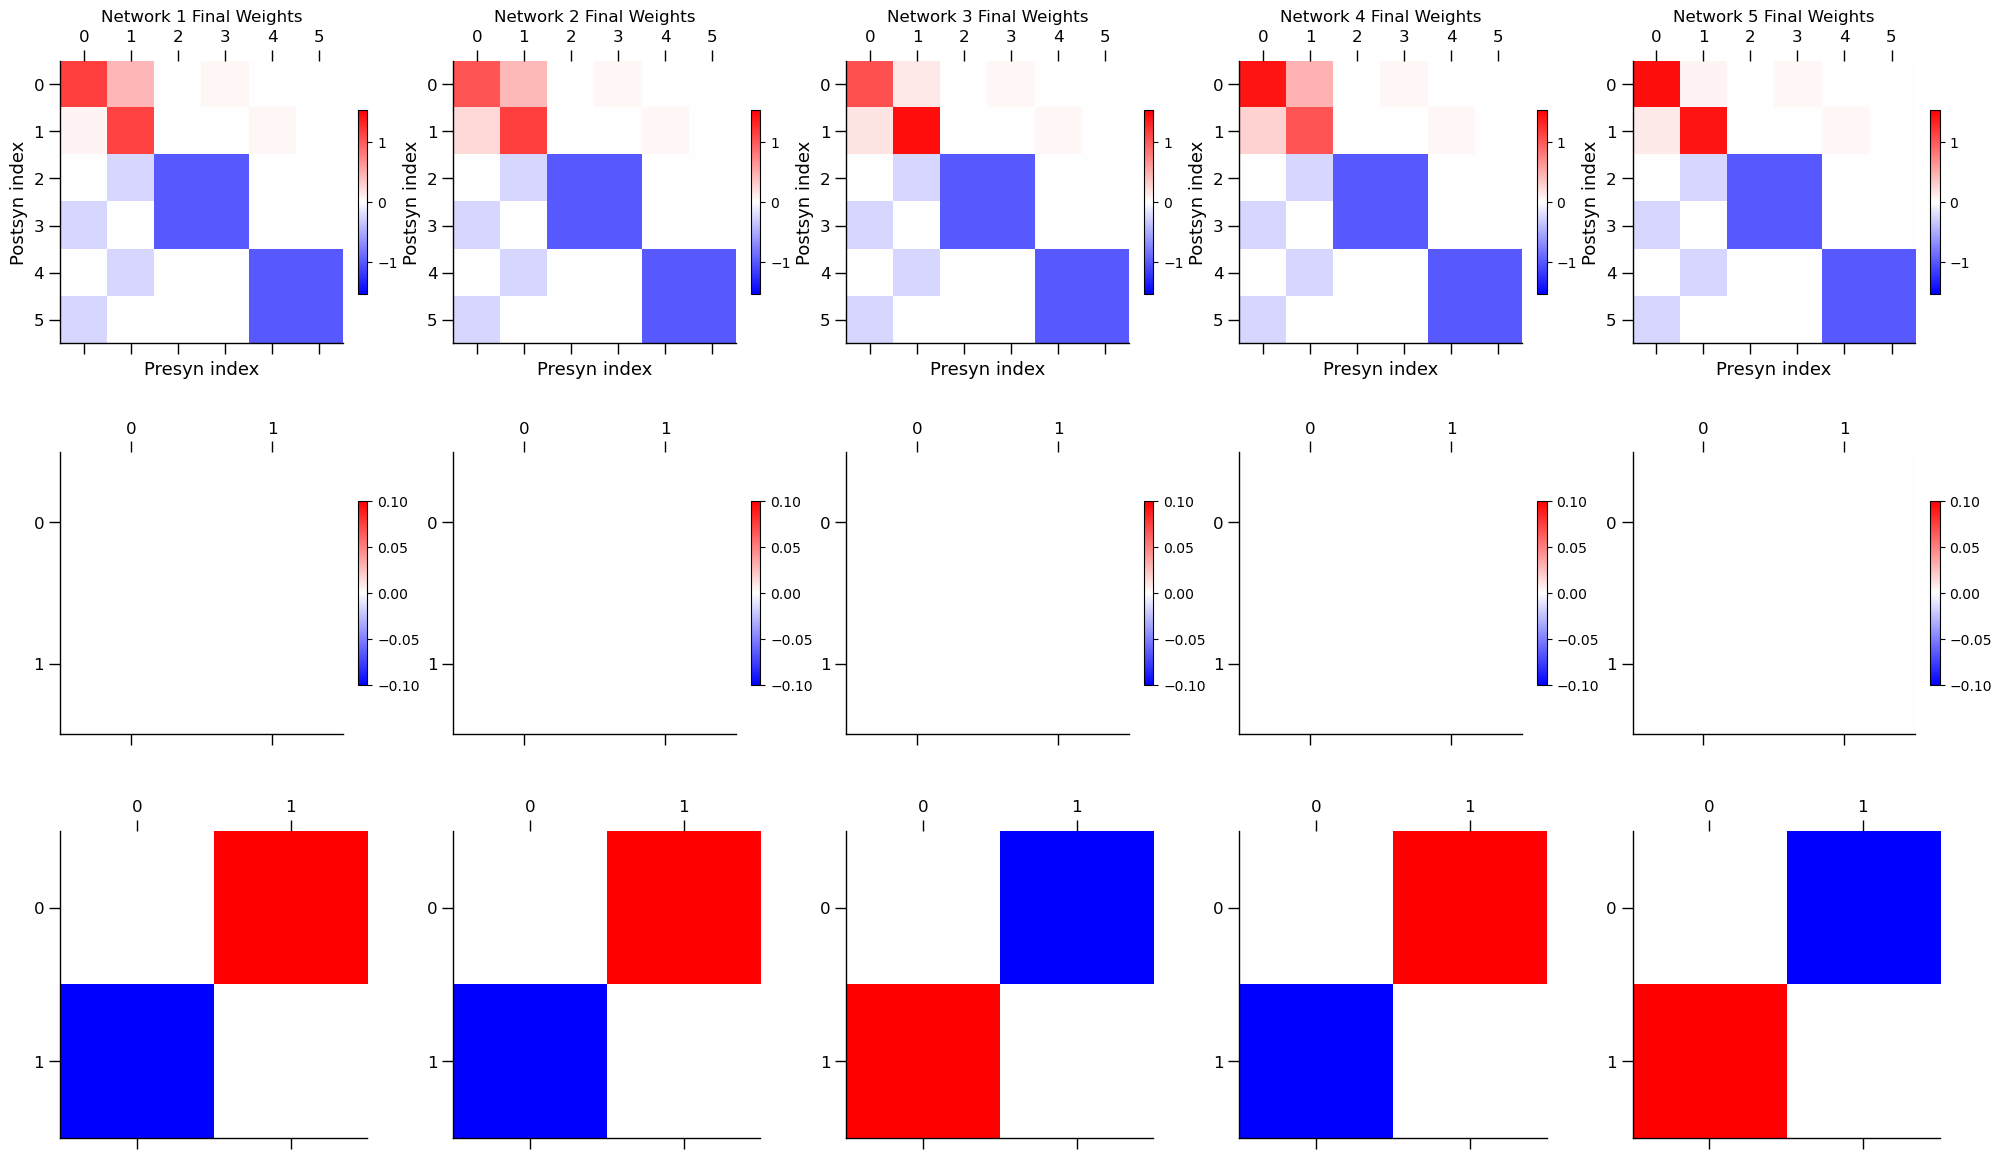

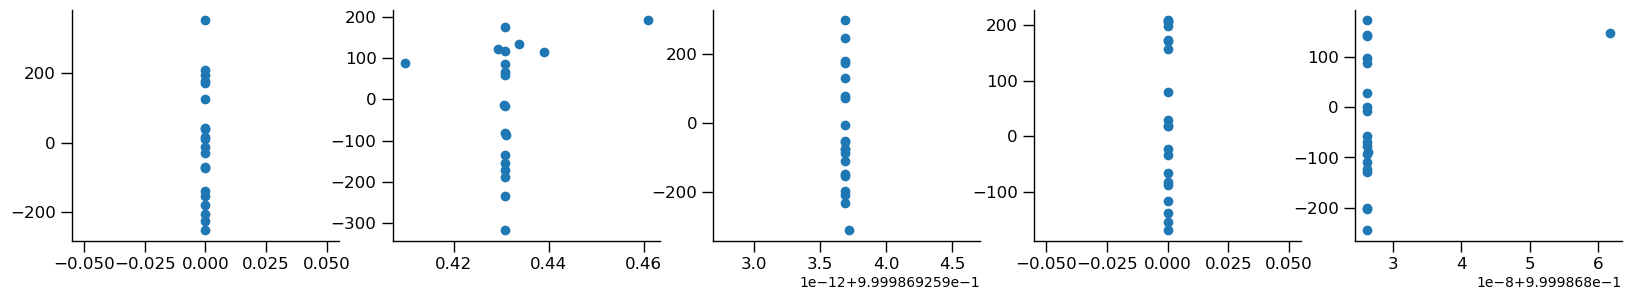

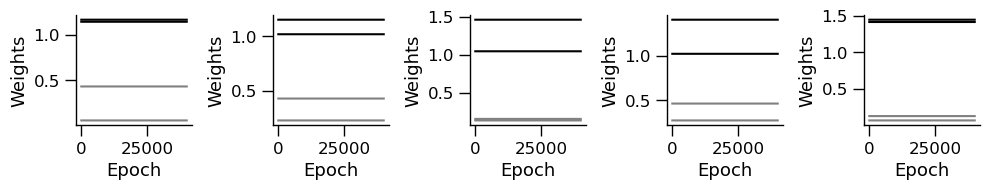

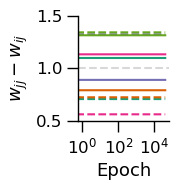

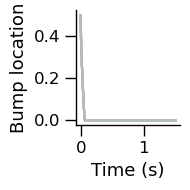

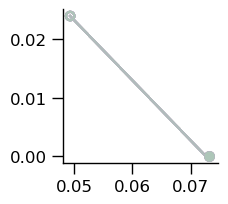

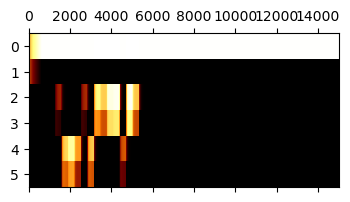

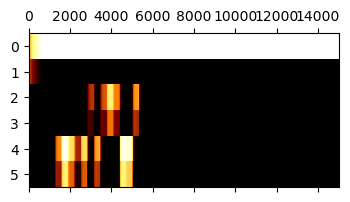

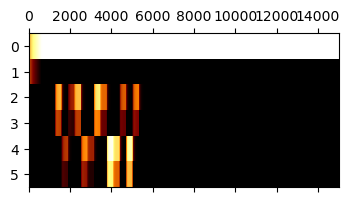

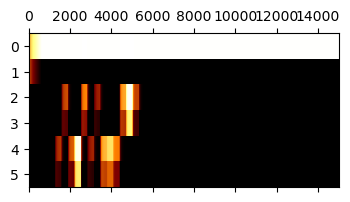

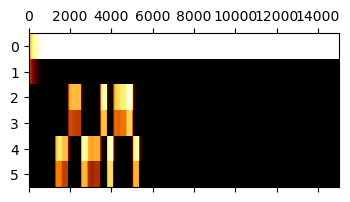

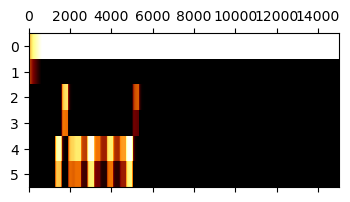

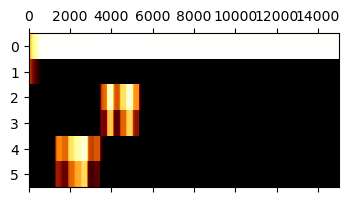

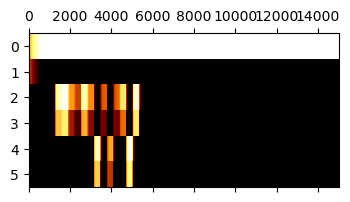

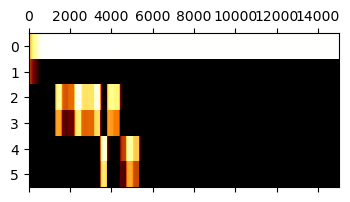

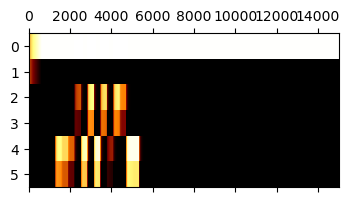

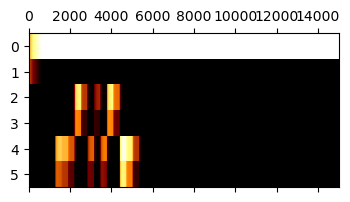

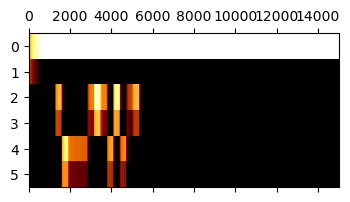

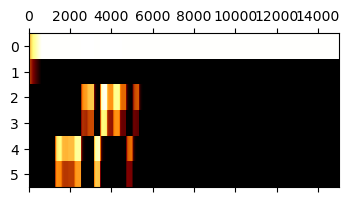

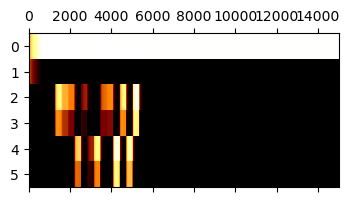

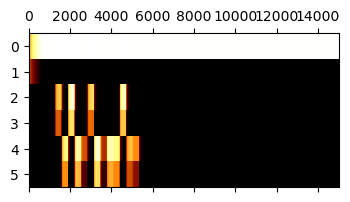

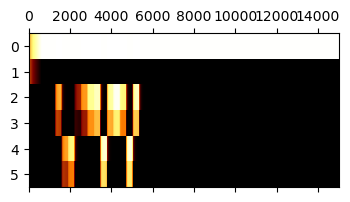

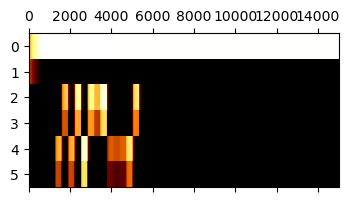

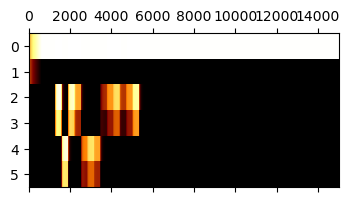

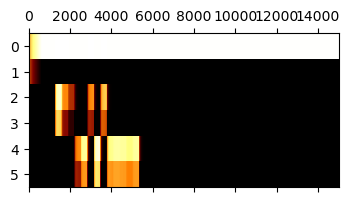

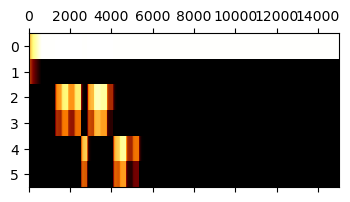

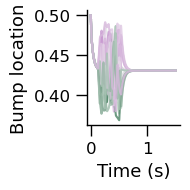

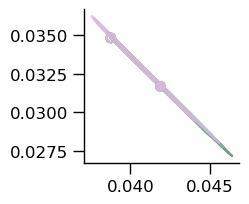

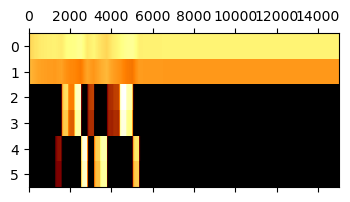

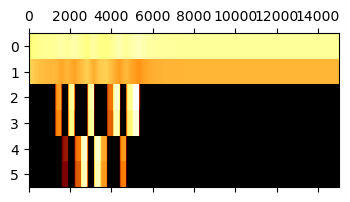

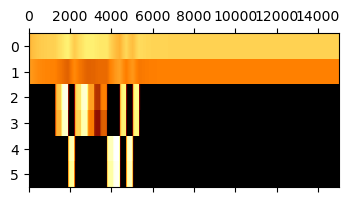

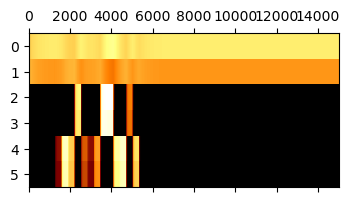

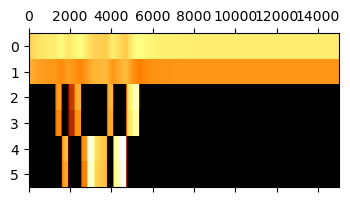

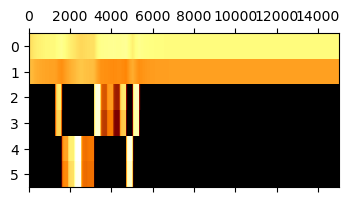

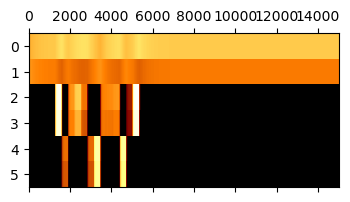

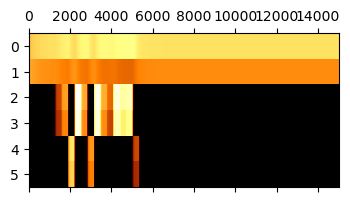

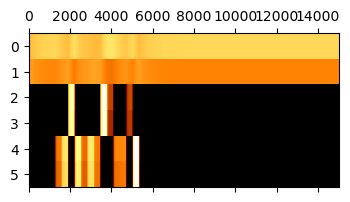

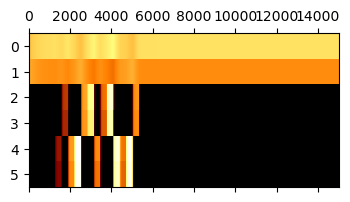

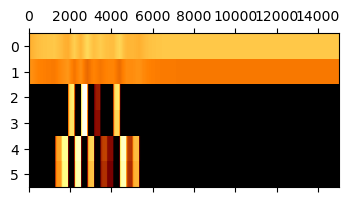

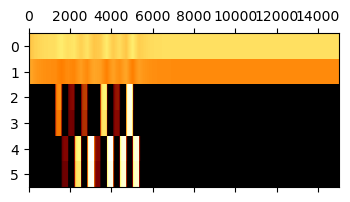

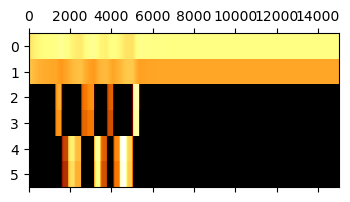

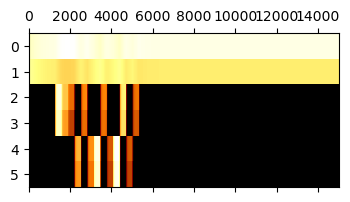

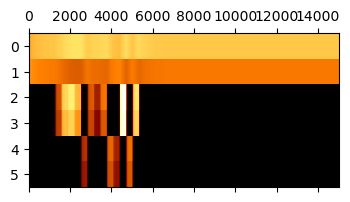

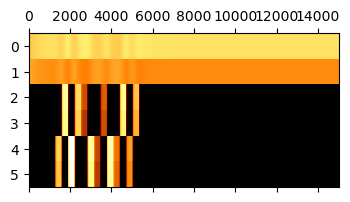

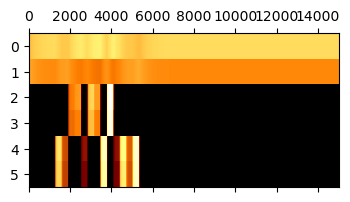

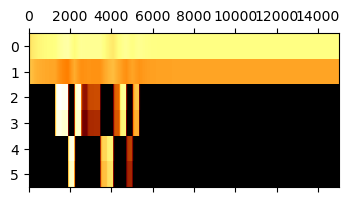

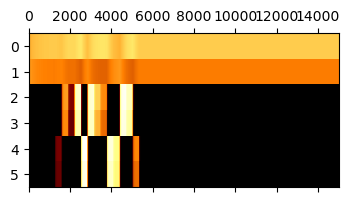

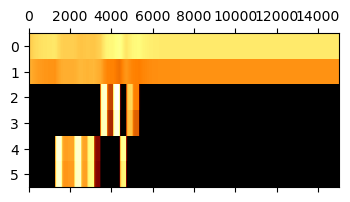

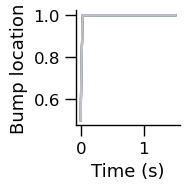

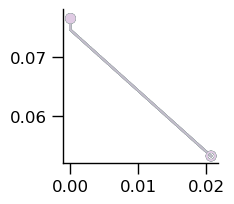

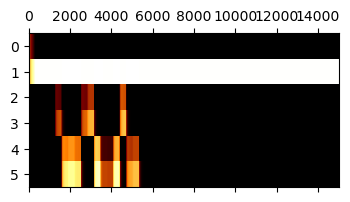

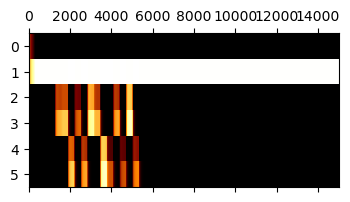

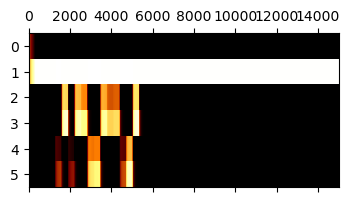

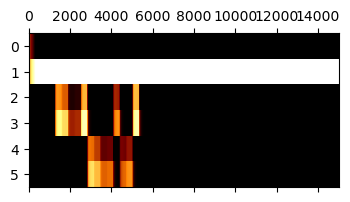

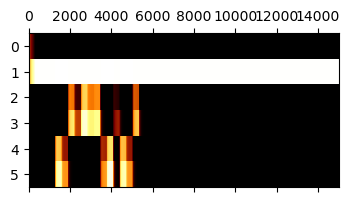

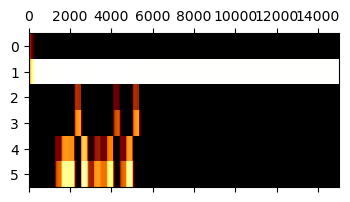

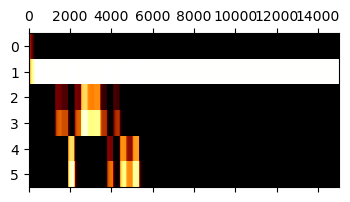

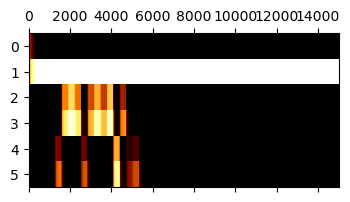

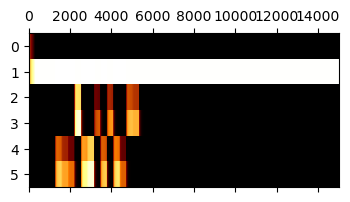

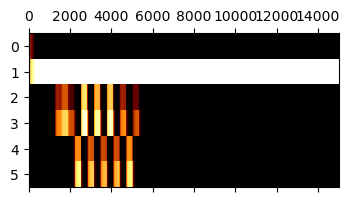

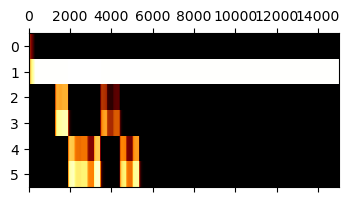

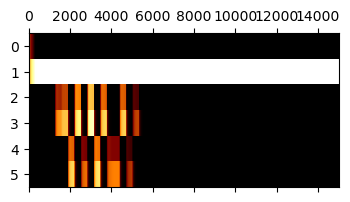

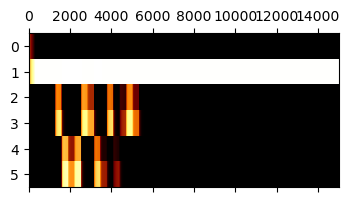

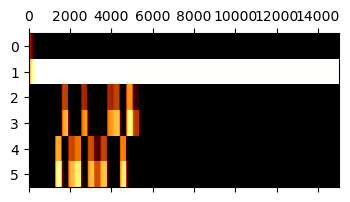

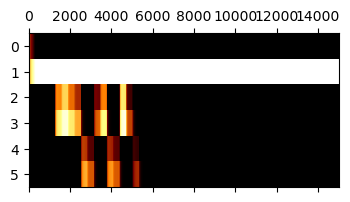

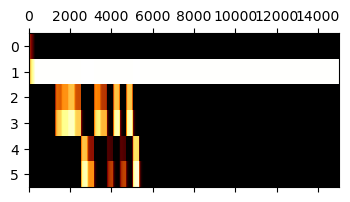

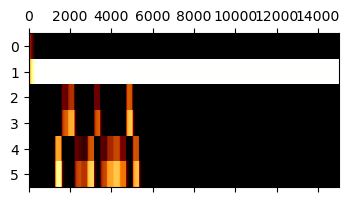

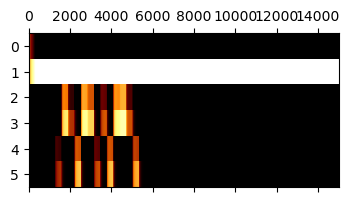

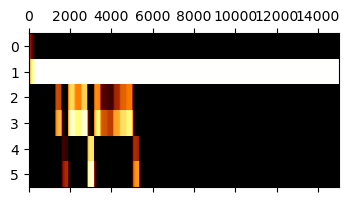

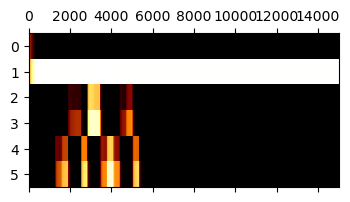

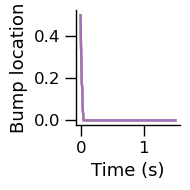

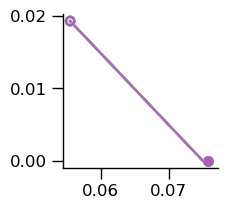

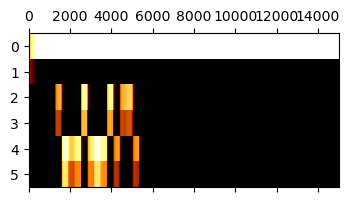

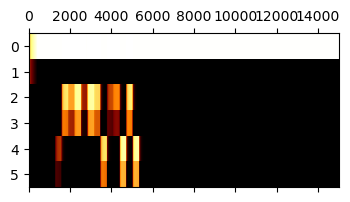

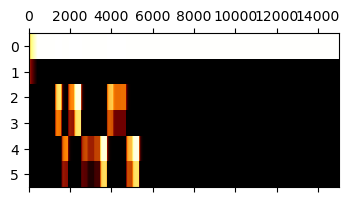

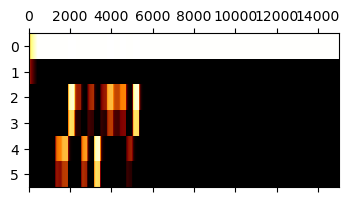

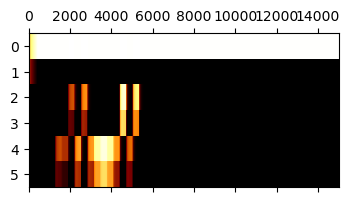

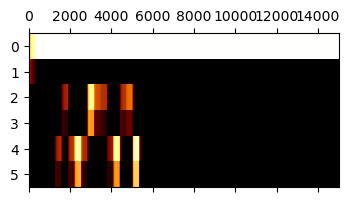

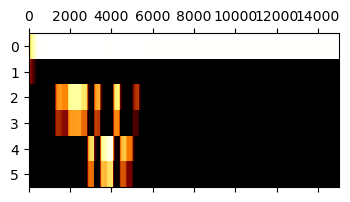

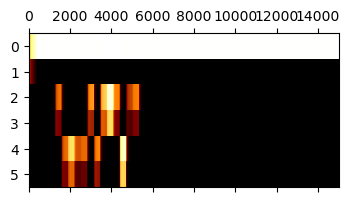

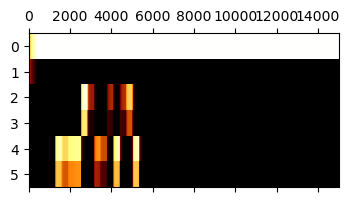

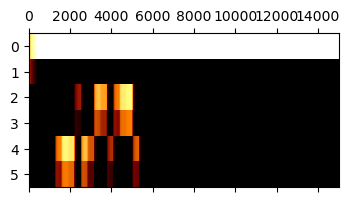

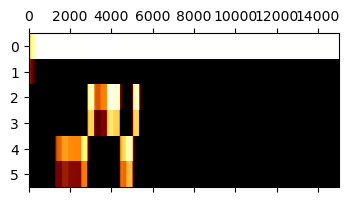

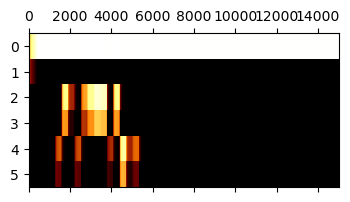

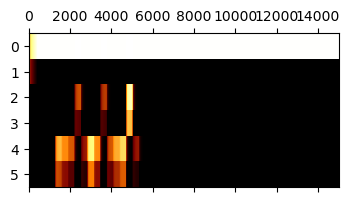

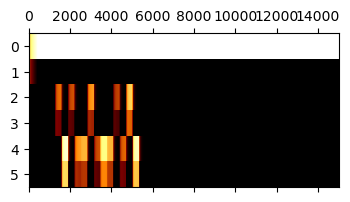

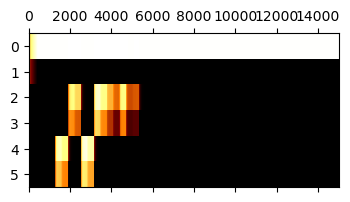

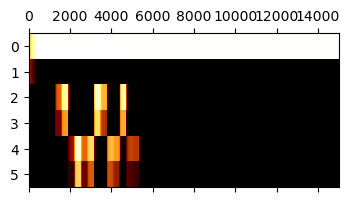

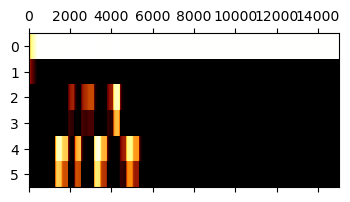

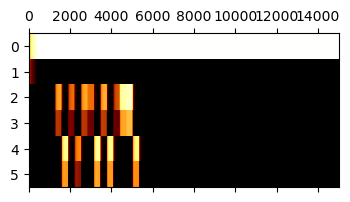

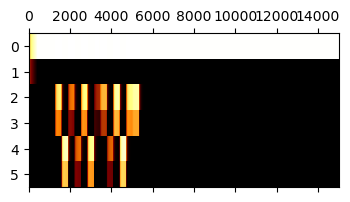

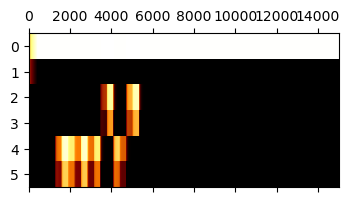

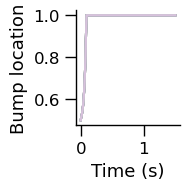

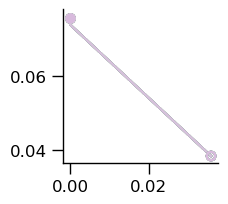

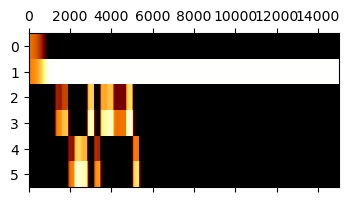

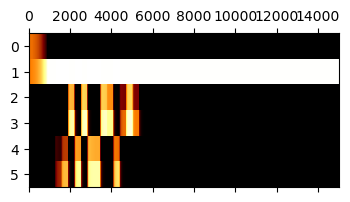

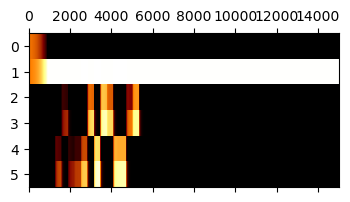

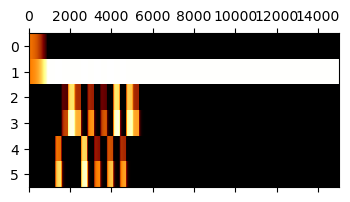

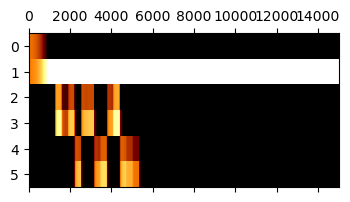

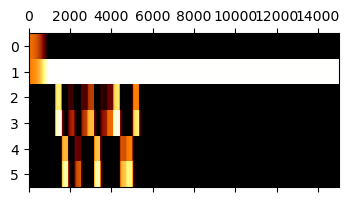

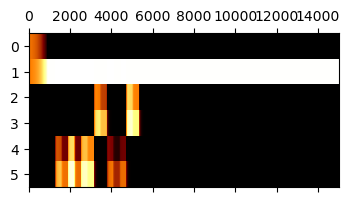

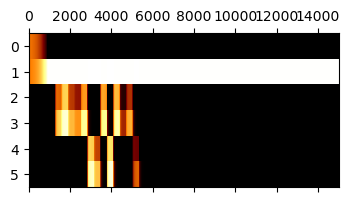

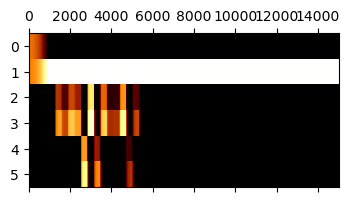

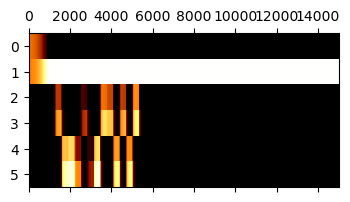

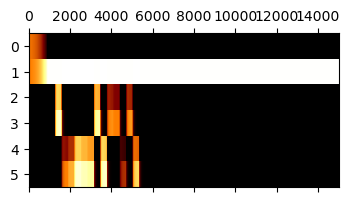

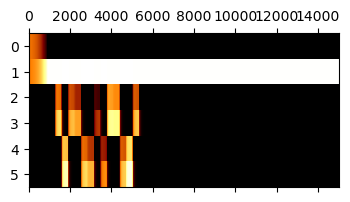

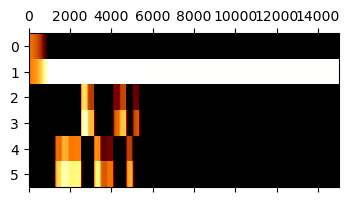

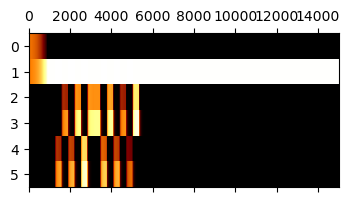

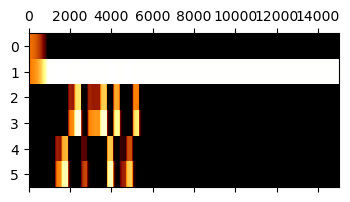

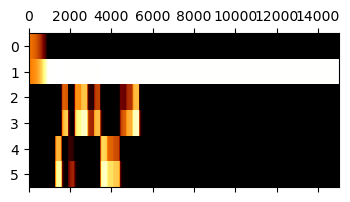

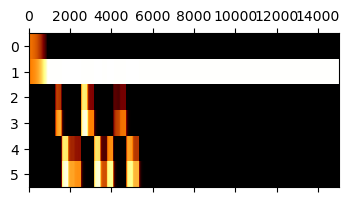

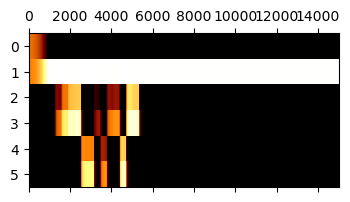

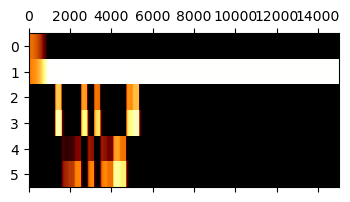

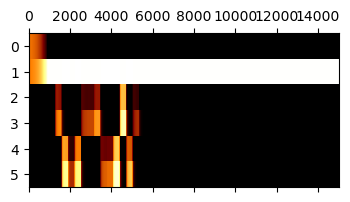

In [3]:
# del data
data = pickle.load(open('./network_training_results_v2_rule_ctrl.pkl', 'rb'))
results = data['results']
t = data['t']

# Plot results
fig_w, fig_w_traj, r2_ctrl = plot_results(results, t, n=2, save_path='active_tuning_ctrl')

/tmp/ipykernel_2302536/2044958735.py:2: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  data = pickle.load(open('./network_training_results_v2_rule.pkl', 'rb'))
/tmp/ipykernel_2302536/4286922569.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1200 with 16 Axes> than <Figure size 2000x300 with 5 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[0, i], fraction=0.03)
/tmp/ipykernel_2302536/4286922569.py:27: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1200 with 17 Axes> than <Figure size 2000x300 with 5 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[1, i], fraction=0.03)
/tmp/ipykernel_2302536/4286922569.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1200 with 18 Axes> than <Figure size 2000x300 with 5 Axes> which fig.colorbar is cal

0


/tmp/ipykernel_2302536/4286922569.py:141: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(4, 2))


corr 0.9425753055358657
1
corr 0.952266907210208
2
corr 0.8743485377727406
3
corr 0.9411691377738892
4
corr 0.9470523958719286


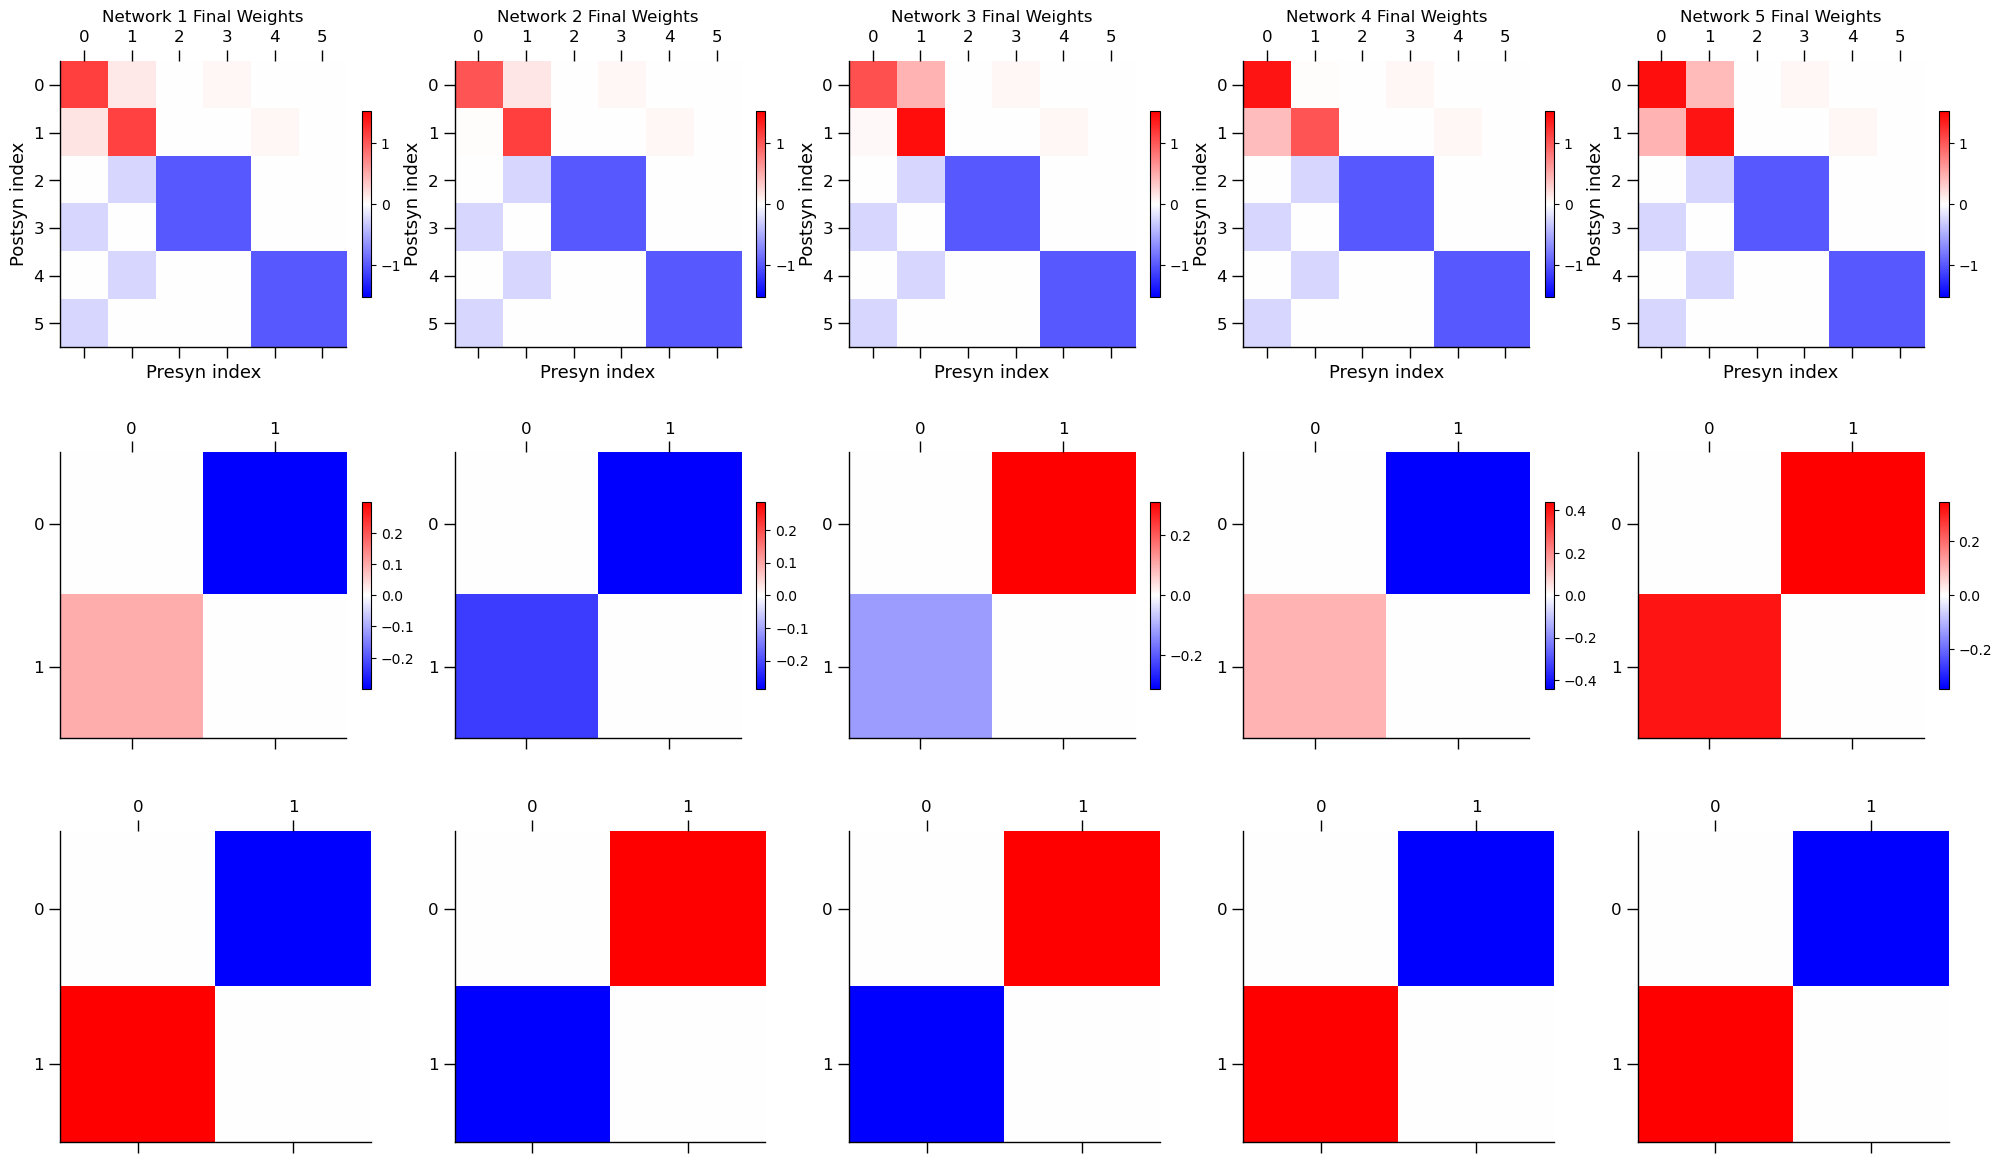

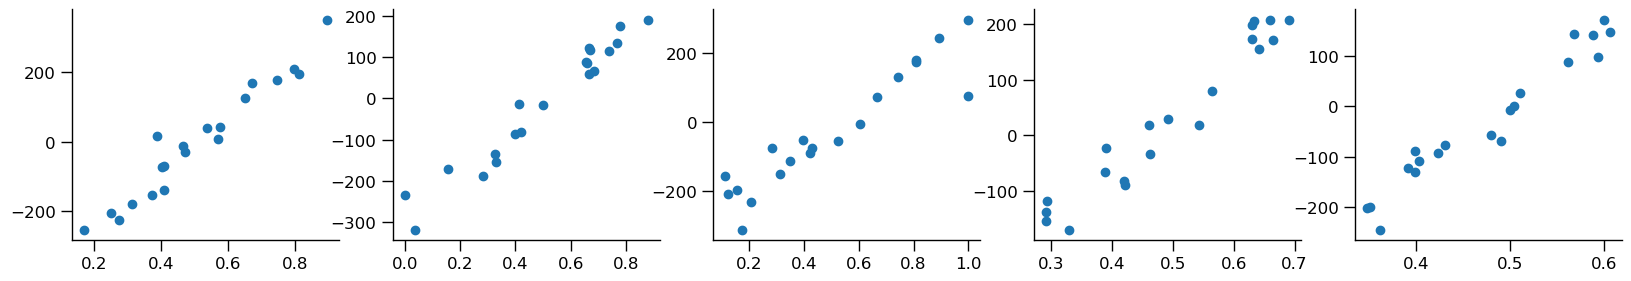

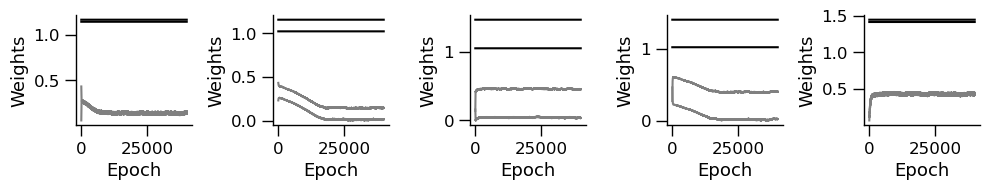

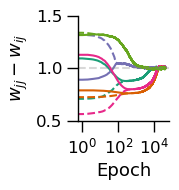

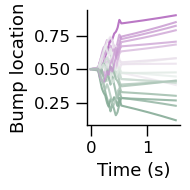

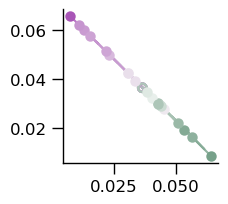

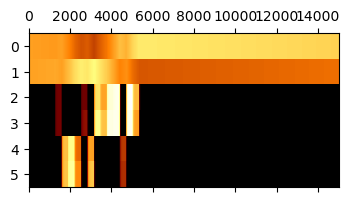

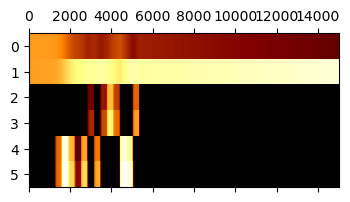

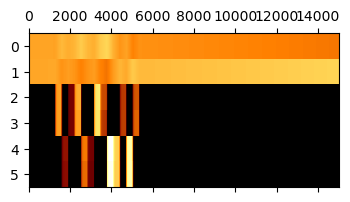

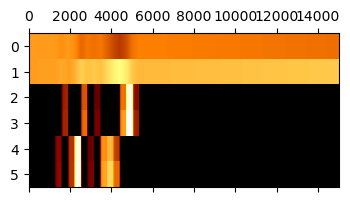

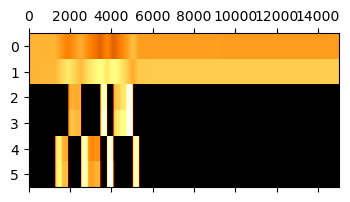

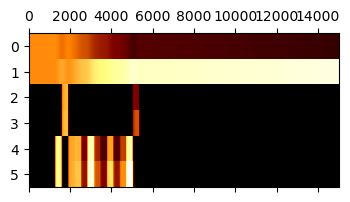

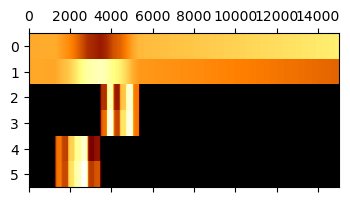

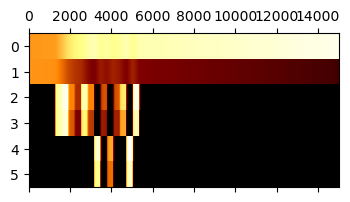

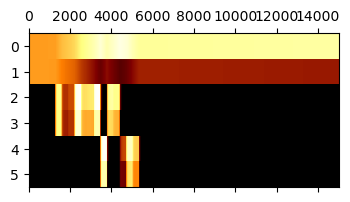

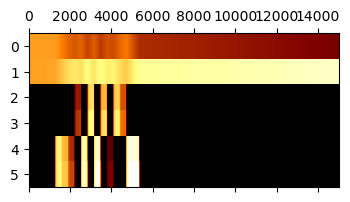

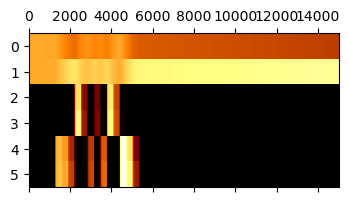

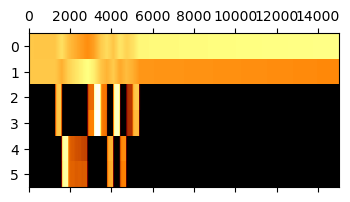

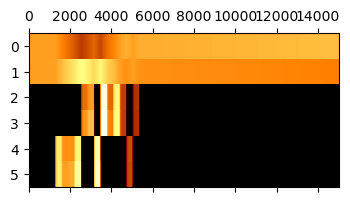

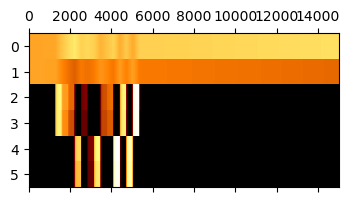

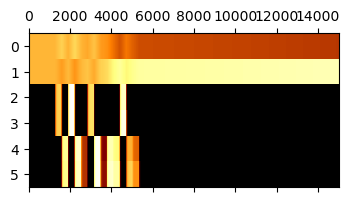

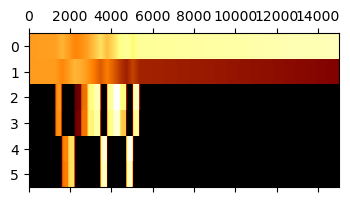

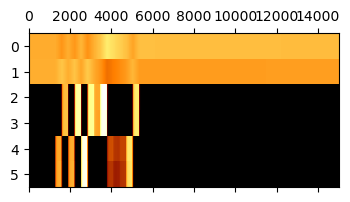

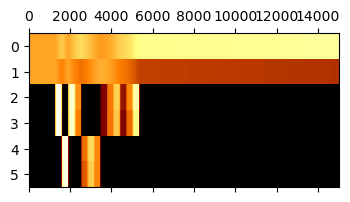

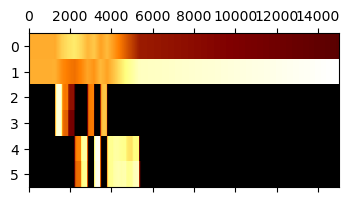

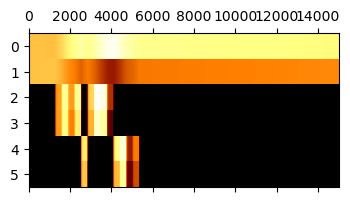

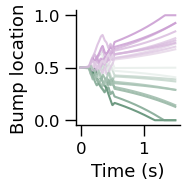

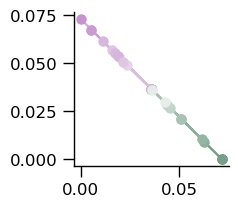

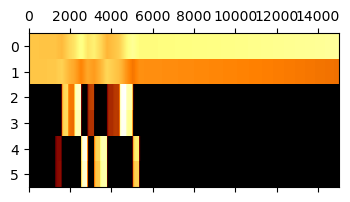

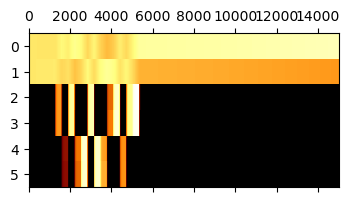

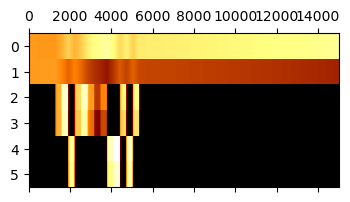

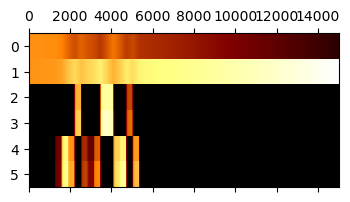

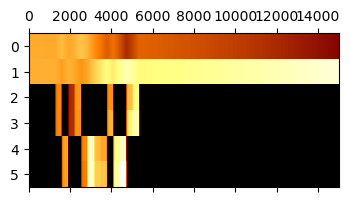

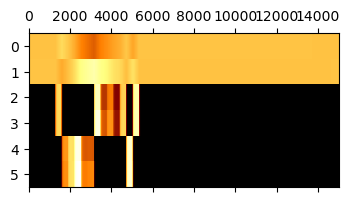

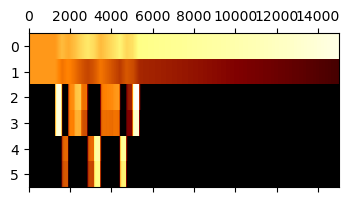

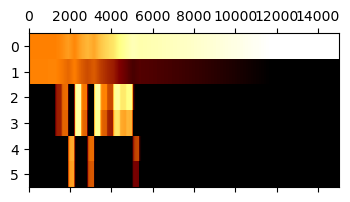

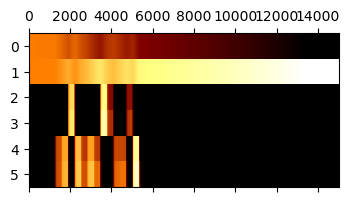

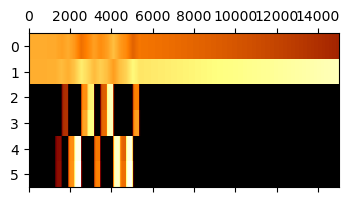

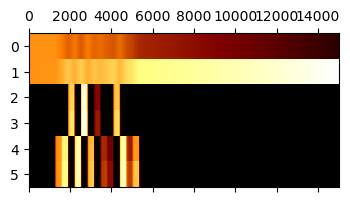

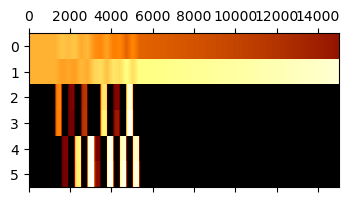

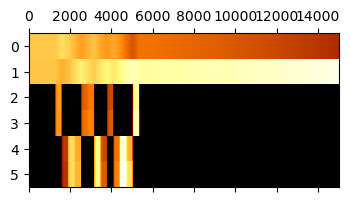

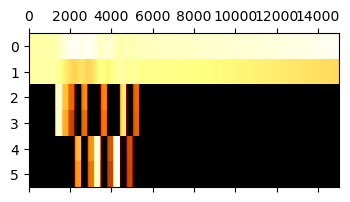

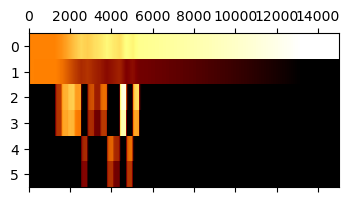

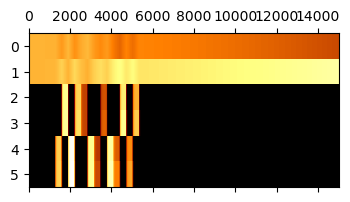

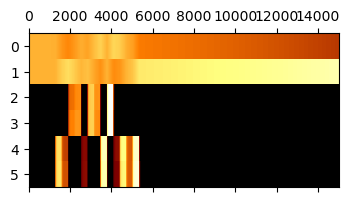

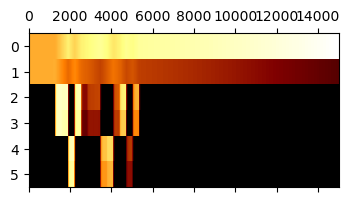

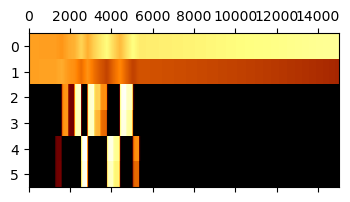

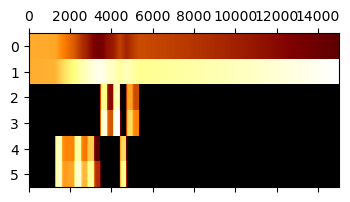

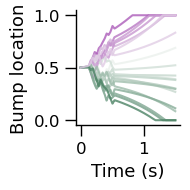

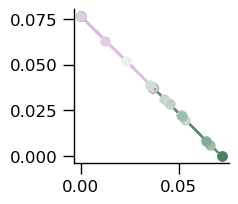

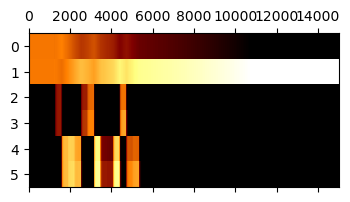

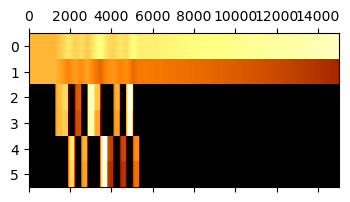

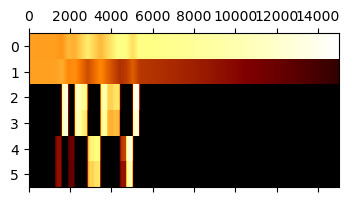

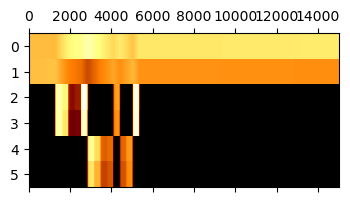

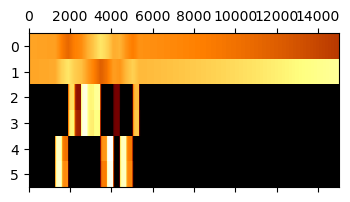

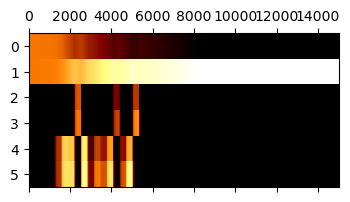

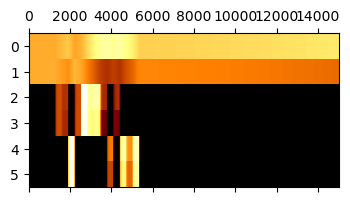

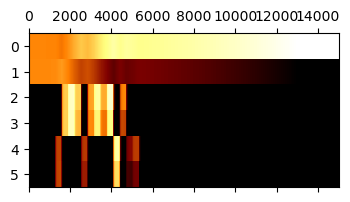

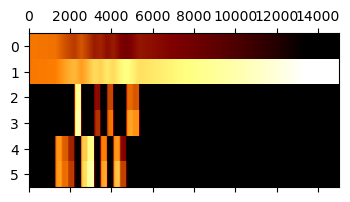

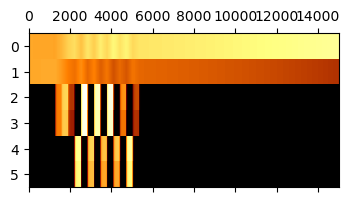

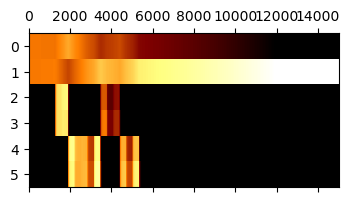

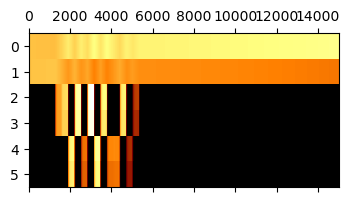

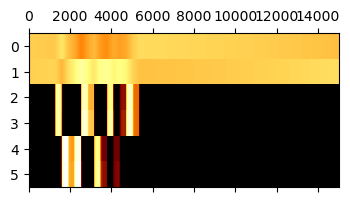

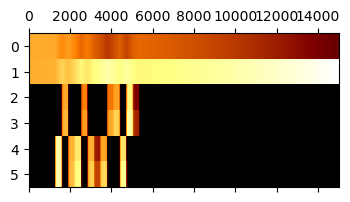

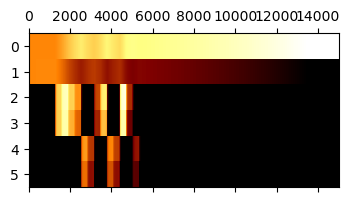

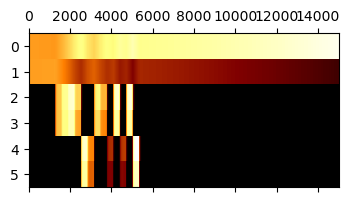

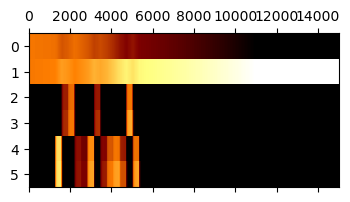

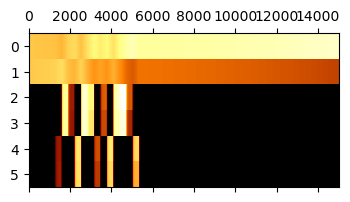

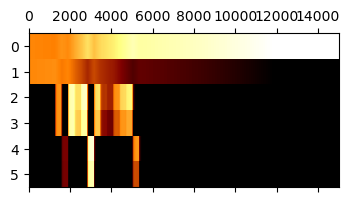

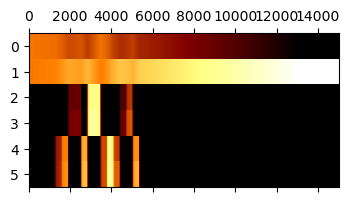

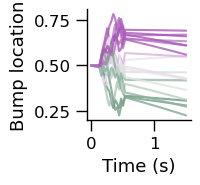

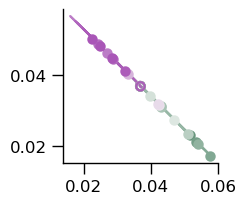

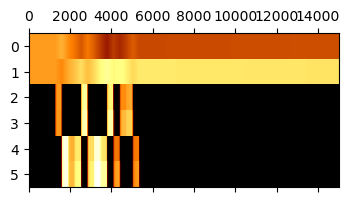

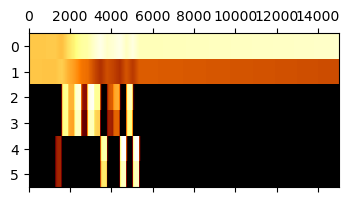

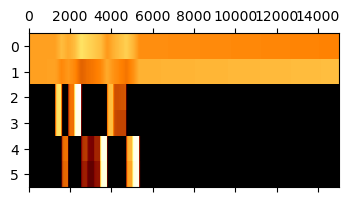

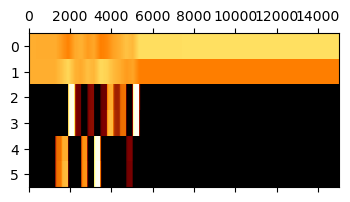

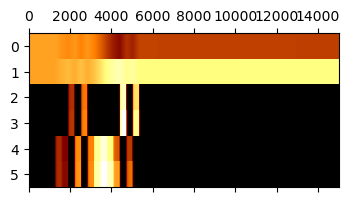

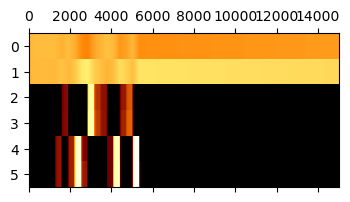

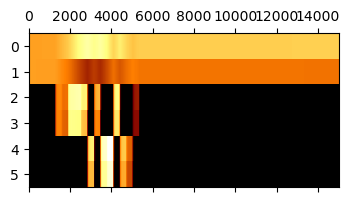

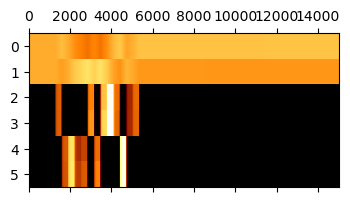

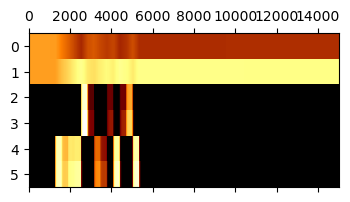

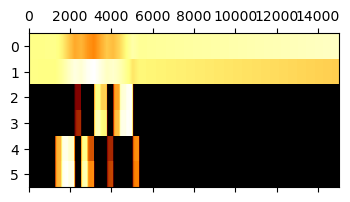

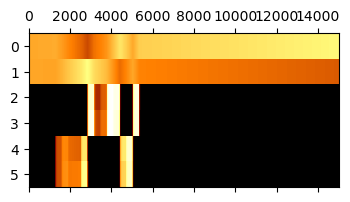

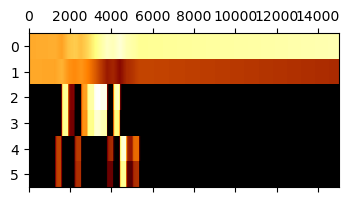

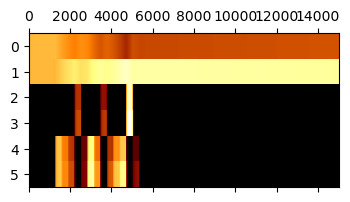

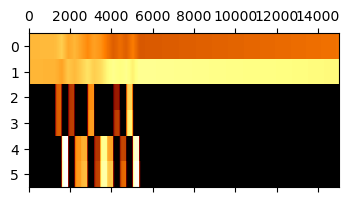

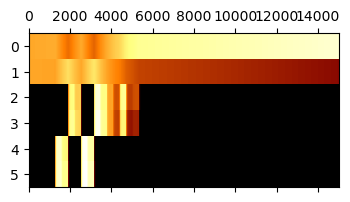

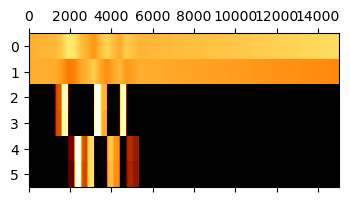

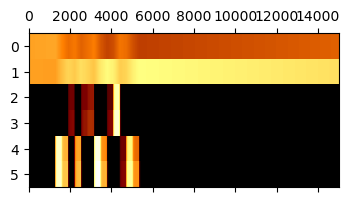

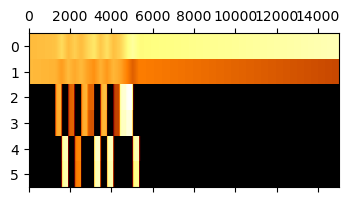

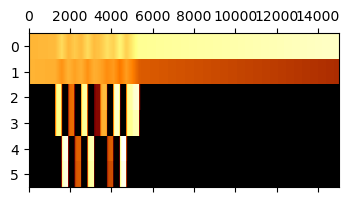

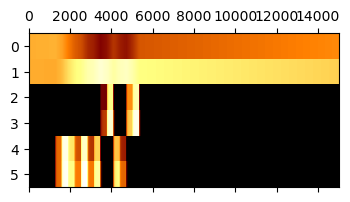

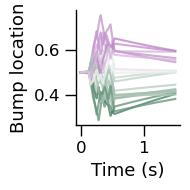

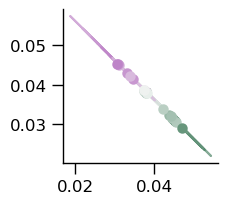

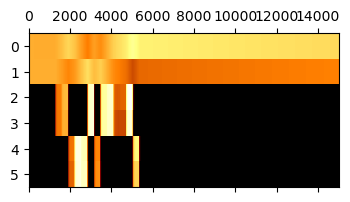

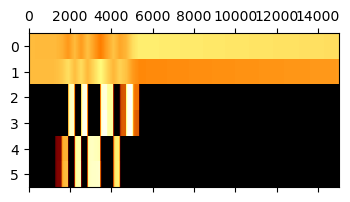

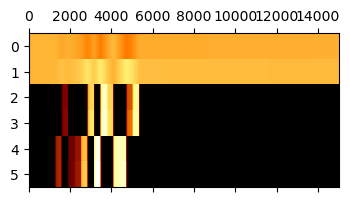

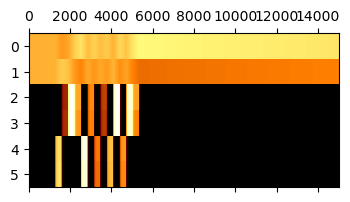

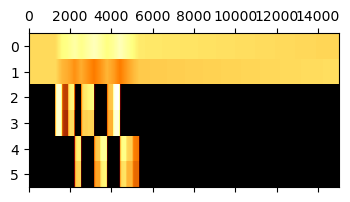

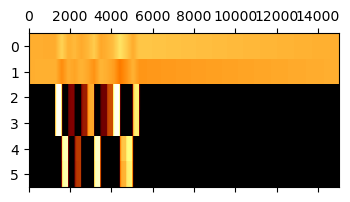

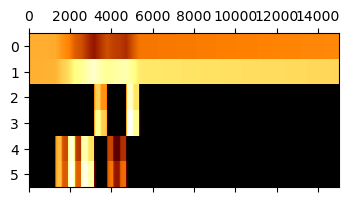

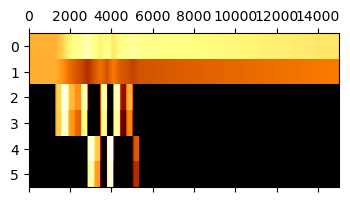

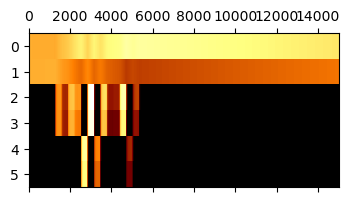

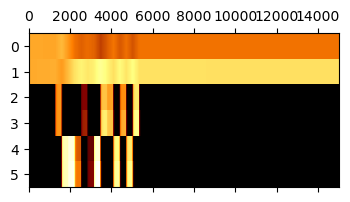

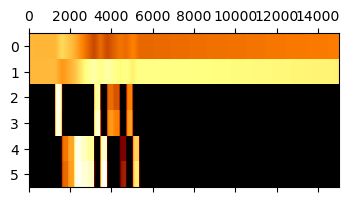

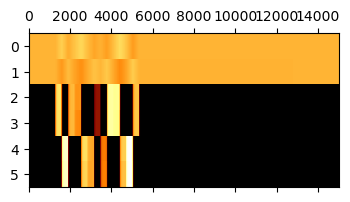

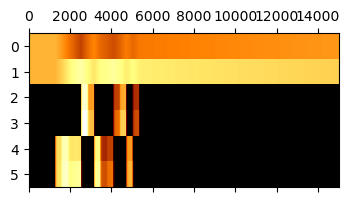

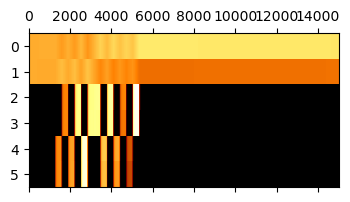

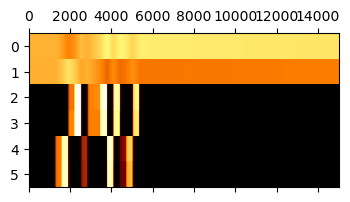

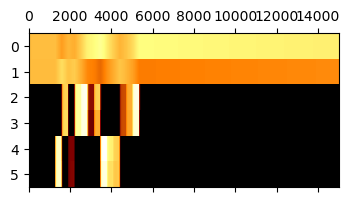

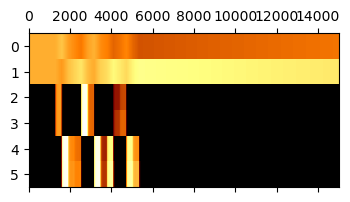

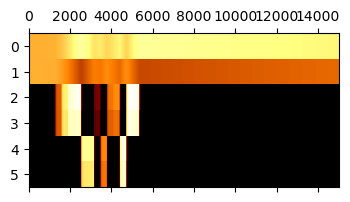

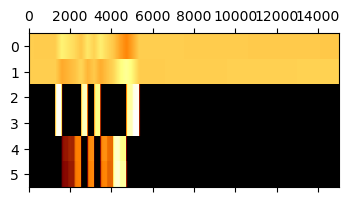

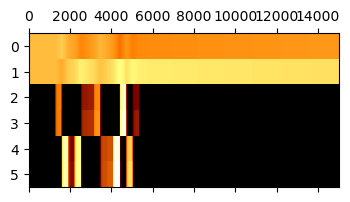

In [4]:
# del data
data = pickle.load(open('./network_training_results_v2_rule.pkl', 'rb'))
results = data['results']
t = data['t']

# Plot results
fig_w, fig_w_traj, r2_plastic = plot_results(results, t, n=2, save_path='active_tuning')

0.06204266086586167 0.06195299469630125
0.9314824568329264 0.028829096990152514


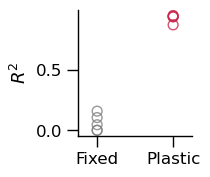

In [14]:
fig_r2, axes_r2 = plt.subplots(1, 1, figsize=(2, 1.8))
axes_r2.scatter([0] * len(r2_ctrl) + np.random.normal(scale=0.0, size=len(r2_ctrl)), np.where(np.isnan(r2_ctrl), 0, r2_ctrl), s=50, marker='o', facecolor='none', edgecolor='grey', alpha=0.8)
axes_r2.scatter([1] * len(r2_plastic) + np.random.normal(scale=0.0, size=len(r2_plastic)), r2_plastic, s=50, marker='o', facecolor='none', edgecolor='#c9294c', alpha=0.8)
axes_r2.set_xlim(-0.25, 1.25)
axes_r2.set_xticks([0, 1])
axes_r2.set_xticklabels(['Fixed', 'Plastic'])
axes_r2.set_ylabel(r'$R^2$')
fig_r2.tight_layout()
format_plot(axes_r2)
fig_r2.savefig('./figures/handbuilt_rules/active_tuning_comparison.svg')

print(np.mean(np.where(np.isnan(r2_ctrl), 0, r2_ctrl)), np.std(np.where(np.isnan(r2_ctrl), 0, r2_ctrl)))
print(np.mean(r2_plastic), np.std(r2_plastic))

/tmp/ipykernel_2102487/3856136676.py:2: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  data = pickle.load(open('./network_training_results.pkl', 'rb'))
/tmp/ipykernel_2102487/932663340.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1200 with 16 Axes> than <Figure size 2000x300 with 5 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[0, i], fraction=0.03)
/tmp/ipykernel_2102487/932663340.py:27: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1200 with 17 Axes> than <Figure size 2000x300 with 5 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[1, i], fraction=0.03)
/tmp/ipykernel_2102487/932663340.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1200 with 18 Axes> than <Figure size 2000x300 with 5 Axes> which fig.colorbar is called on.
  p

0


/tmp/ipykernel_2102487/932663340.py:136: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(4, 2))


corr 0.9389918327289876
1
corr 0.9326280556324283
2
corr 0.9727035966880023
3
corr 0.4071638702437162
4
corr 0.9584285987271094


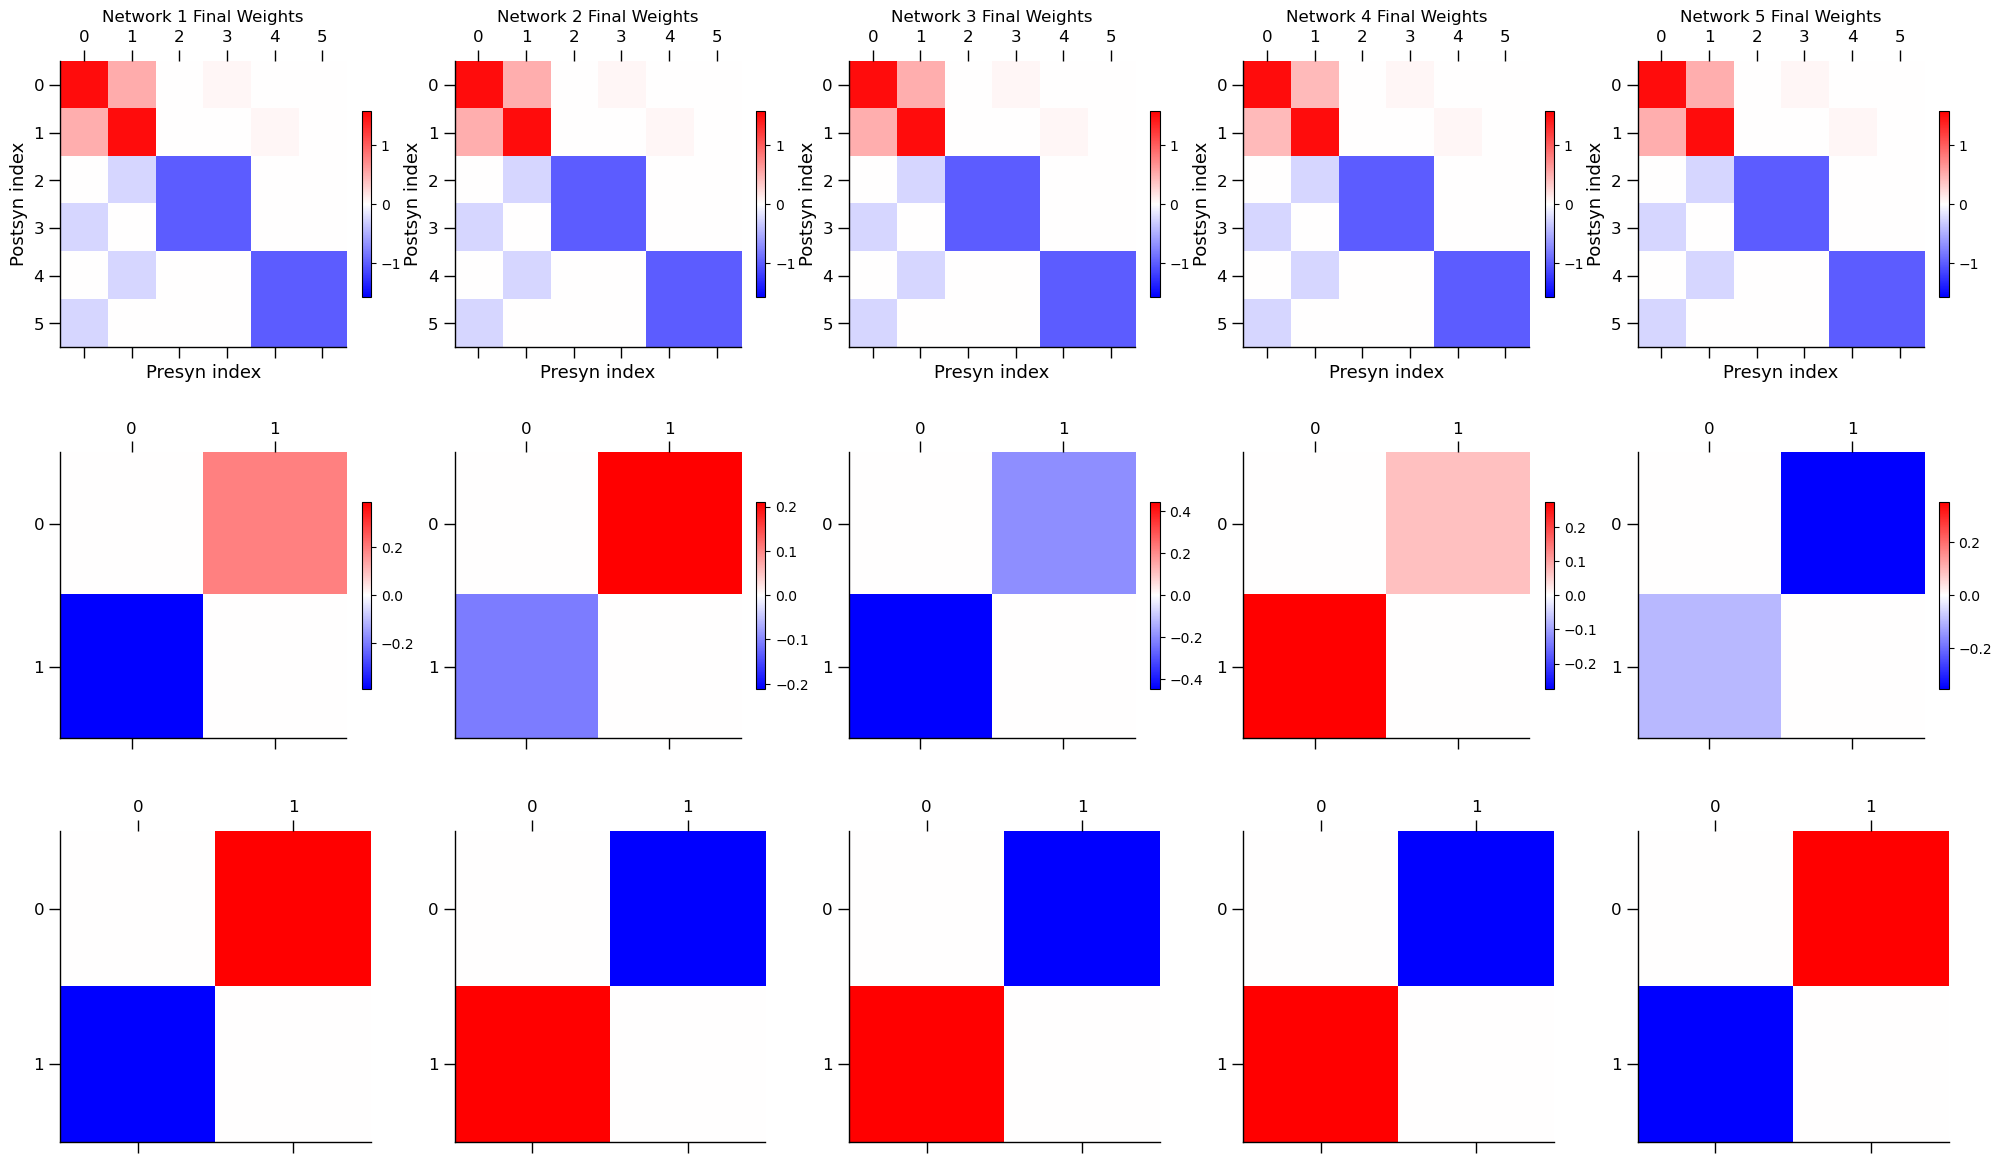

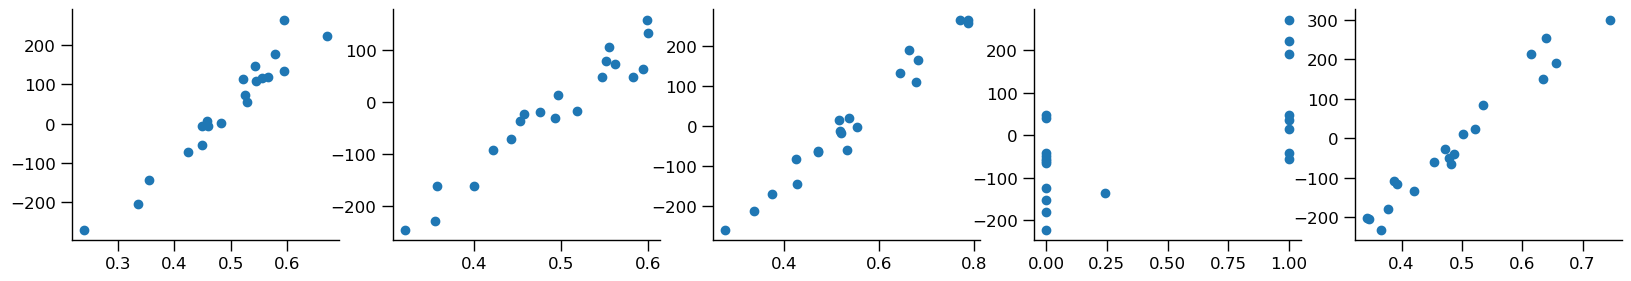

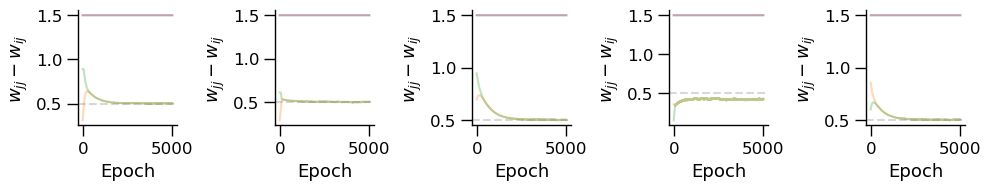

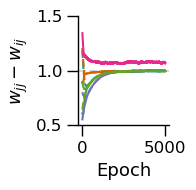

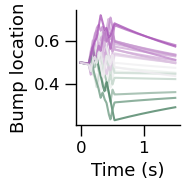

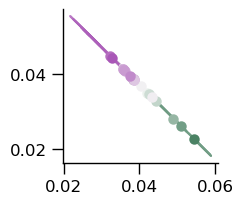

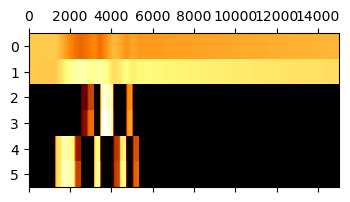

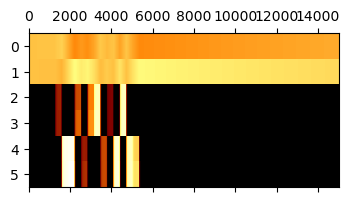

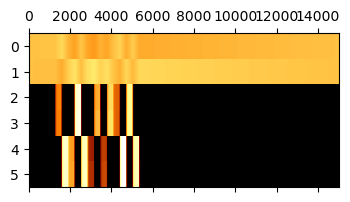

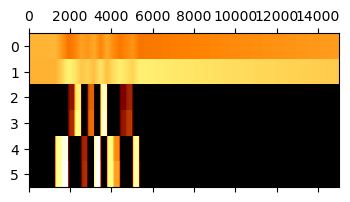

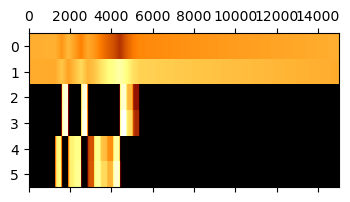

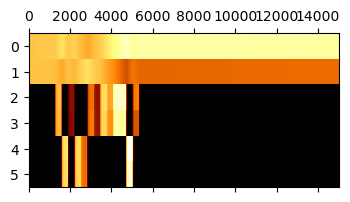

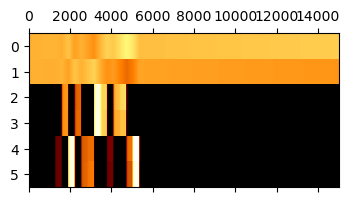

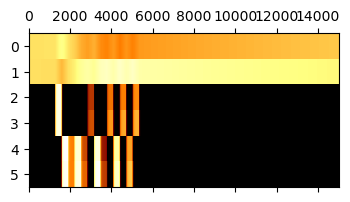

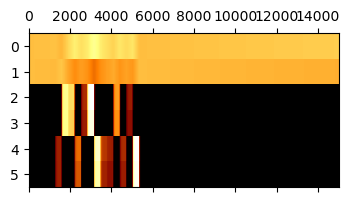

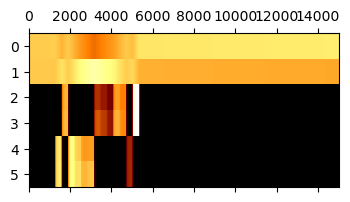

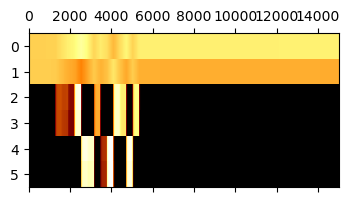

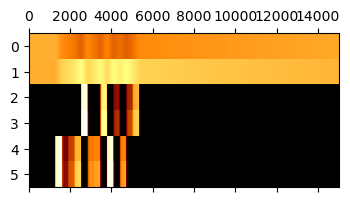

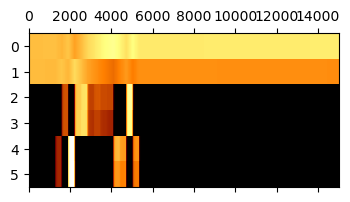

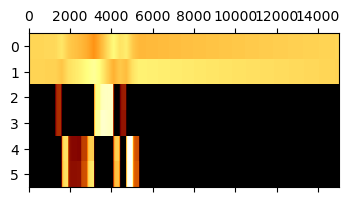

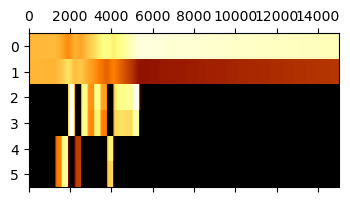

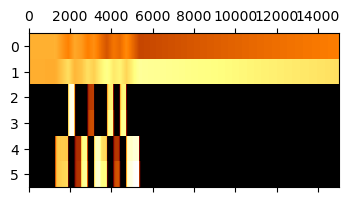

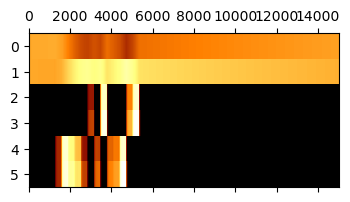

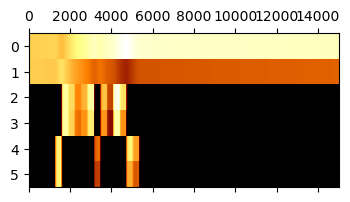

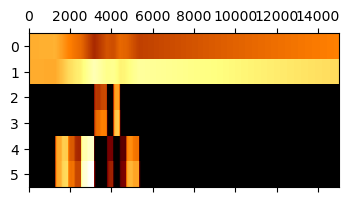

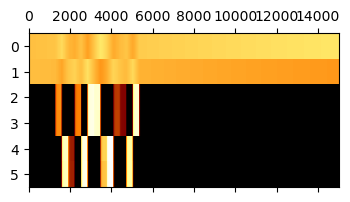

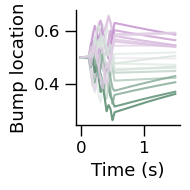

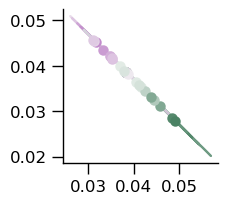

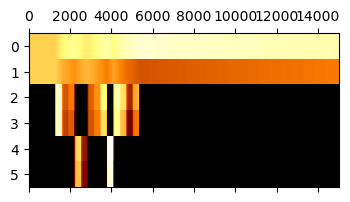

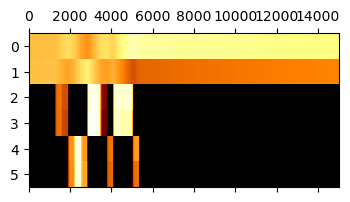

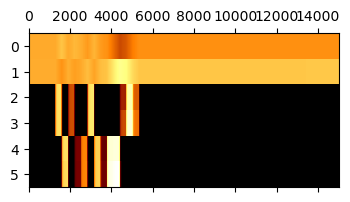

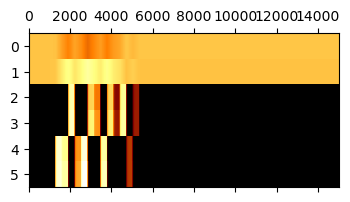

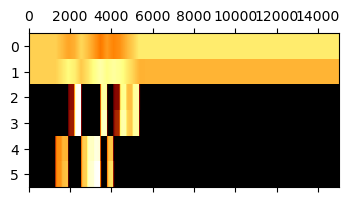

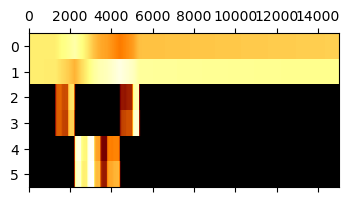

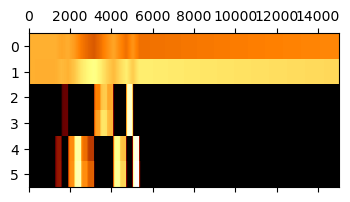

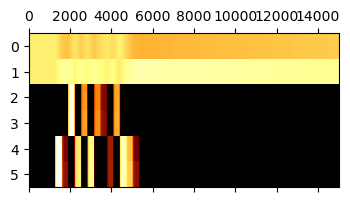

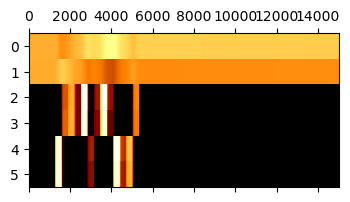

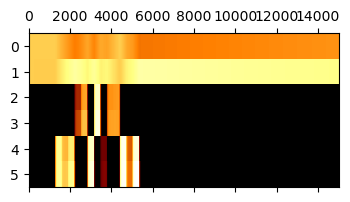

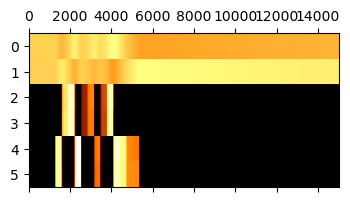

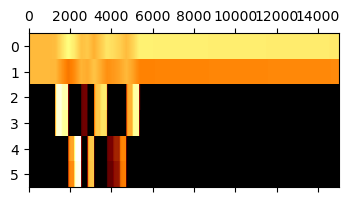

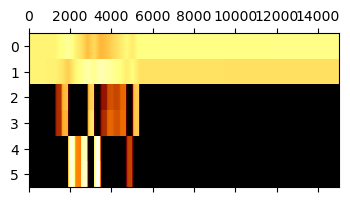

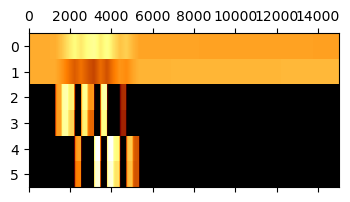

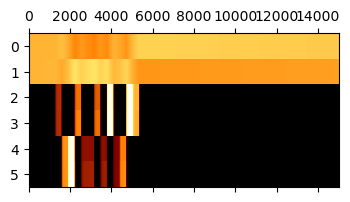

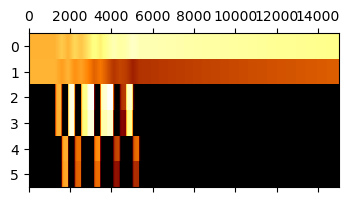

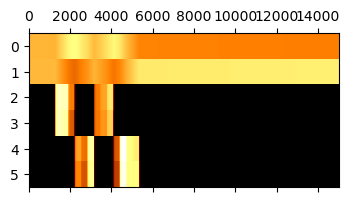

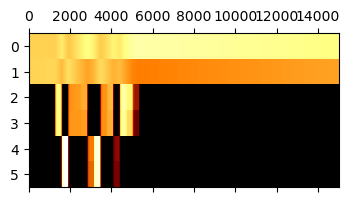

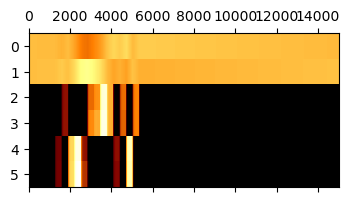

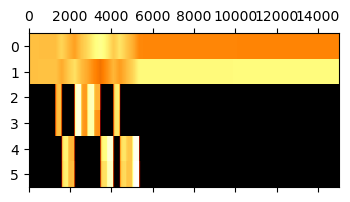

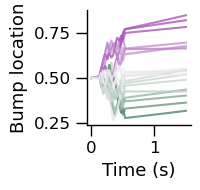

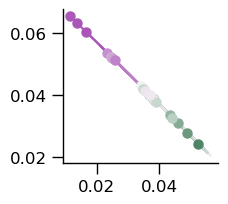

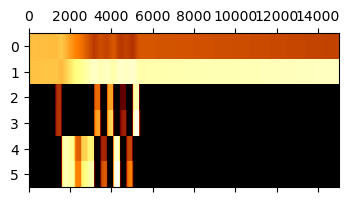

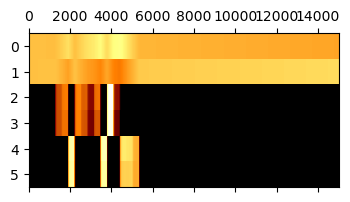

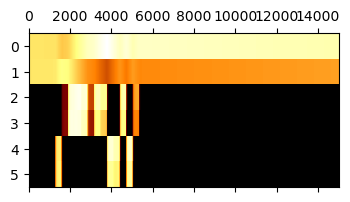

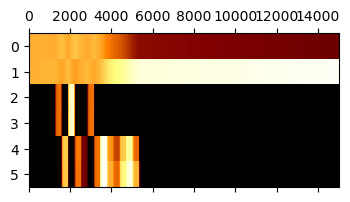

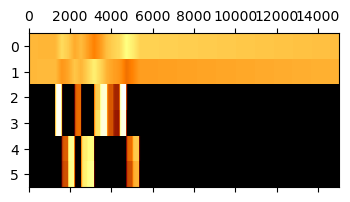

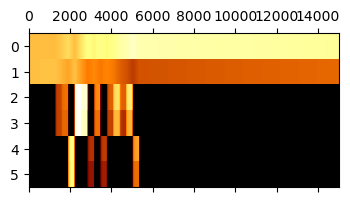

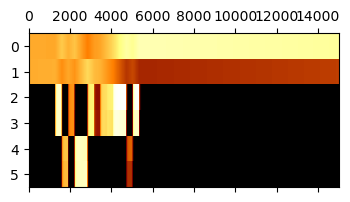

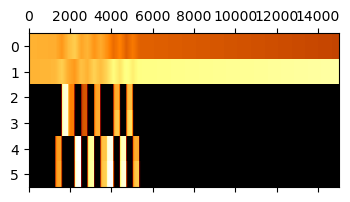

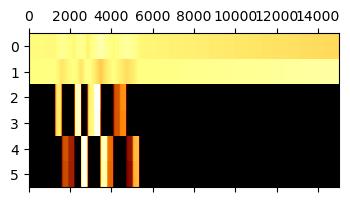

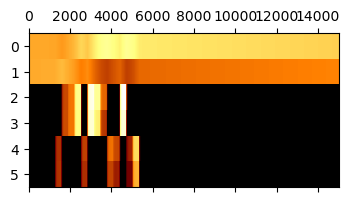

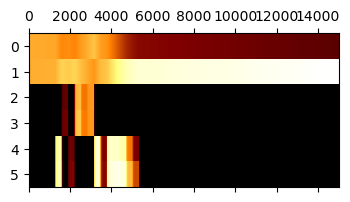

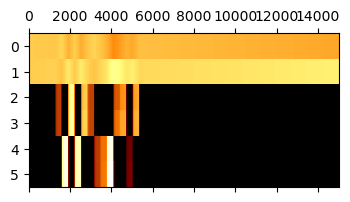

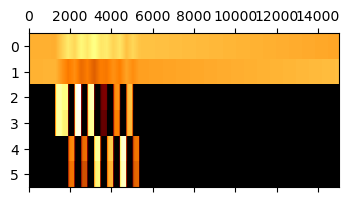

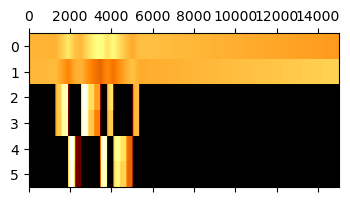

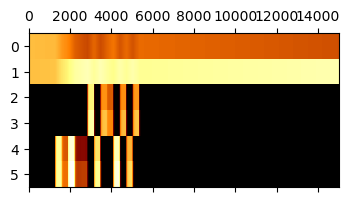

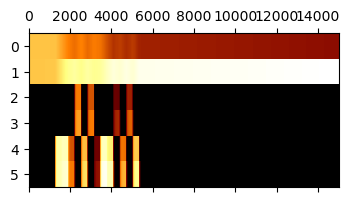

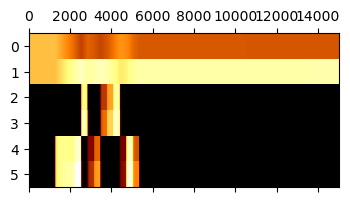

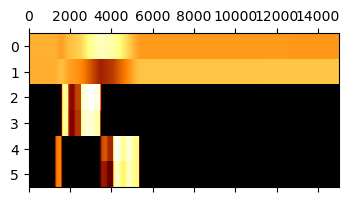

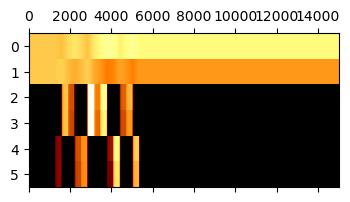

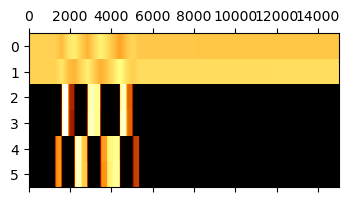

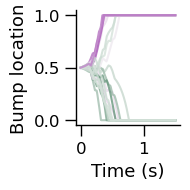

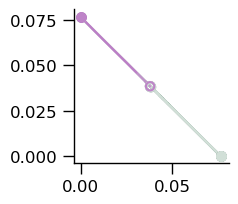

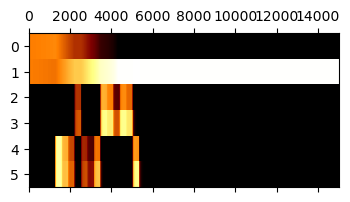

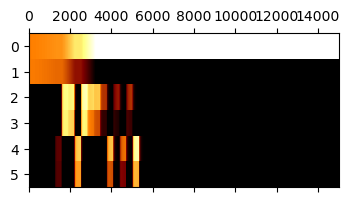

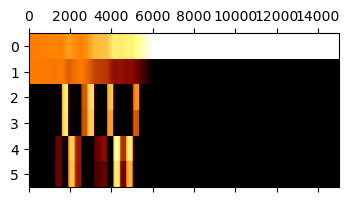

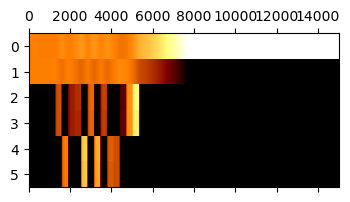

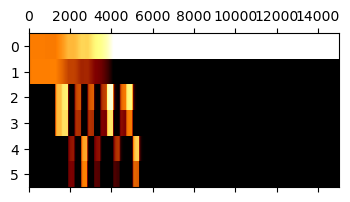

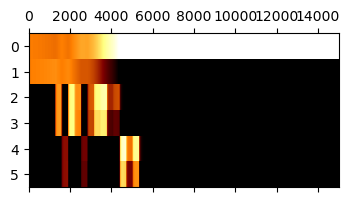

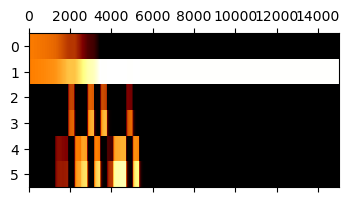

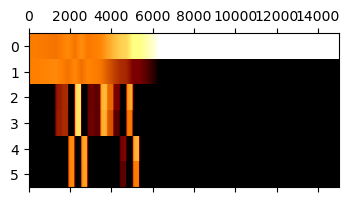

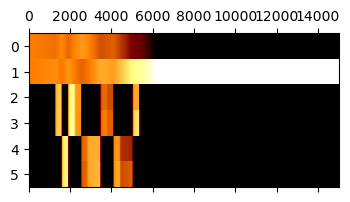

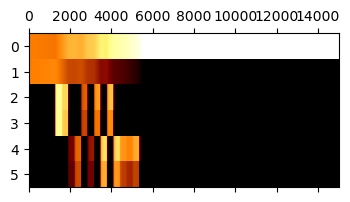

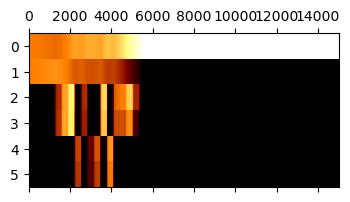

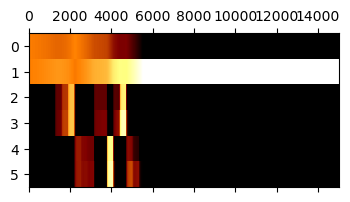

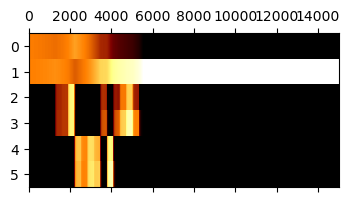

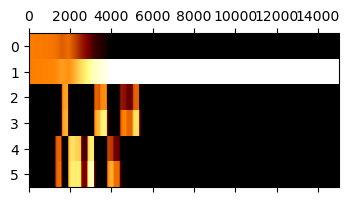

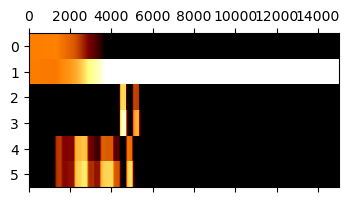

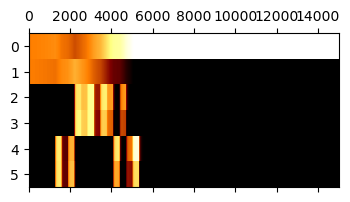

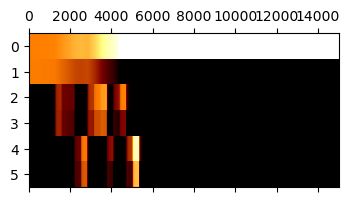

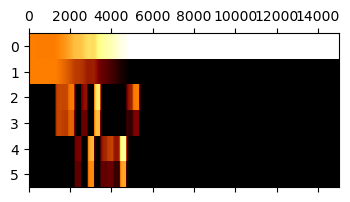

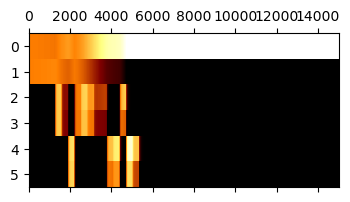

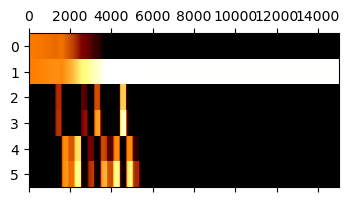

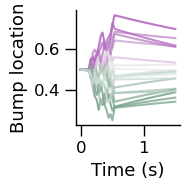

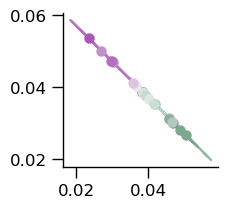

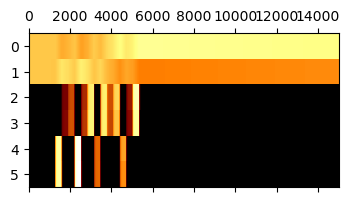

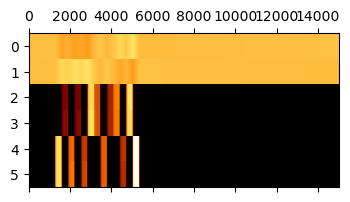

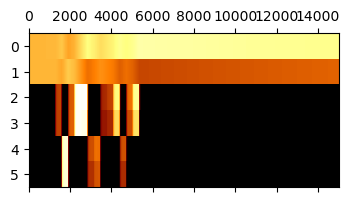

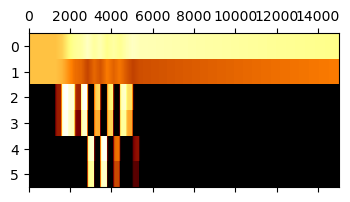

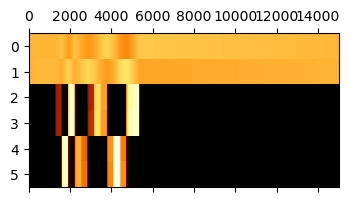

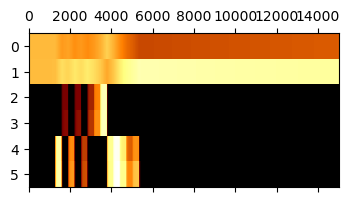

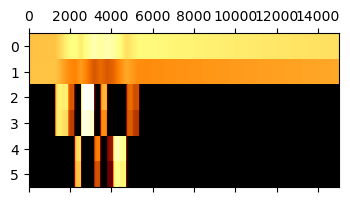

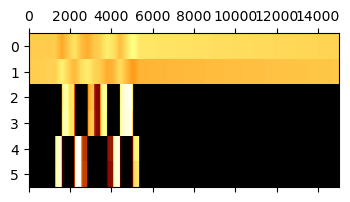

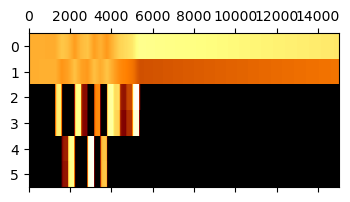

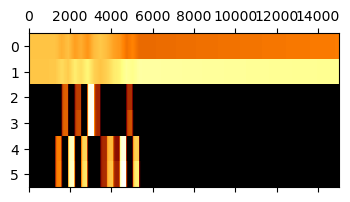

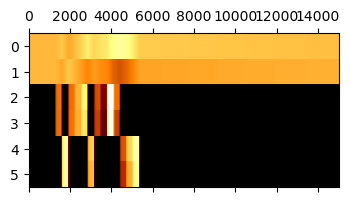

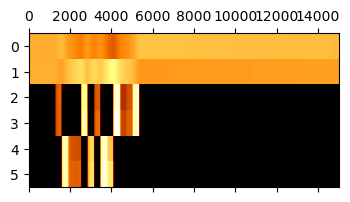

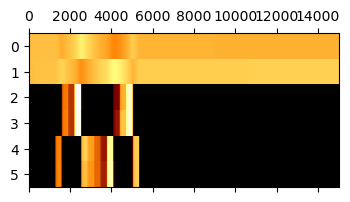

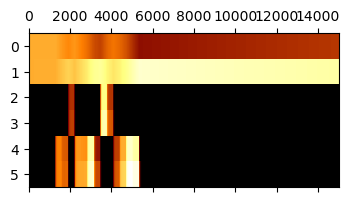

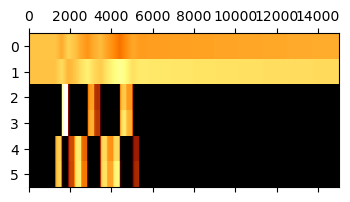

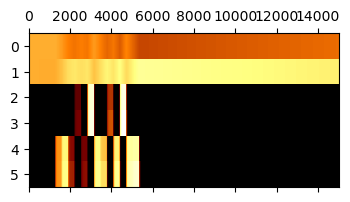

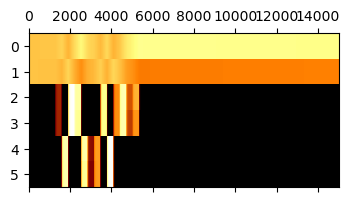

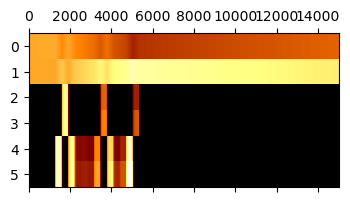

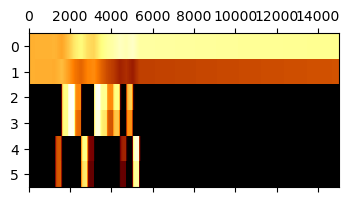

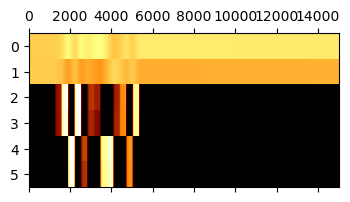

In [27]:
# del data
data = pickle.load(open('./network_training_results.pkl', 'rb'))
results = data['results']
t = data['t']

# Plot results
fig_w, fig_w_traj = plot_results(results, t, n=2)

/tmp/ipykernel_3544794/2686733309.py:2: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  data = pickle.load(open('./network_training_results_w_change_w_ii.pkl', 'rb'))
/tmp/ipykernel_3544794/932663340.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 4000x1200 with 31 Axes> than <Figure size 4000x300 with 10 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[0, i], fraction=0.03)
/tmp/ipykernel_3544794/932663340.py:27: UserWarning: Adding colorbar to a different Figure <Figure size 4000x1200 with 32 Axes> than <Figure size 4000x300 with 10 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[1, i], fraction=0.03)
/tmp/ipykernel_3544794/932663340.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 4000x1200 with 33 Axes> than <Figure size 4000x300 with 10 Axes> which fig.colorbar 

0


/tmp/ipykernel_3544794/932663340.py:136: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(4, 2))


corr 0.7567735364495688
1
corr 0.8695459145072925
2
corr 0.9679765345881368
3
corr 0.8993610363744117
4
corr 0.9014626845038367
5
corr 0.9004083110101858
6
corr 0.9287092754366698
7
corr 0.8569807664012159
8
corr 0.886812457459107
9
corr 0.937330660716502


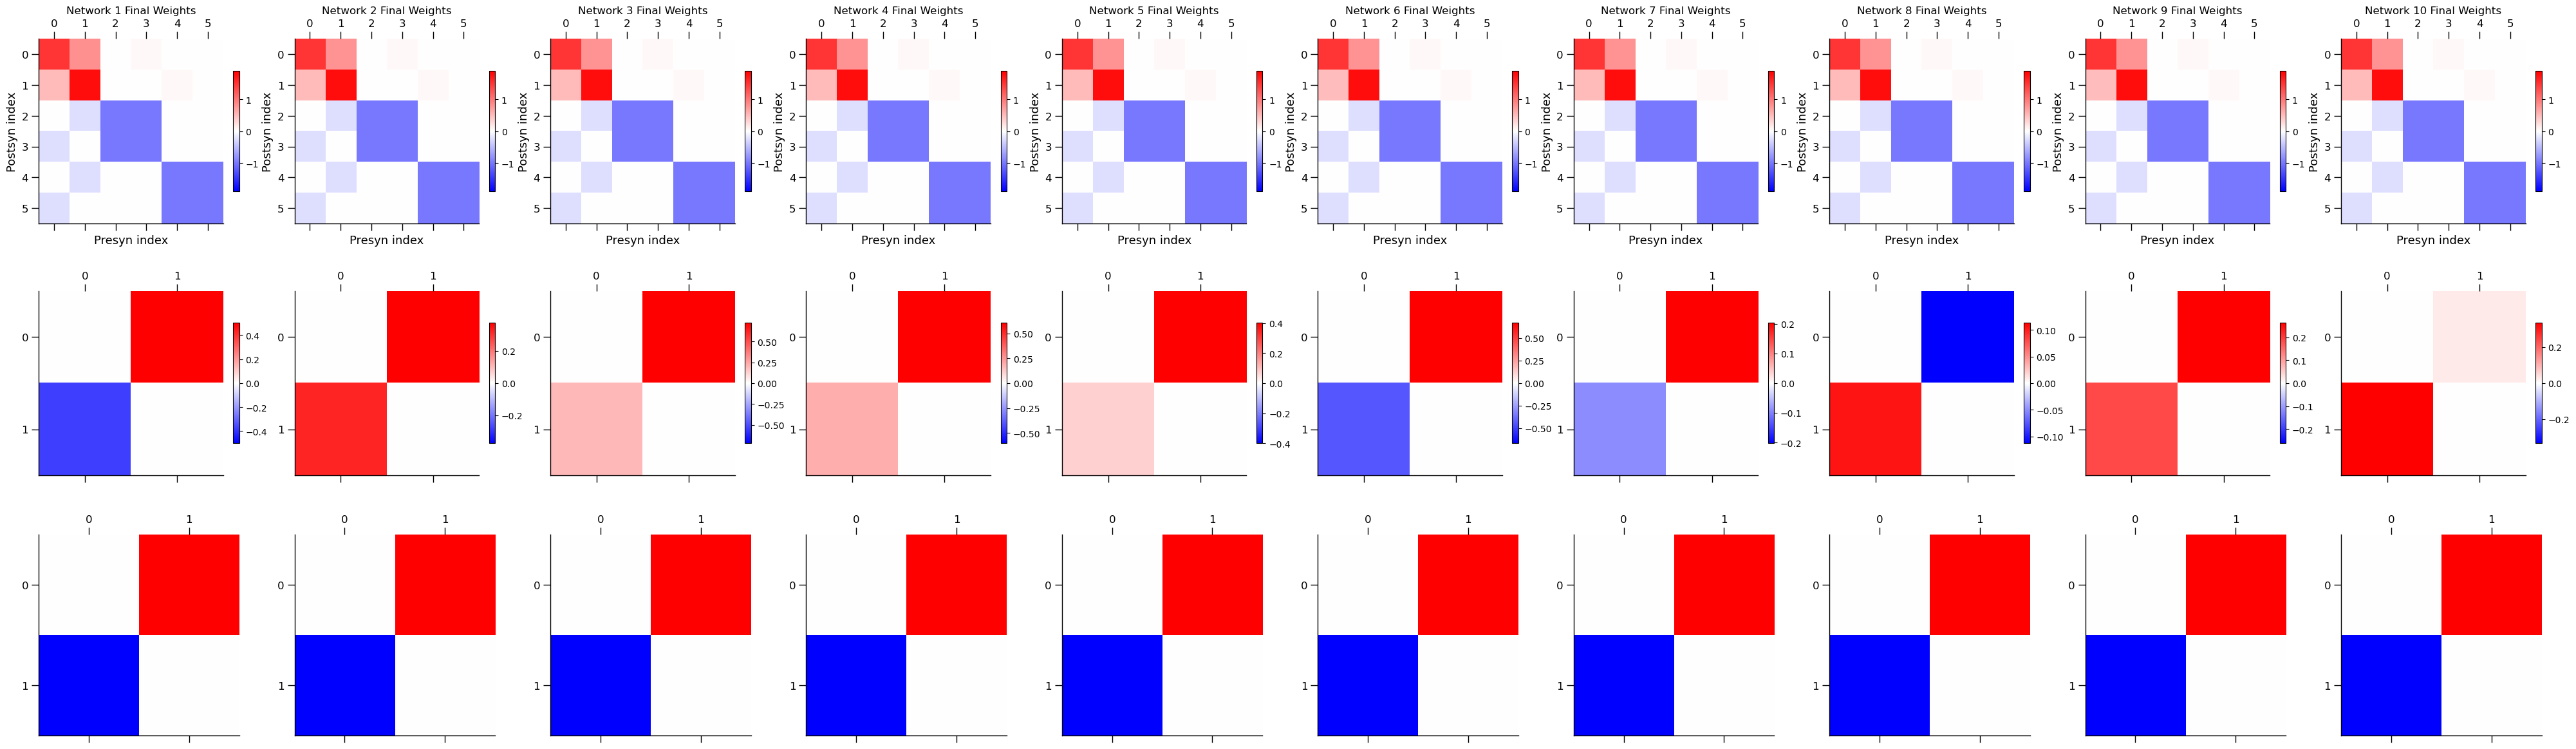

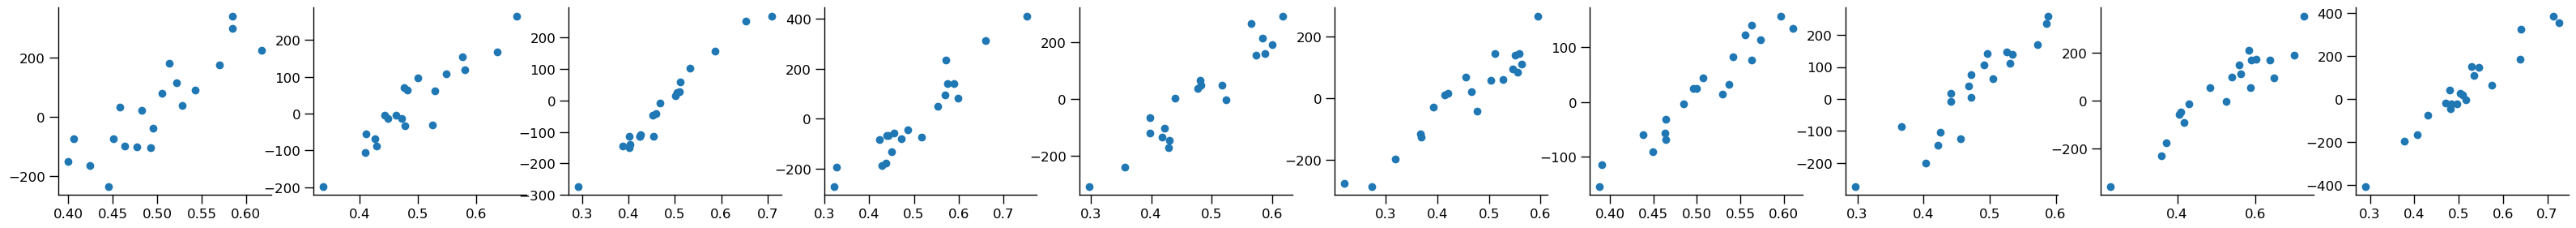

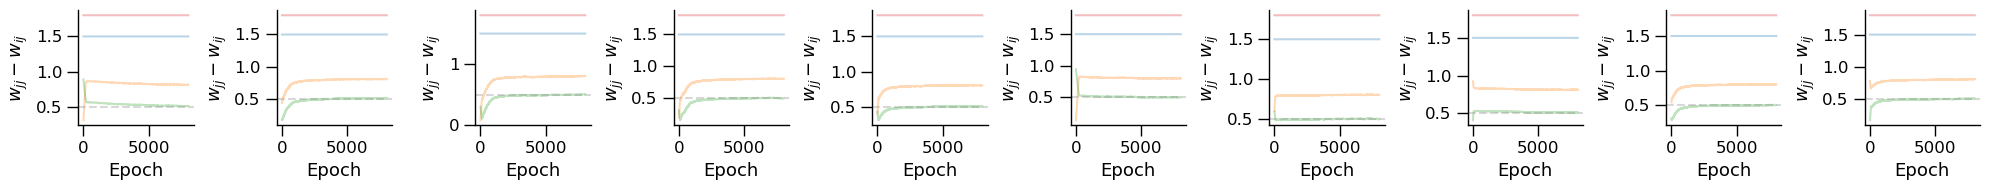

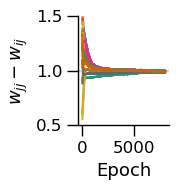

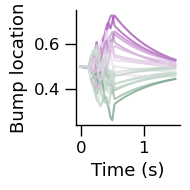

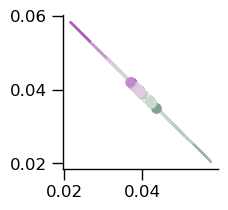

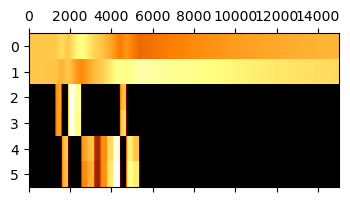

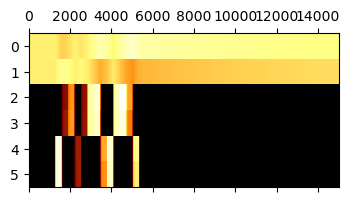

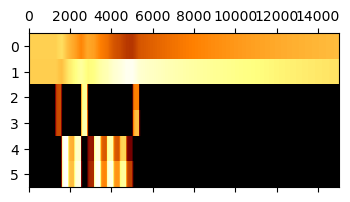

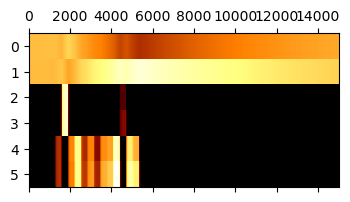

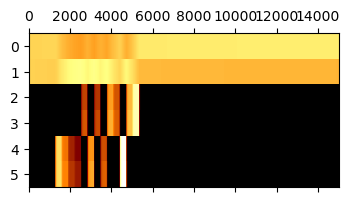

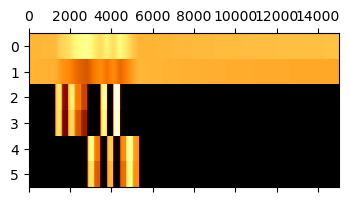

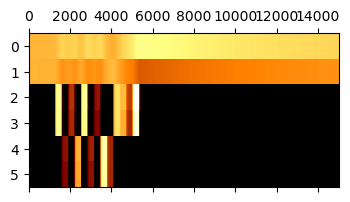

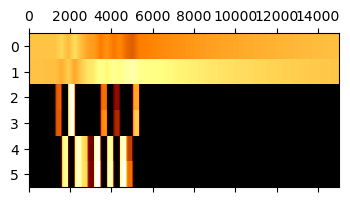

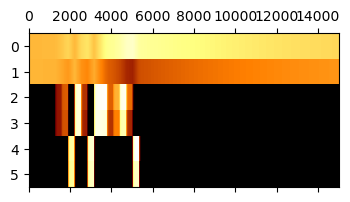

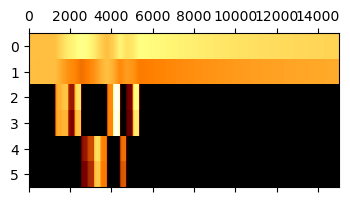

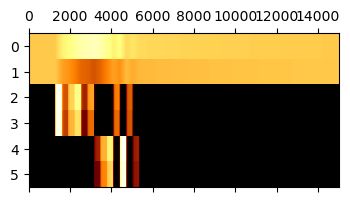

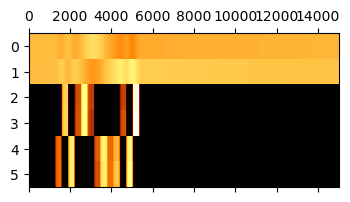

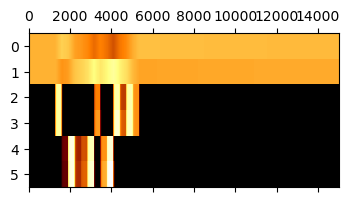

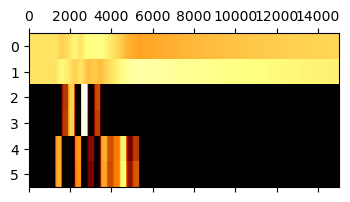

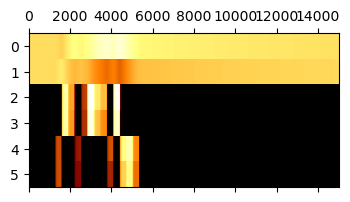

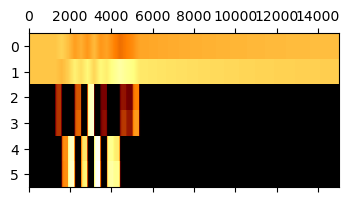

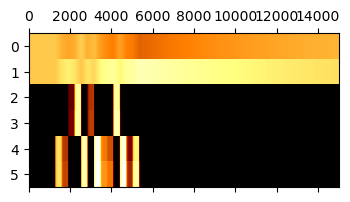

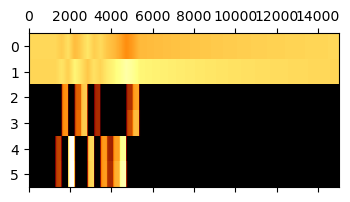

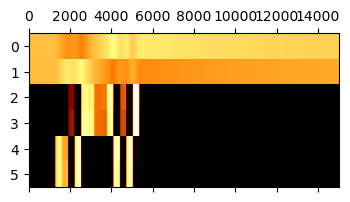

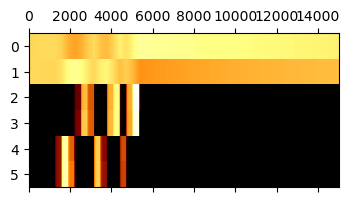

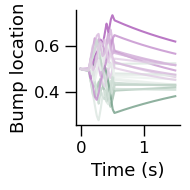

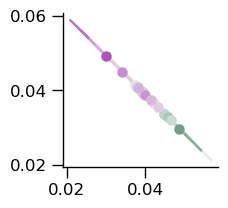

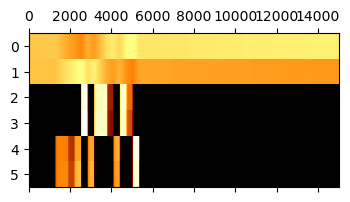

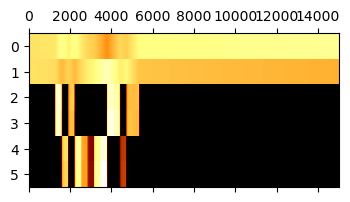

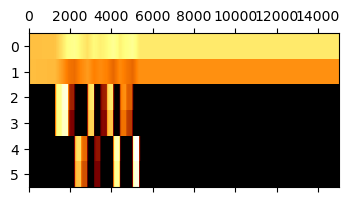

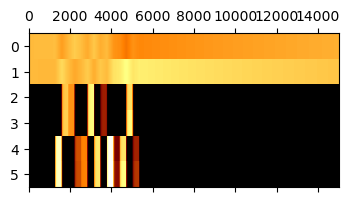

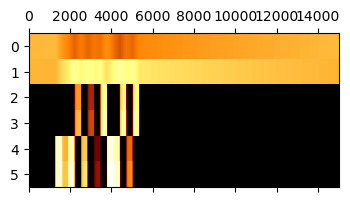

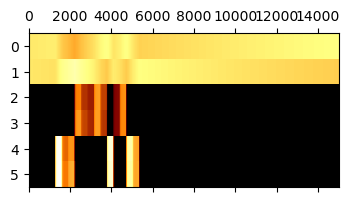

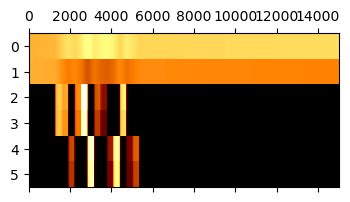

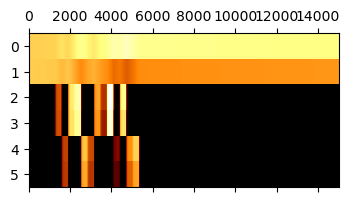

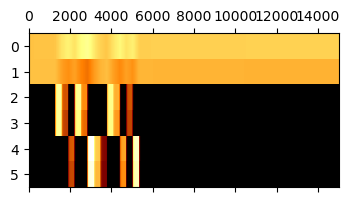

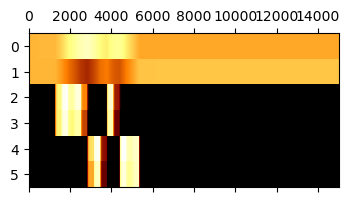

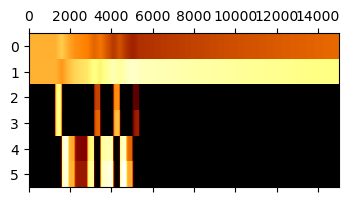

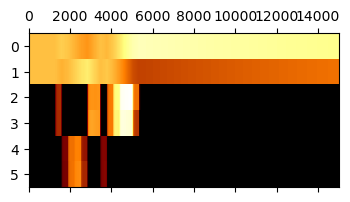

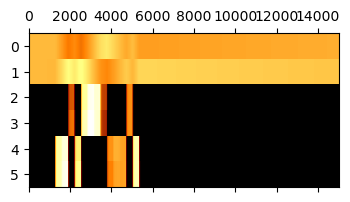

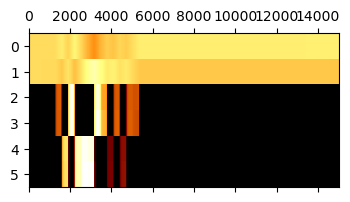

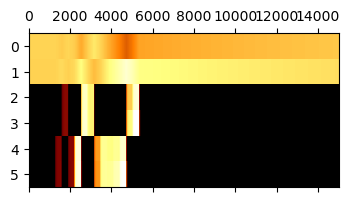

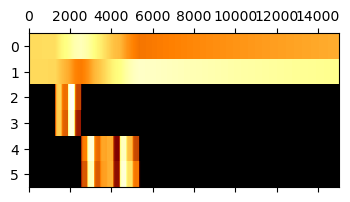

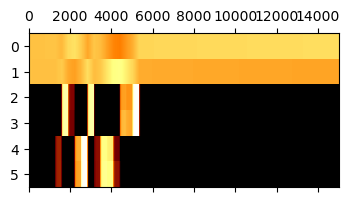

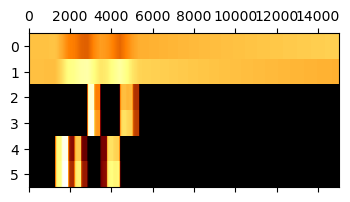

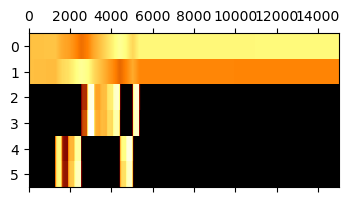

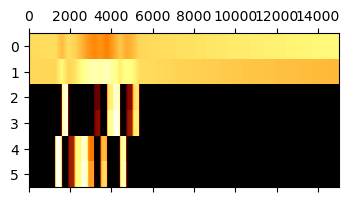

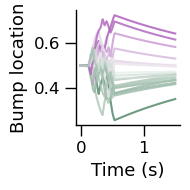

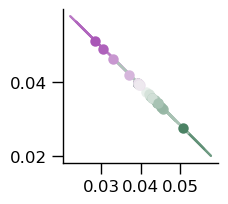

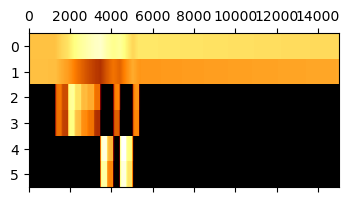

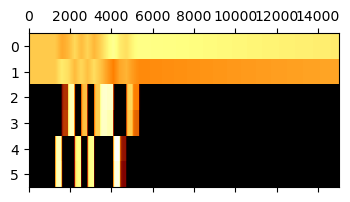

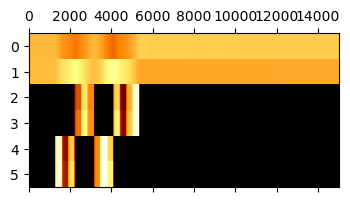

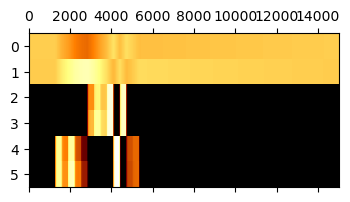

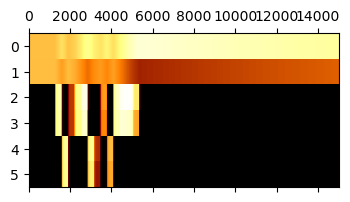

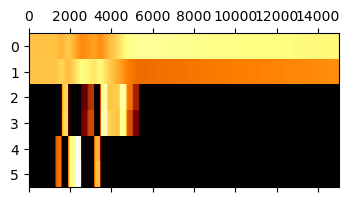

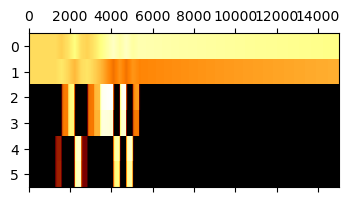

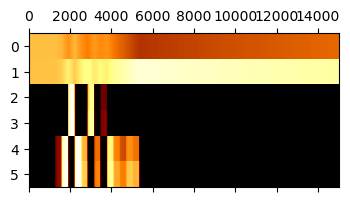

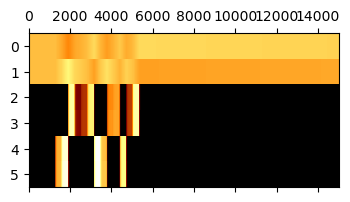

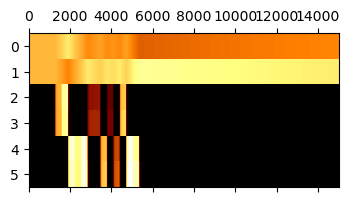

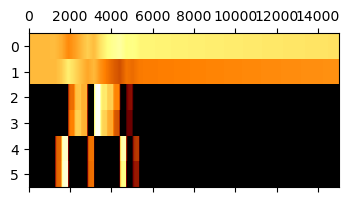

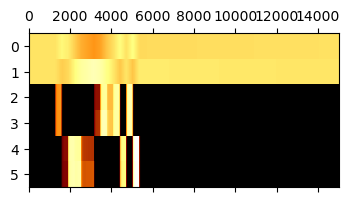

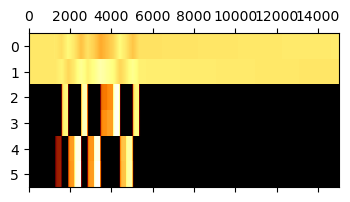

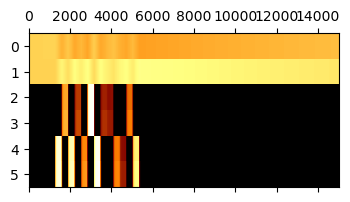

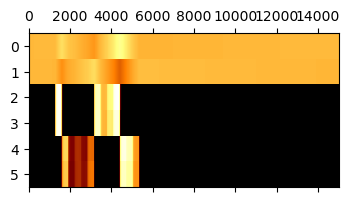

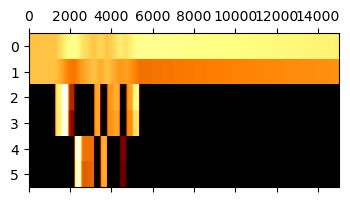

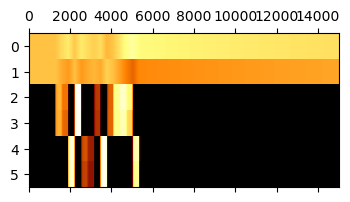

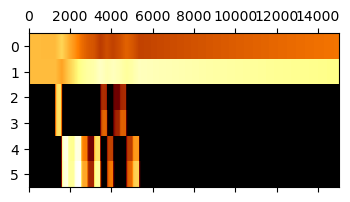

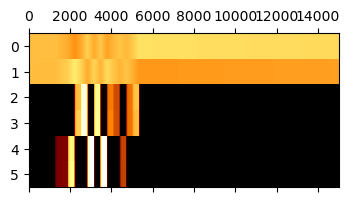

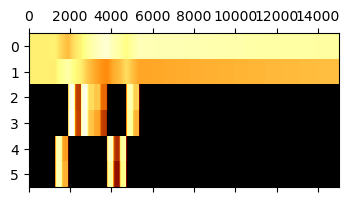

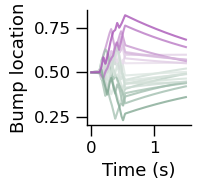

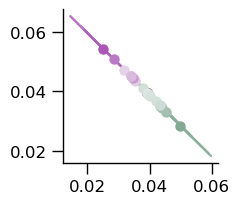

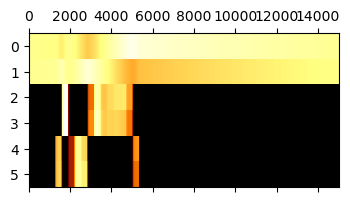

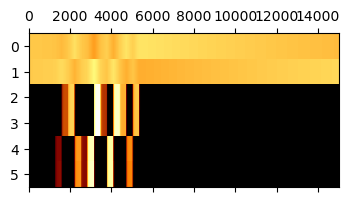

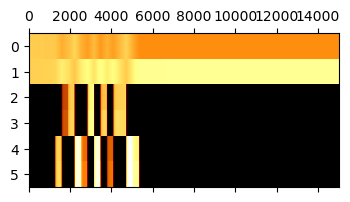

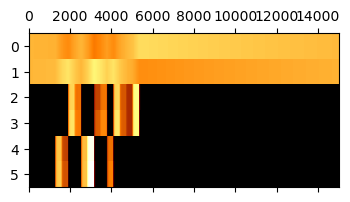

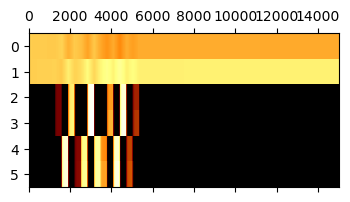

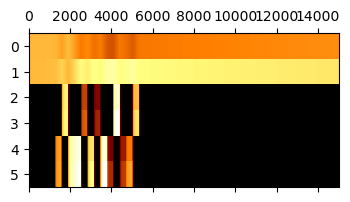

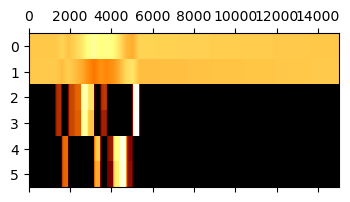

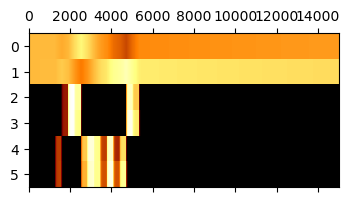

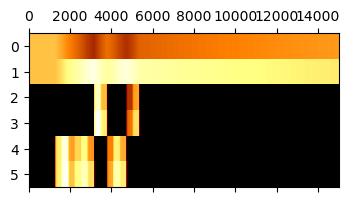

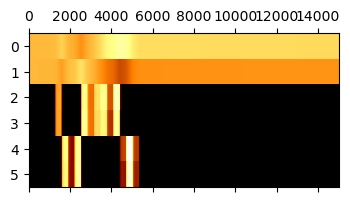

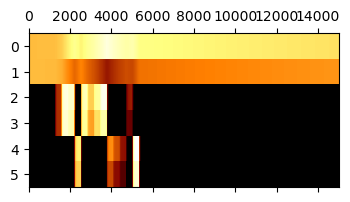

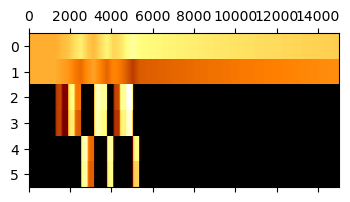

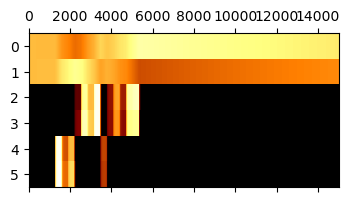

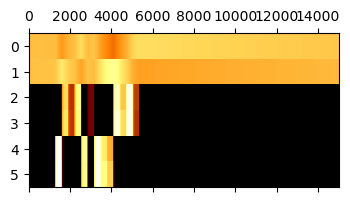

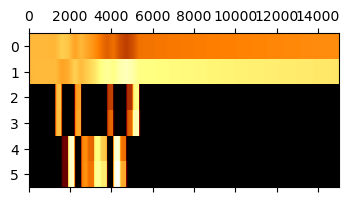

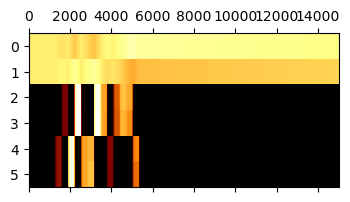

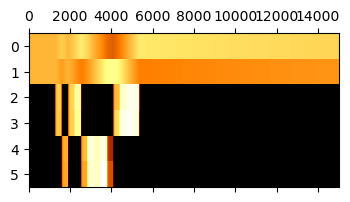

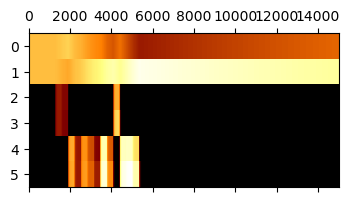

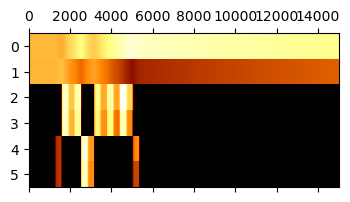

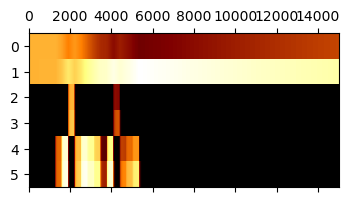

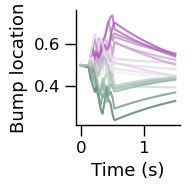

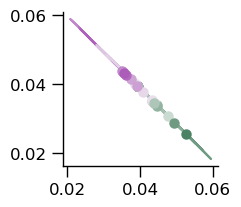

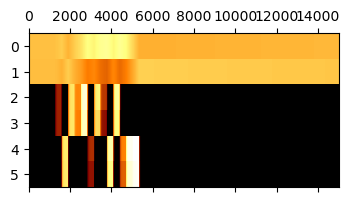

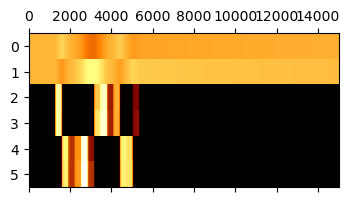

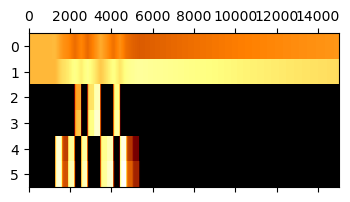

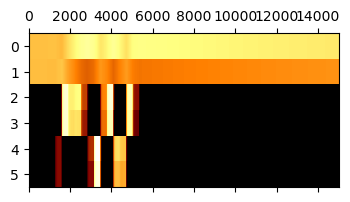

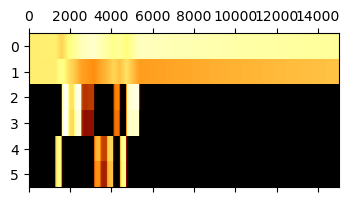

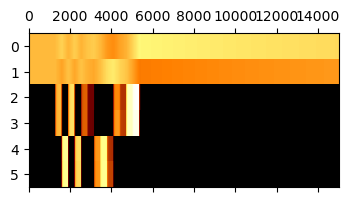

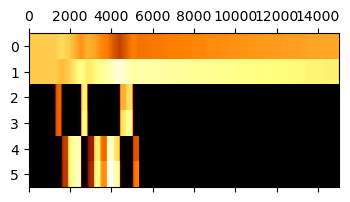

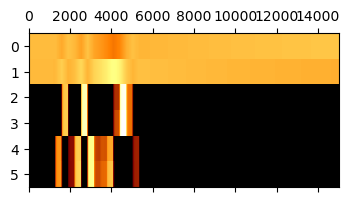

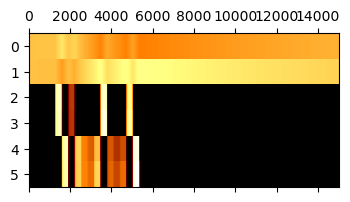

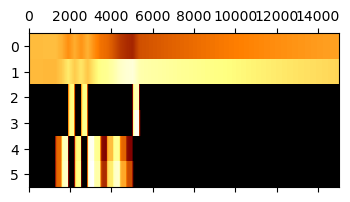

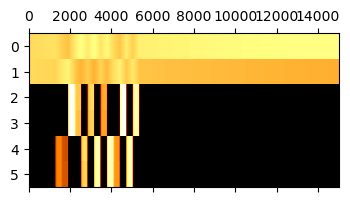

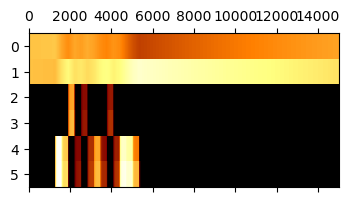

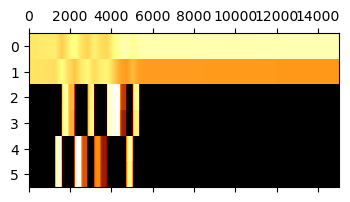

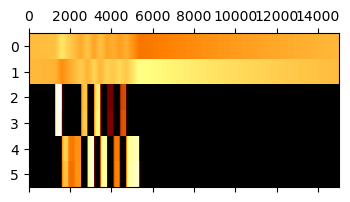

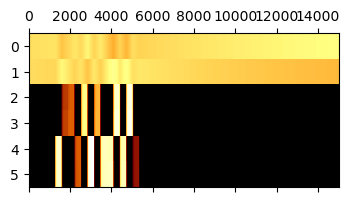

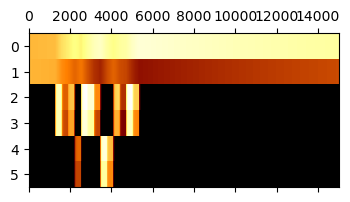

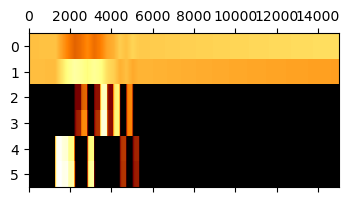

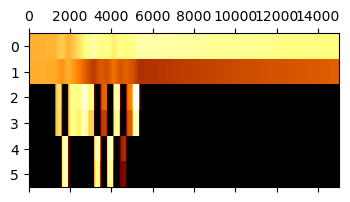

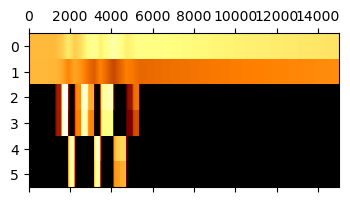

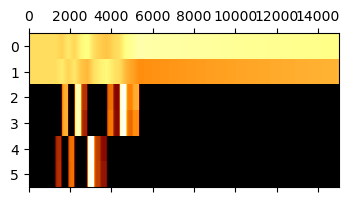

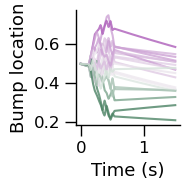

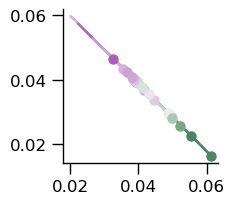

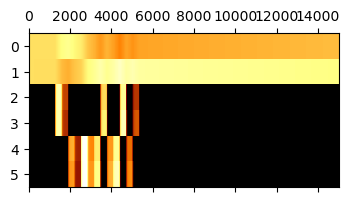

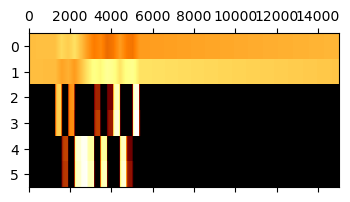

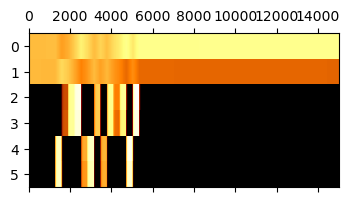

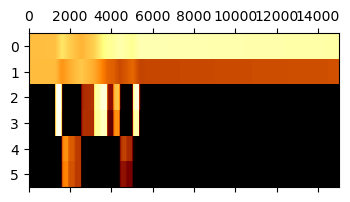

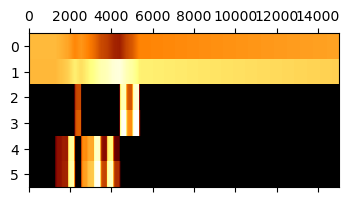

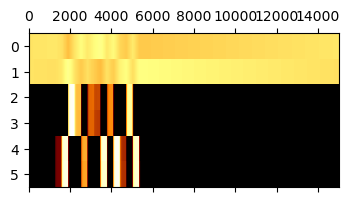

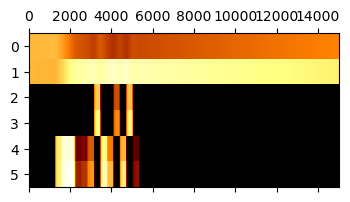

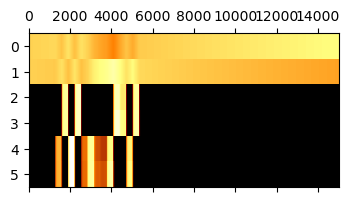

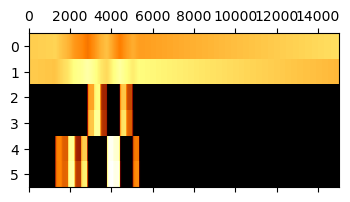

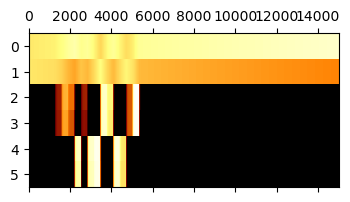

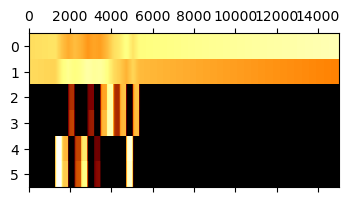

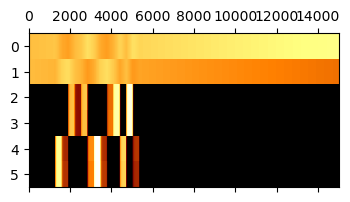

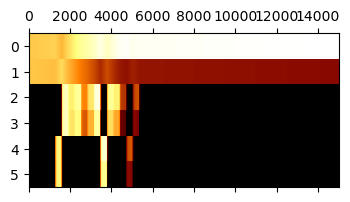

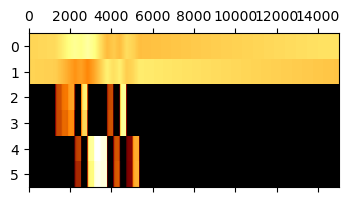

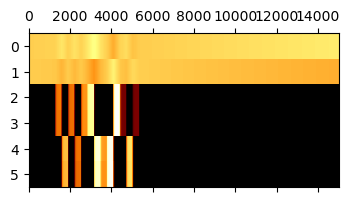

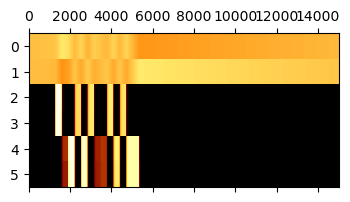

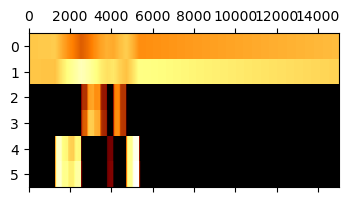

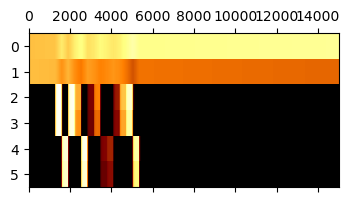

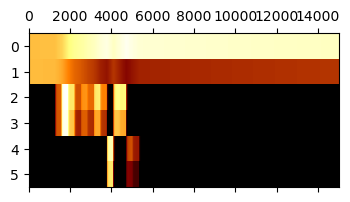

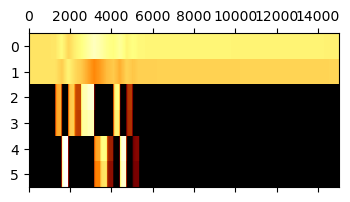

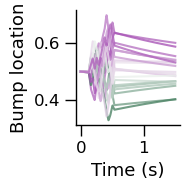

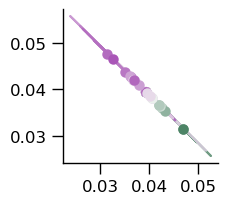

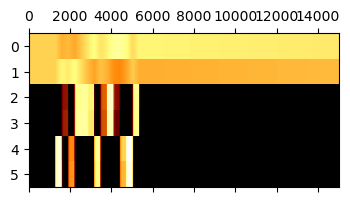

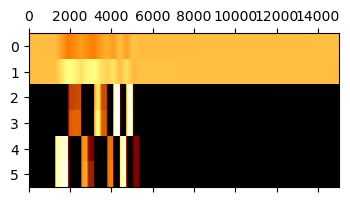

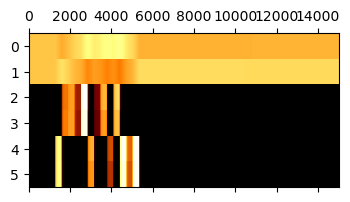

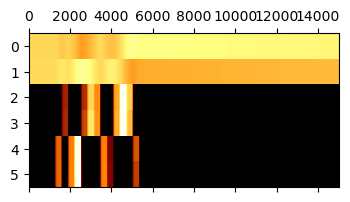

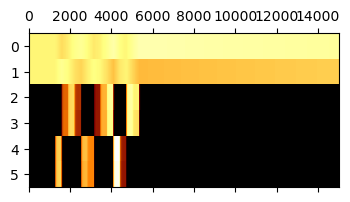

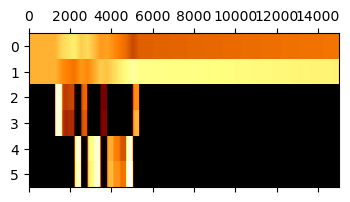

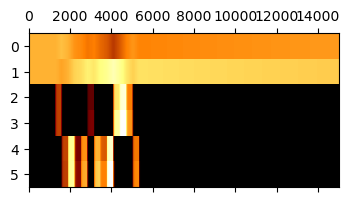

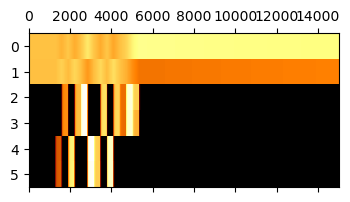

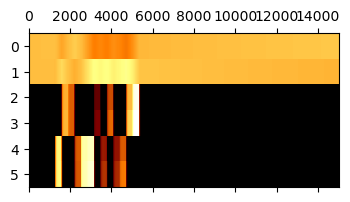

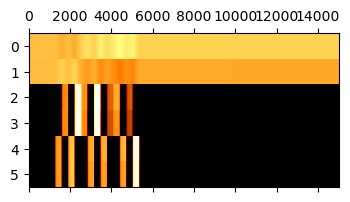

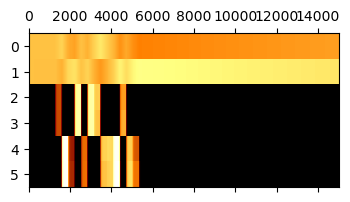

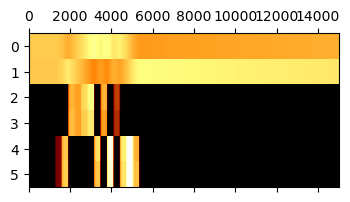

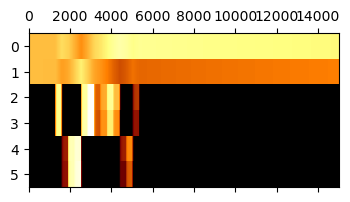

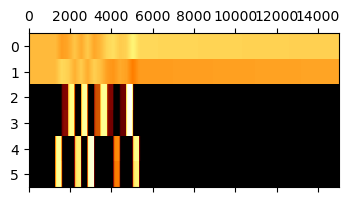

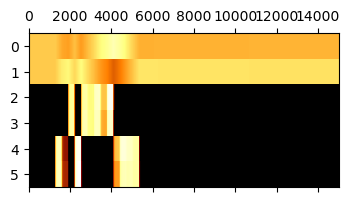

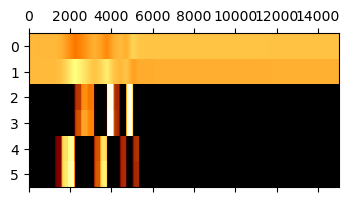

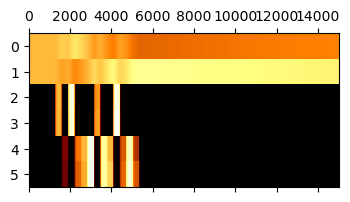

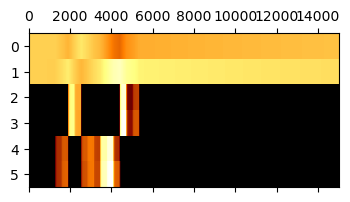

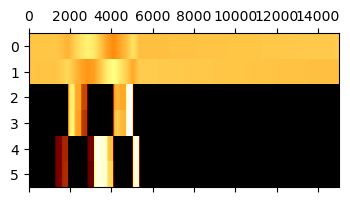

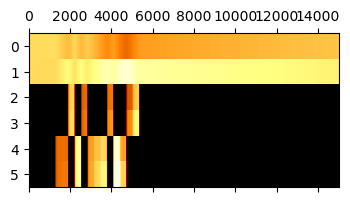

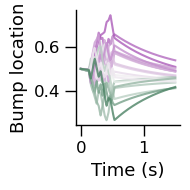

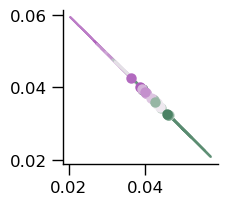

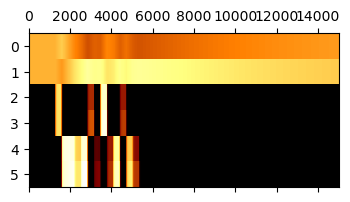

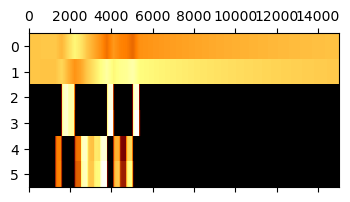

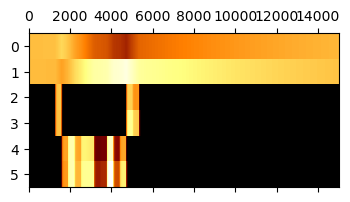

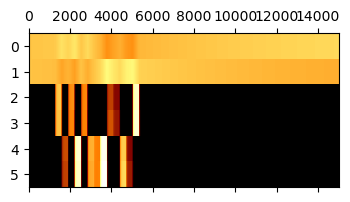

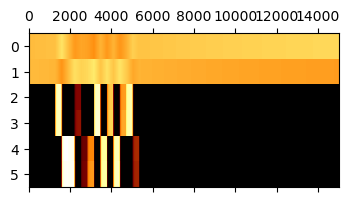

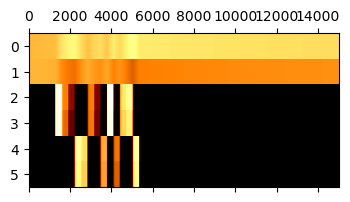

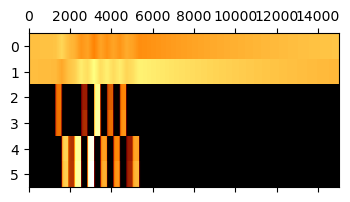

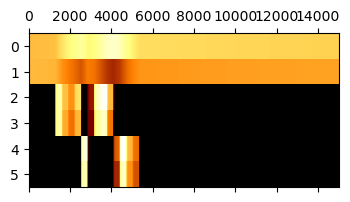

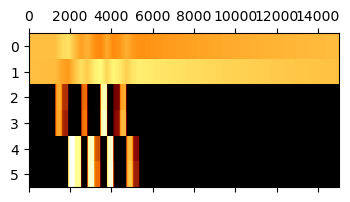

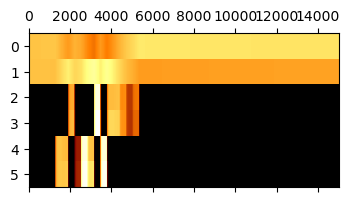

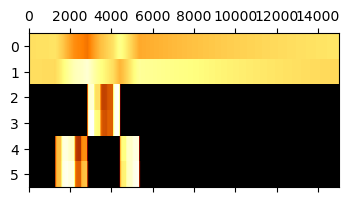

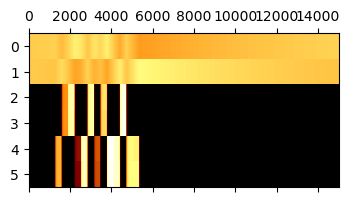

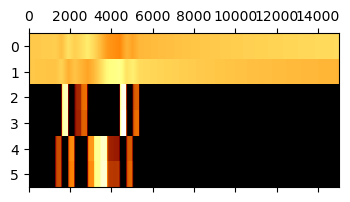

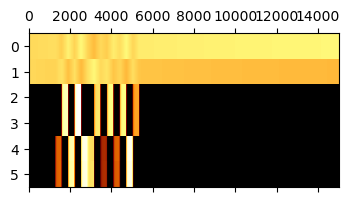

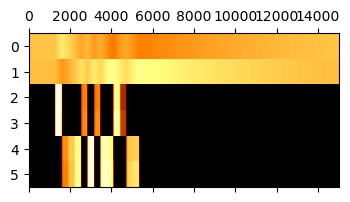

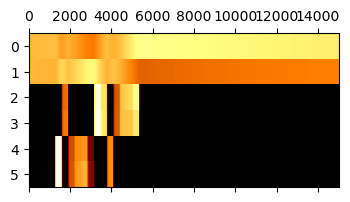

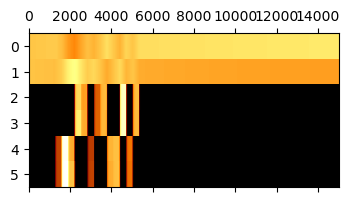

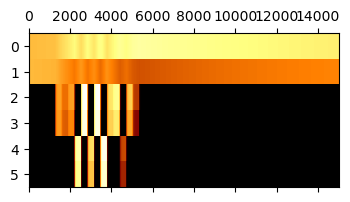

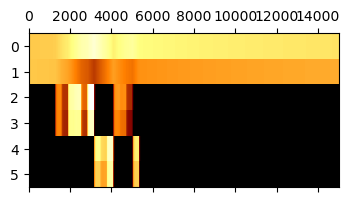

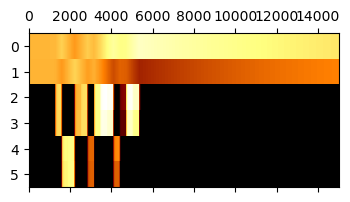

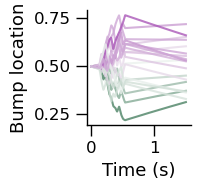

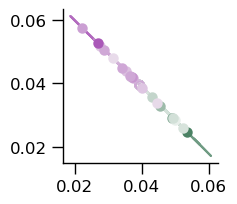

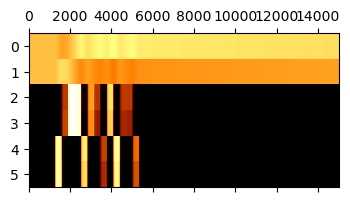

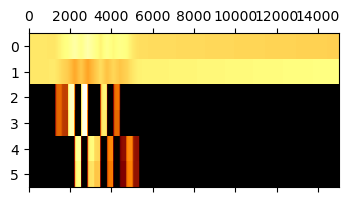

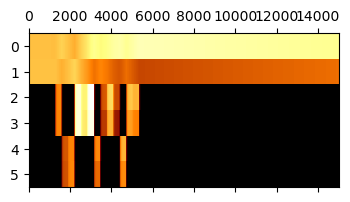

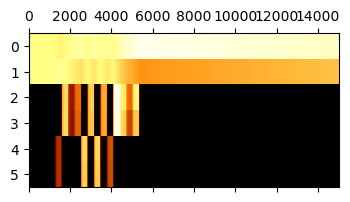

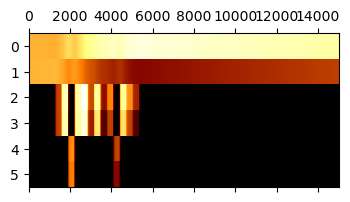

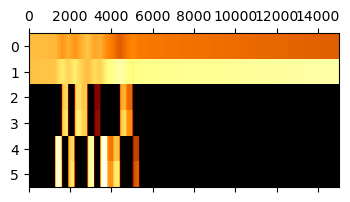

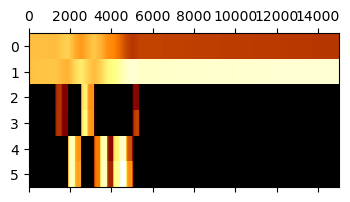

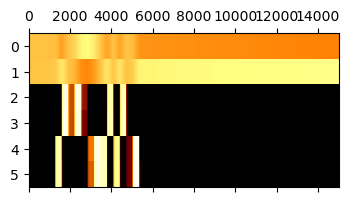

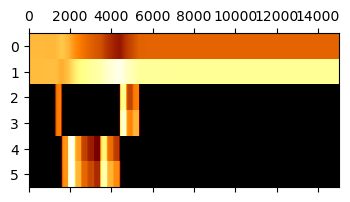

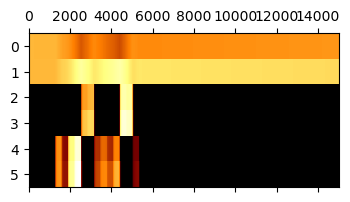

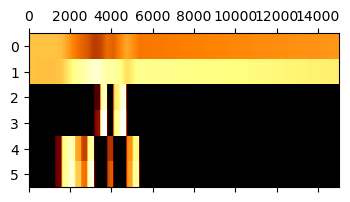

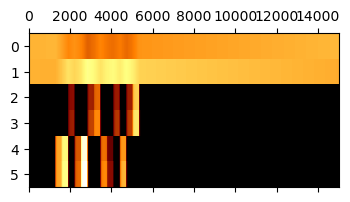

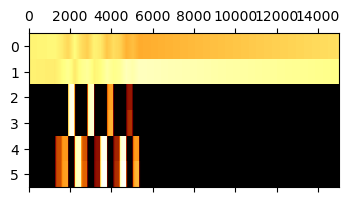

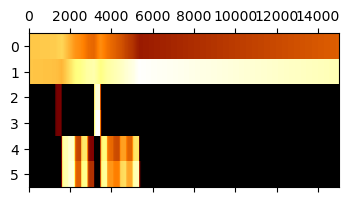

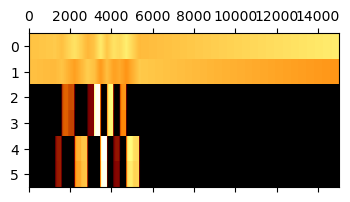

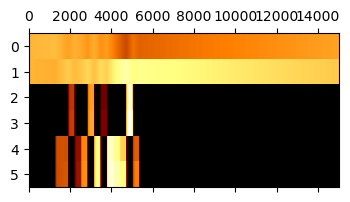

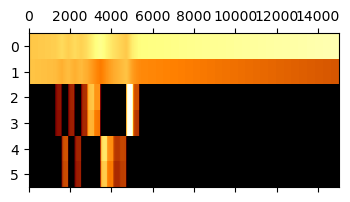

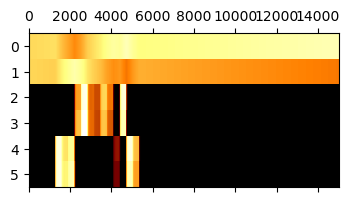

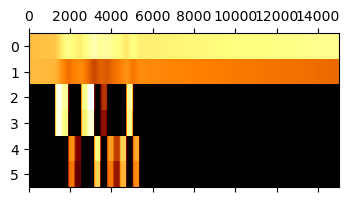

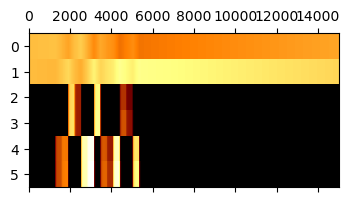

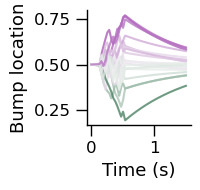

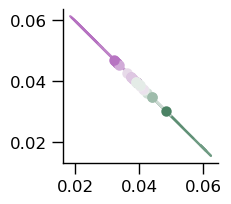

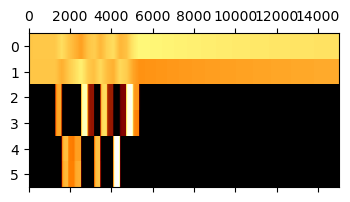

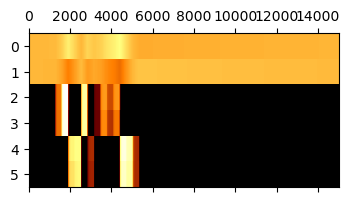

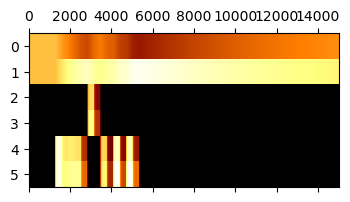

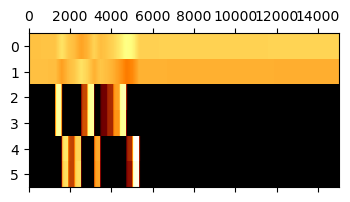

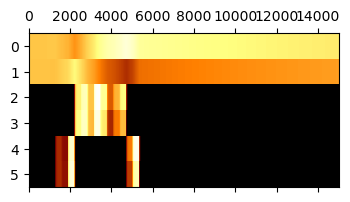

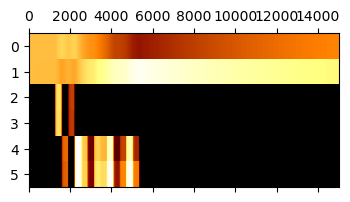

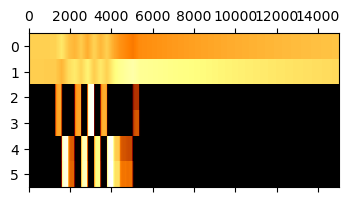

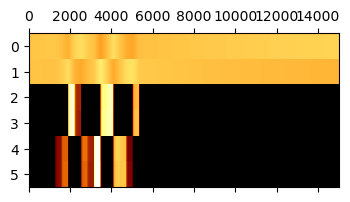

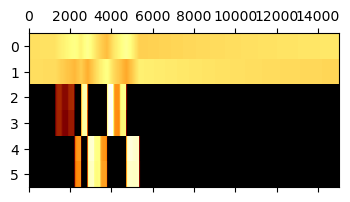

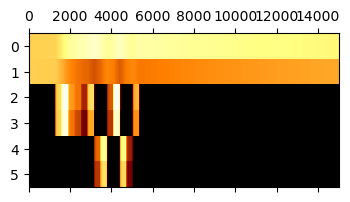

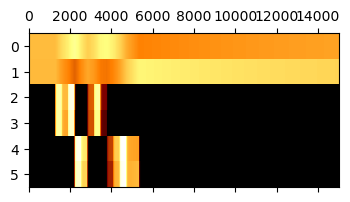

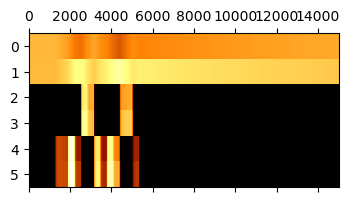

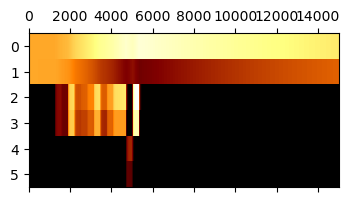

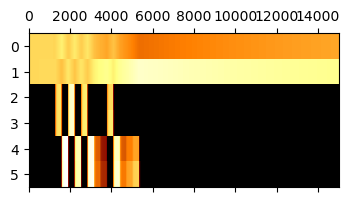

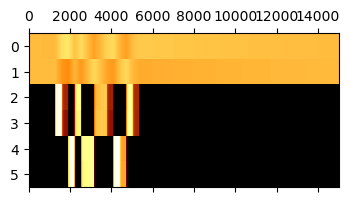

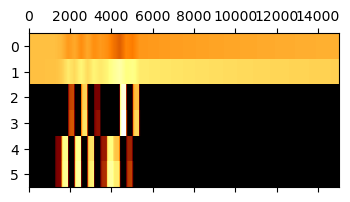

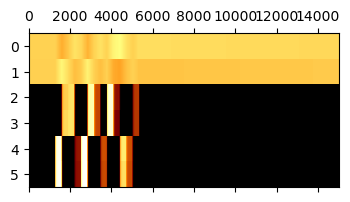

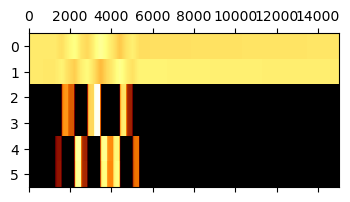

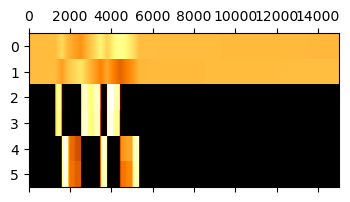

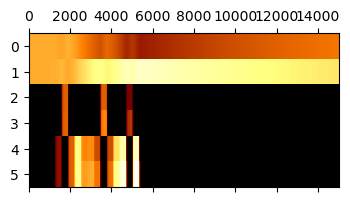

In [13]:
# del data
data = pickle.load(open('./network_training_results_w_change_w_ii.pkl', 'rb'))
results = data['results']
t = data['t']

# Plot results
fig_w, fig_w_traj = plot_results(results, t, n=2)

/tmp/ipykernel_3888602/3866924990.py:2: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  data = pickle.load(open('./network_training_results_w_change_new_no_3.pkl', 'rb'))
/tmp/ipykernel_3888602/1679037112.py:18: UserWarning: Adding colorbar to a different Figure <Figure size 1200x800 with 7 Axes> than <Figure size 1200x300 with 3 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[0, i], fraction=0.03)
/tmp/ipykernel_3888602/1679037112.py:25: UserWarning: Adding colorbar to a different Figure <Figure size 1200x800 with 8 Axes> than <Figure size 1200x300 with 3 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[1, i], fraction=0.03)
/tmp/ipykernel_3888602/1679037112.py:18: UserWarning: Adding colorbar to a different Figure <Figure size 1200x800 with 9 Axes> than <Figure size 1200x300 with 3 Axes> which fig.colorbar is

[[ 1.5         0.75751056  0.          0.05        0.          0.        ]
 [ 0.45519923  1.8         0.          0.          0.05        0.        ]
 [ 0.         -0.25       -1.         -1.          0.          0.        ]
 [-0.25        0.         -1.         -1.          0.          0.        ]
 [ 0.         -0.25        0.          0.         -1.         -1.        ]
 [-0.25        0.          0.          0.         -1.         -1.        ]]
1.0424894380725673
1.0448007683140244
[[ 1.5         0.76111596  0.          0.05        0.          0.        ]
 [ 0.45621684  1.8         0.          0.          0.05        0.        ]
 [ 0.         -0.25       -1.         -1.          0.          0.        ]
 [-0.25        0.         -1.         -1.          0.          0.        ]
 [ 0.         -0.25        0.          0.         -1.         -1.        ]
 [-0.25        0.          0.          0.         -1.         -1.        ]]
1.0388840406782922
1.0437831580511463
[[ 1.5         0.75692

/tmp/ipykernel_3888602/1679037112.py:125: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(4, 2))


corr 0.6795663036931574
1
corr 0.5151685810220871
2
corr 0.5559158690201168


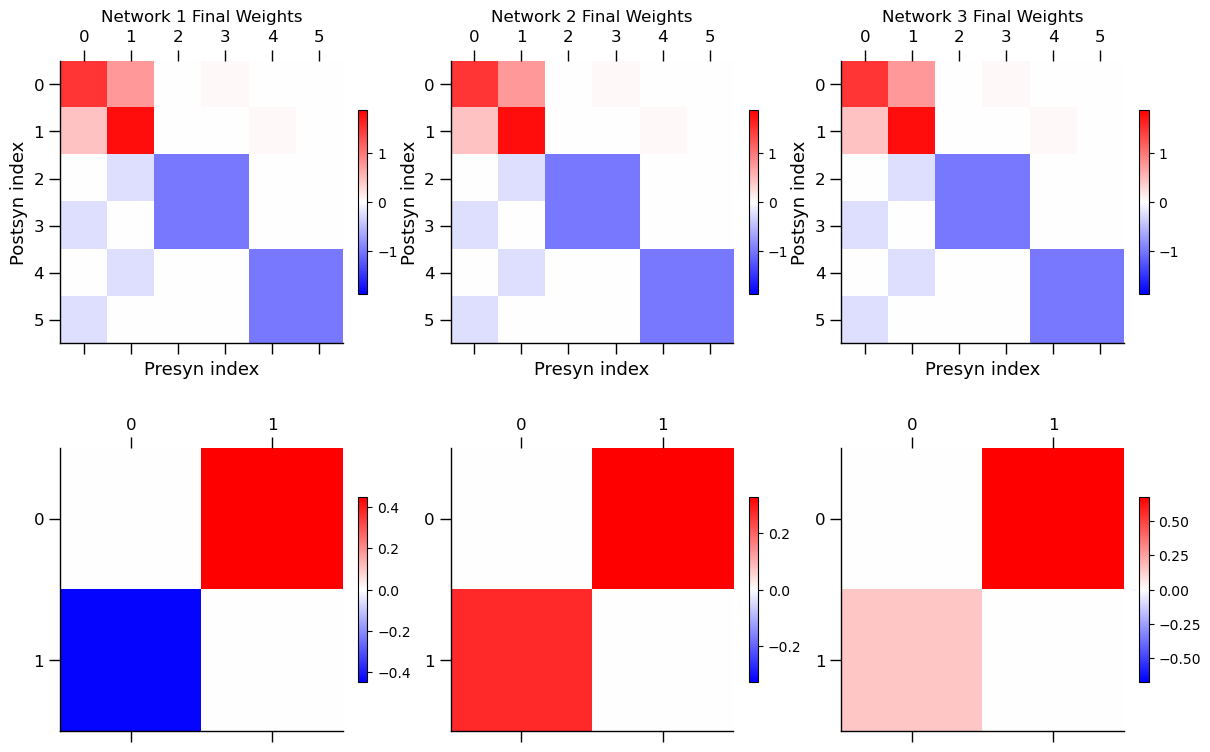

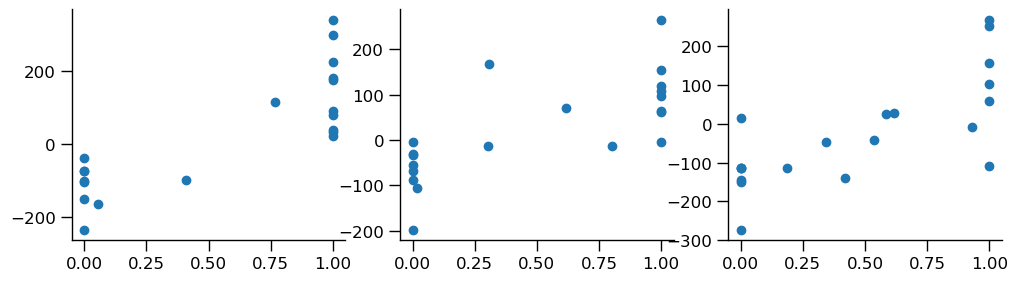

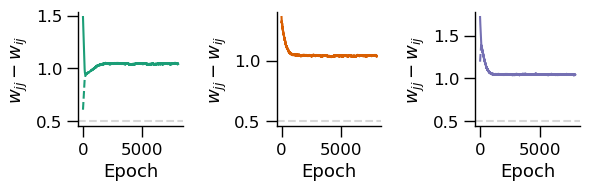

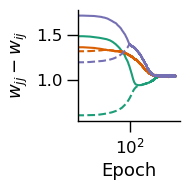

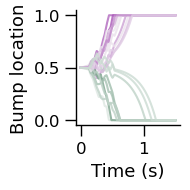

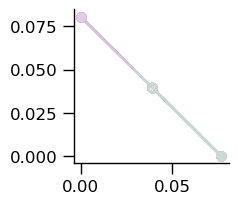

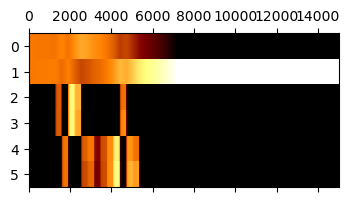

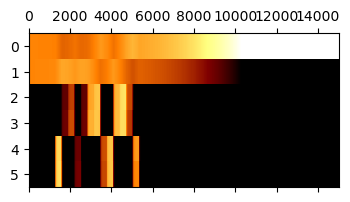

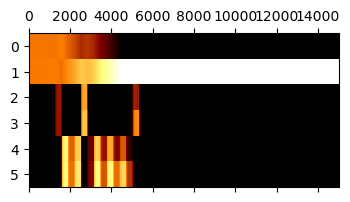

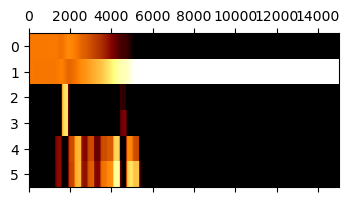

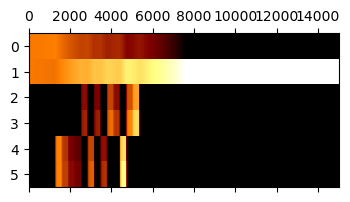

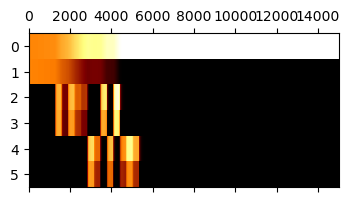

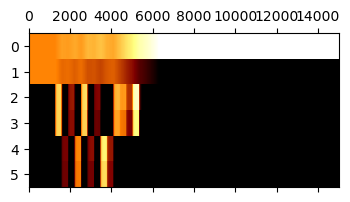

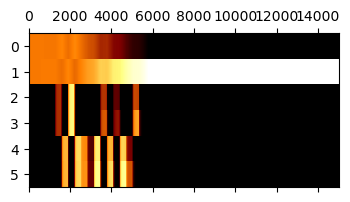

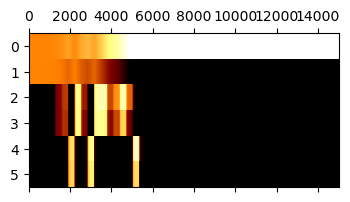

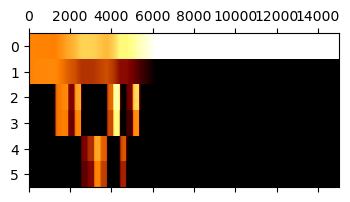

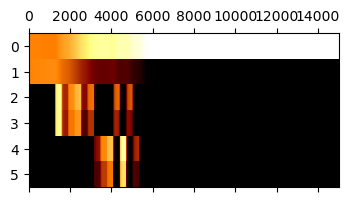

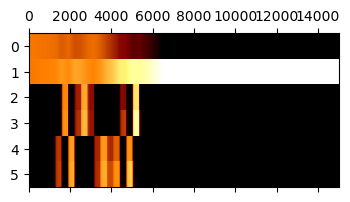

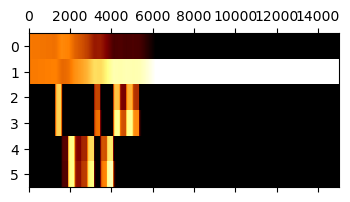

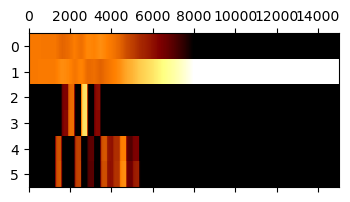

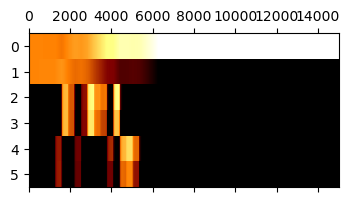

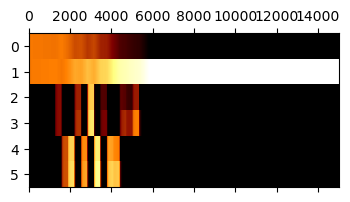

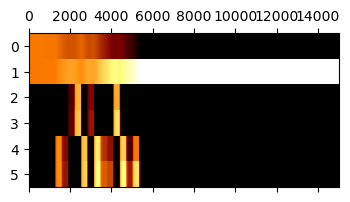

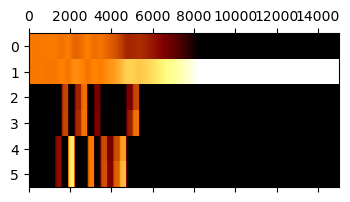

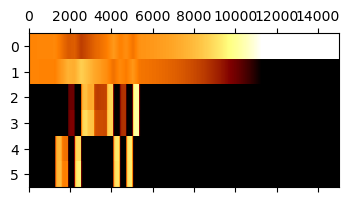

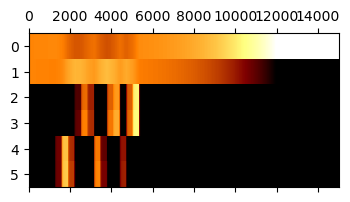

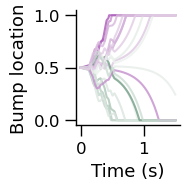

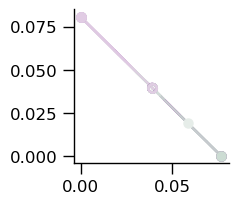

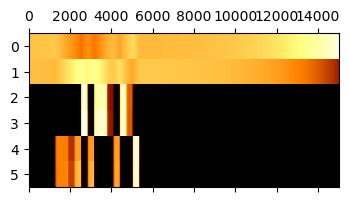

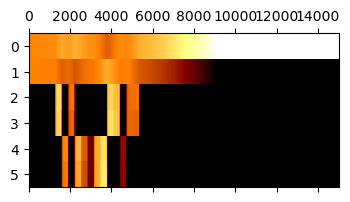

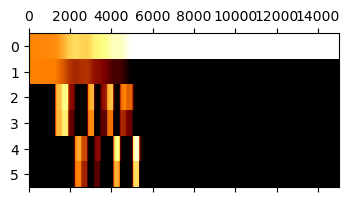

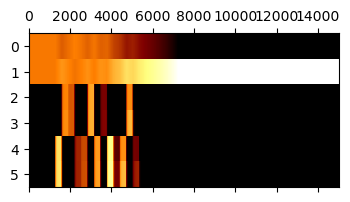

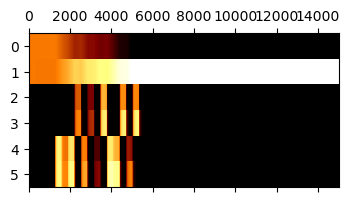

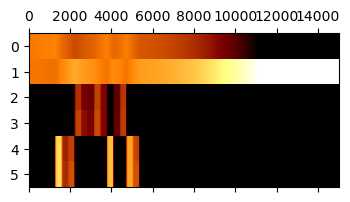

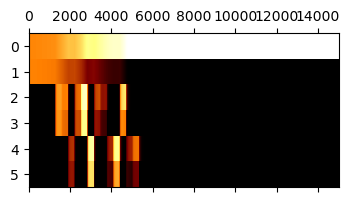

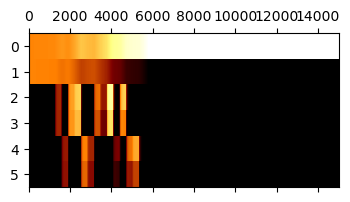

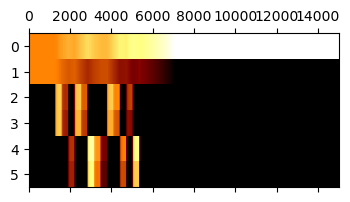

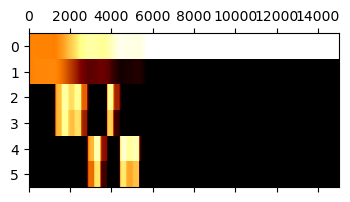

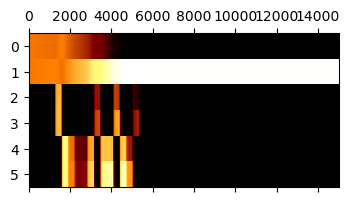

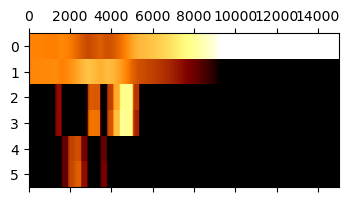

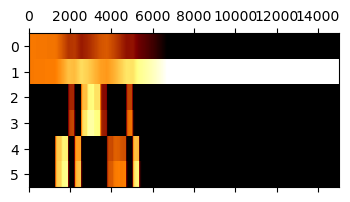

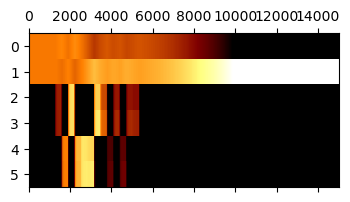

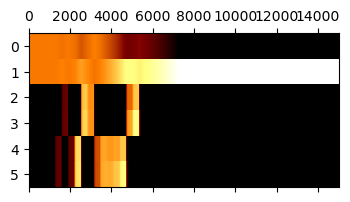

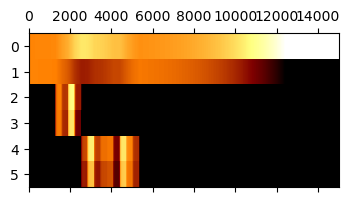

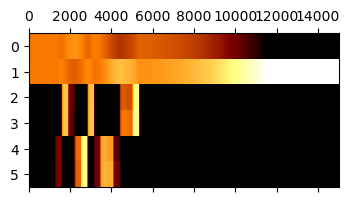

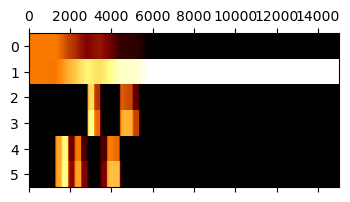

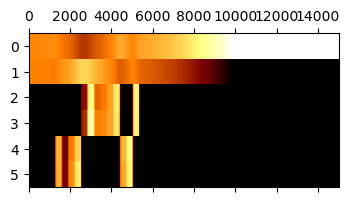

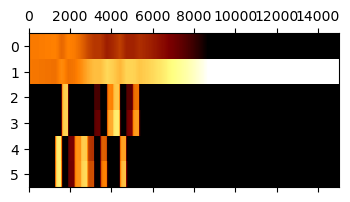

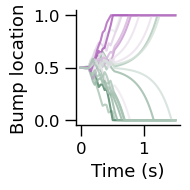

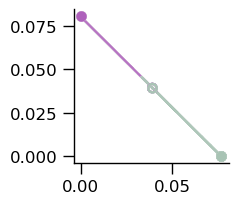

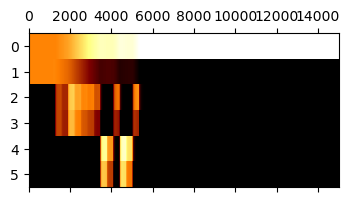

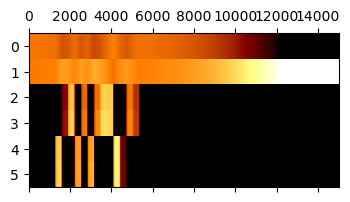

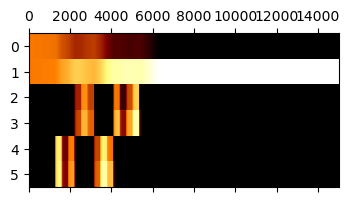

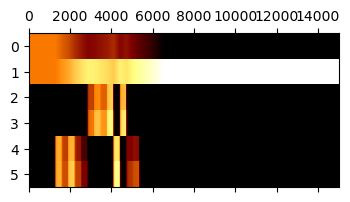

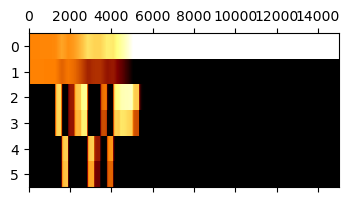

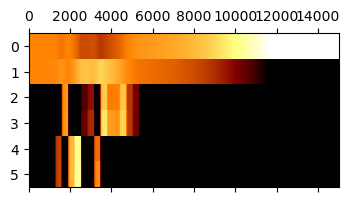

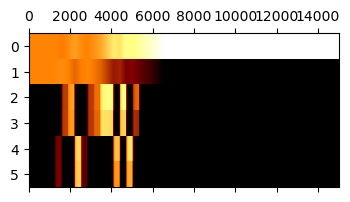

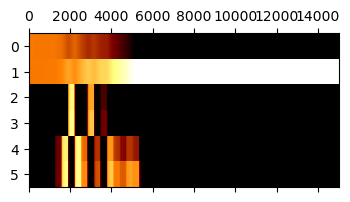

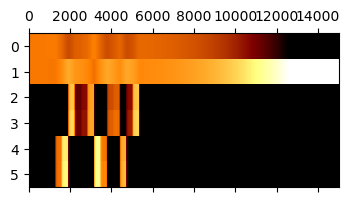

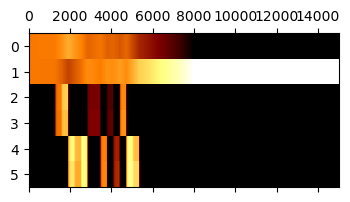

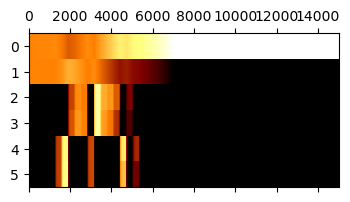

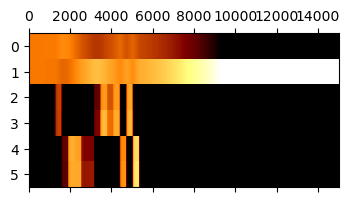

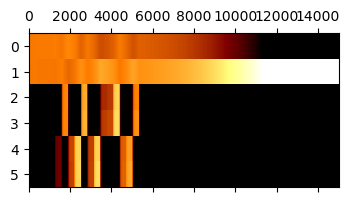

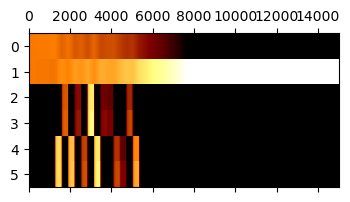

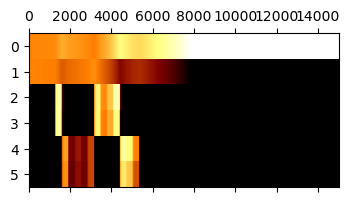

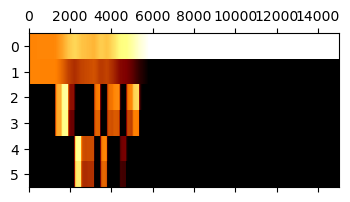

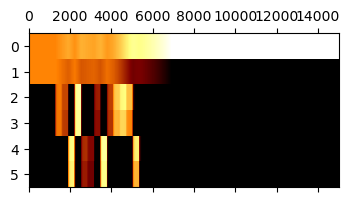

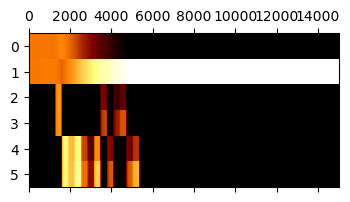

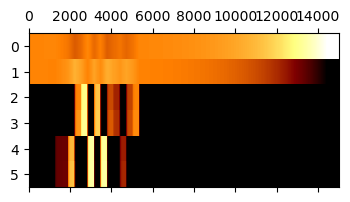

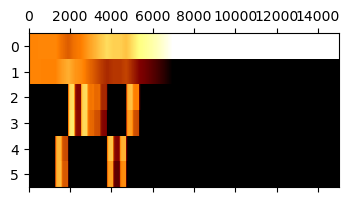

In [28]:
# del data
data = pickle.load(open('./network_training_results_w_change_new_no_3.pkl', 'rb'))
results = data['results']
t = data['t']

# Plot results
fig_w, fig_w_traj = plot_results(results, t, n=2)

/tmp/ipykernel_3187441/2686733309.py:2: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  data = pickle.load(open('./network_training_results_w_change_w_ii.pkl', 'rb'))
/tmp/ipykernel_3187441/4286922569.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 4000x1200 with 31 Axes> than <Figure size 4000x300 with 10 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[0, i], fraction=0.03)
/tmp/ipykernel_3187441/4286922569.py:27: UserWarning: Adding colorbar to a different Figure <Figure size 4000x1200 with 32 Axes> than <Figure size 4000x300 with 10 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[1, i], fraction=0.03)
/tmp/ipykernel_3187441/4286922569.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 4000x1200 with 33 Axes> than <Figure size 4000x300 with 10 Axes> which fig.colorb

0
corr 0.8596831633555422
1


/tmp/ipykernel_3187441/4286922569.py:141: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(4, 2))


corr 0.8328784793421542
2
corr 0.9583346536938386
3
corr 0.9482707478525927
4
corr 0.922933523391441
5
corr 0.8801103388277687
6
corr 0.9591268402858445
7
corr 0.8722813651995688
8
corr 0.7970630803113071
9
corr 0.9435537429524873


ValueError: too many values to unpack (expected 2)

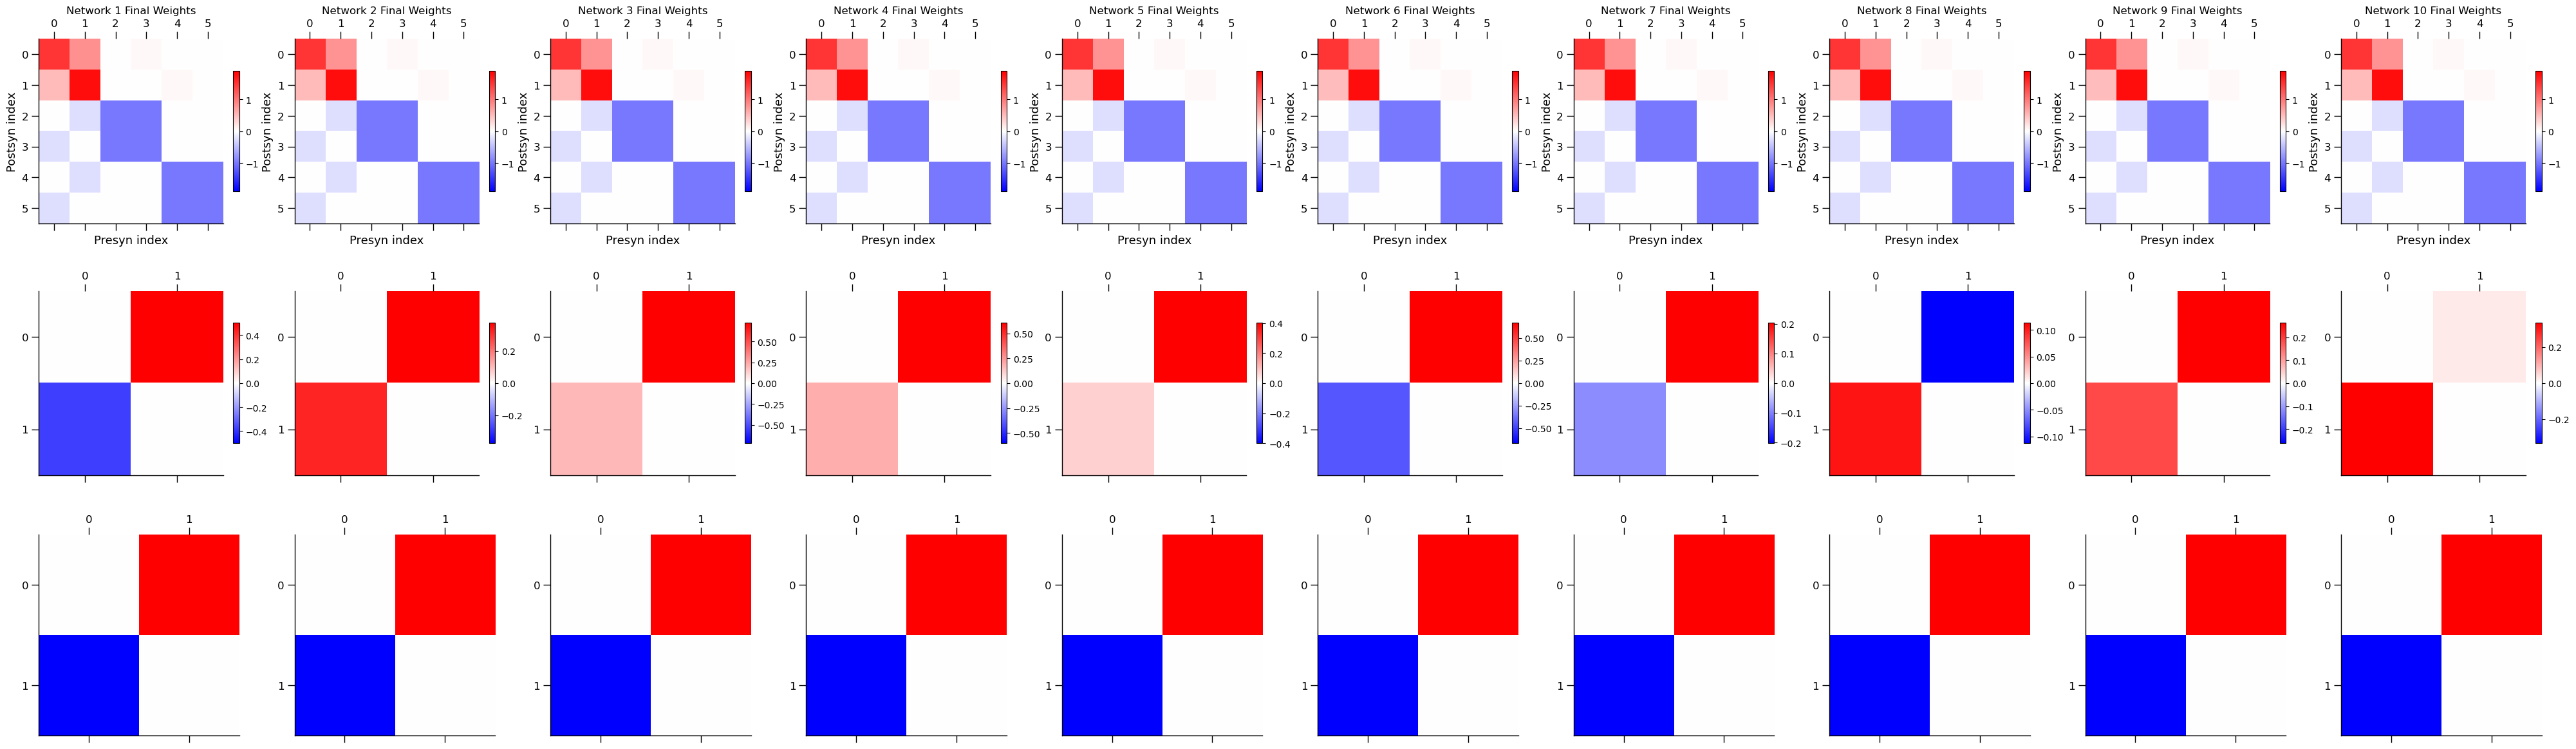

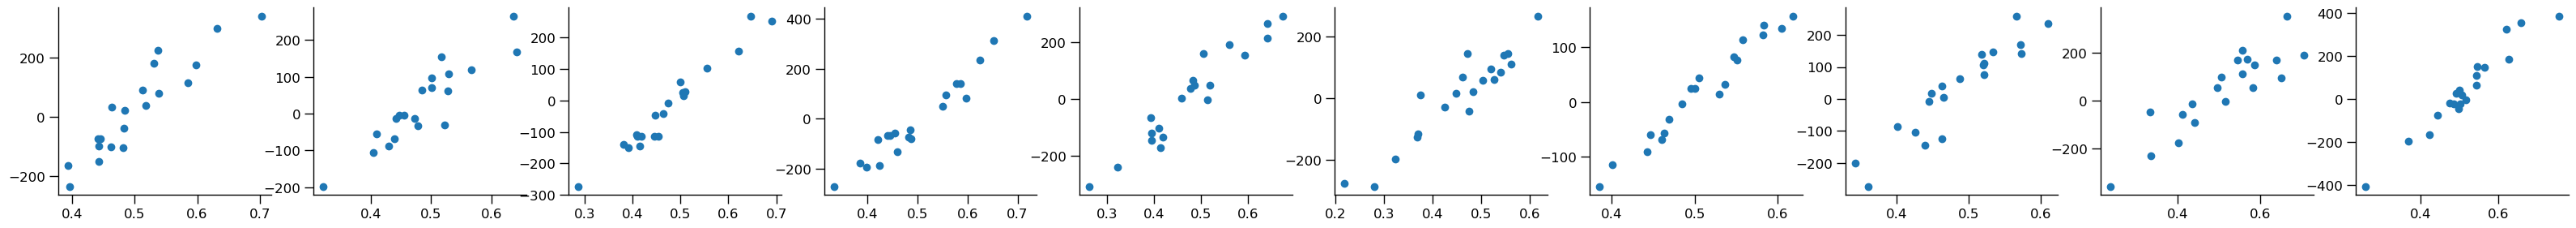

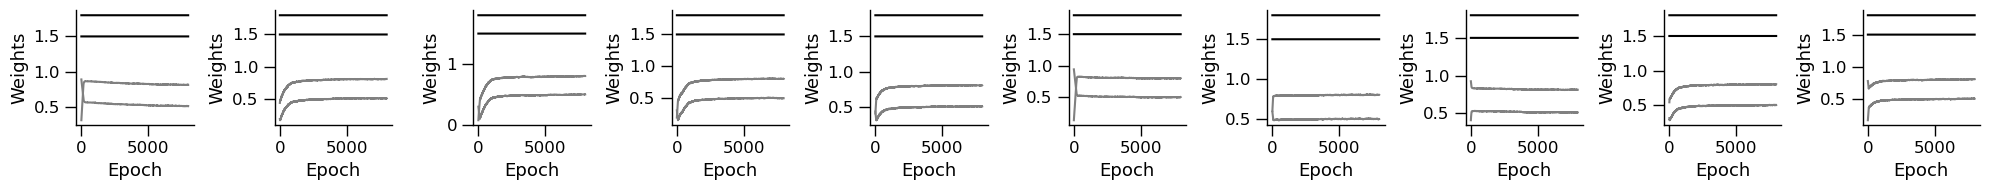

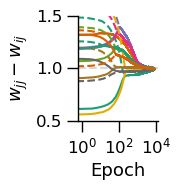

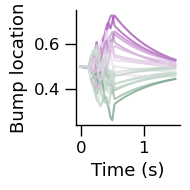

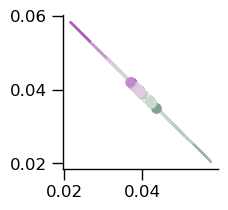

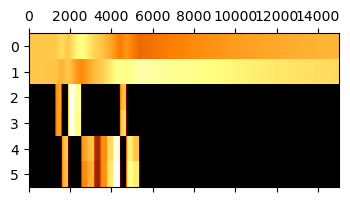

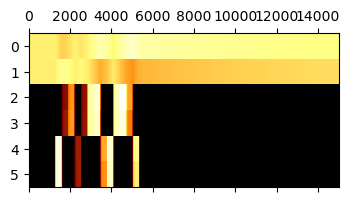

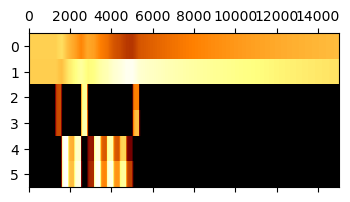

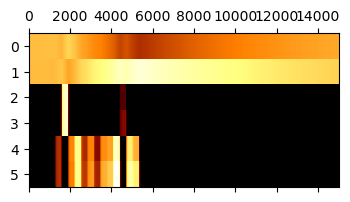

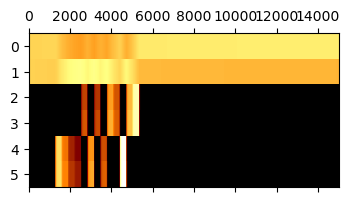

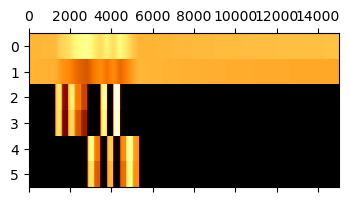

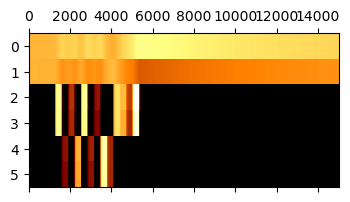

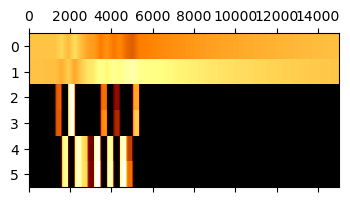

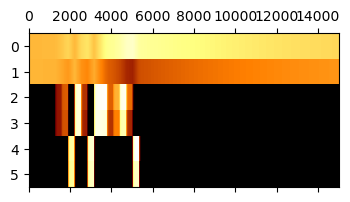

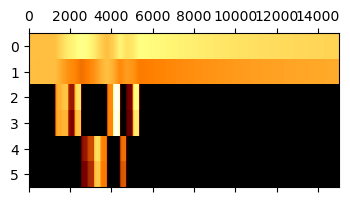

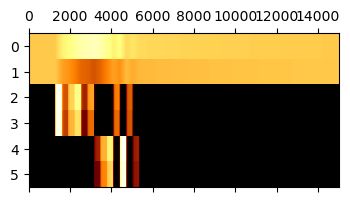

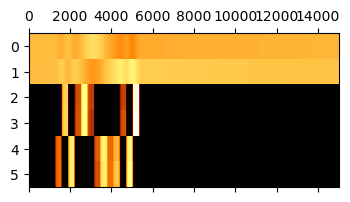

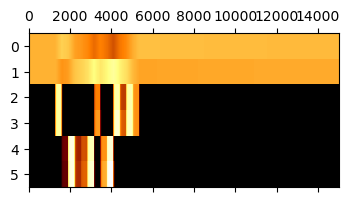

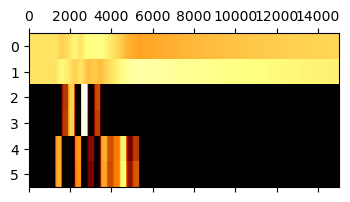

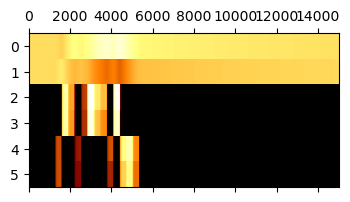

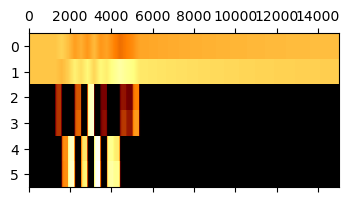

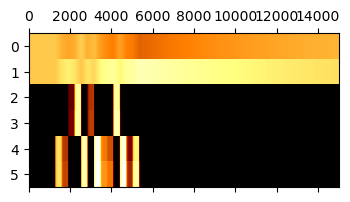

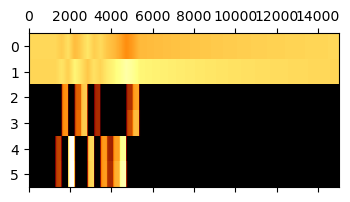

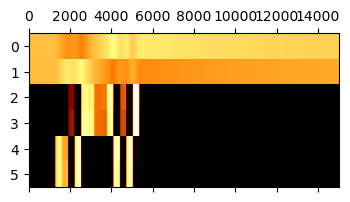

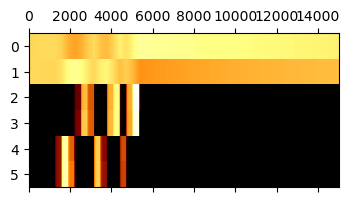

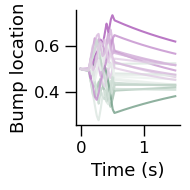

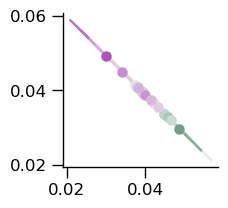

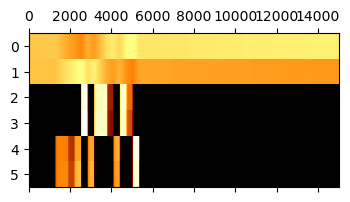

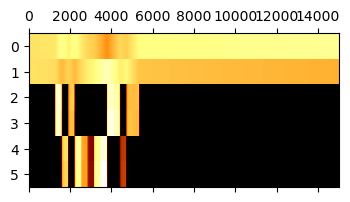

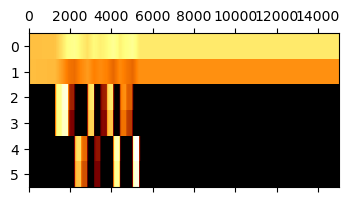

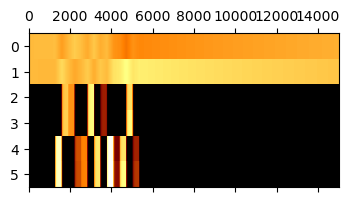

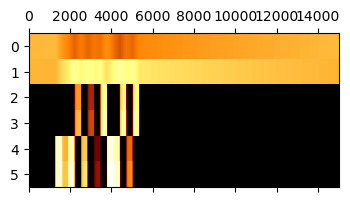

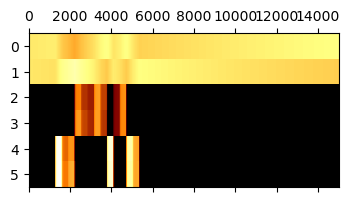

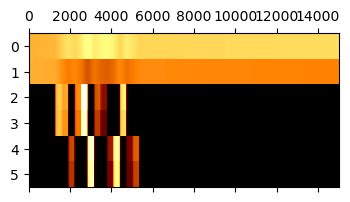

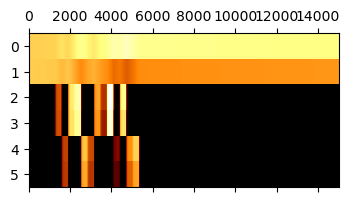

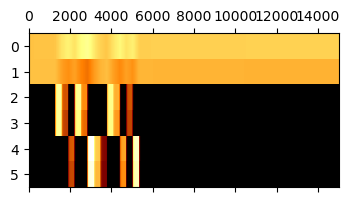

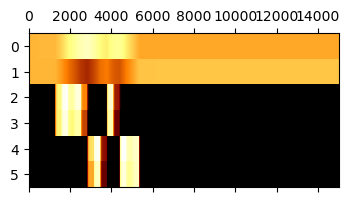

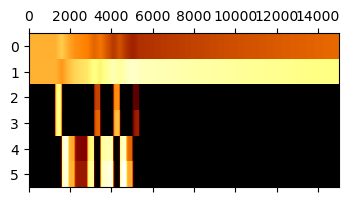

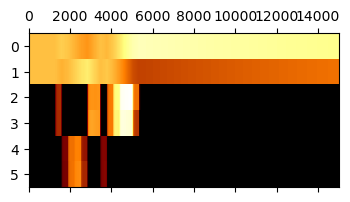

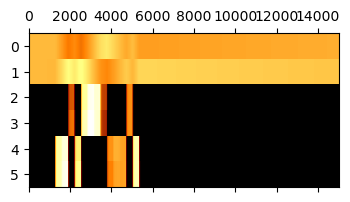

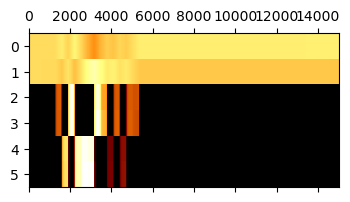

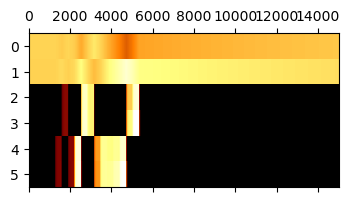

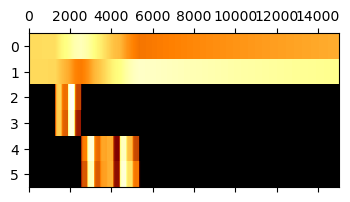

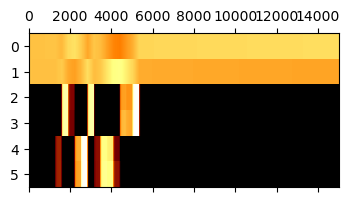

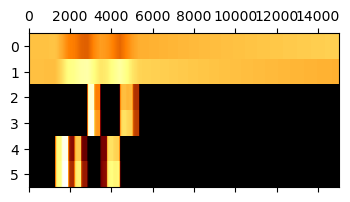

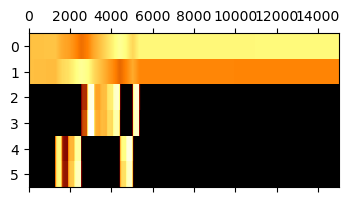

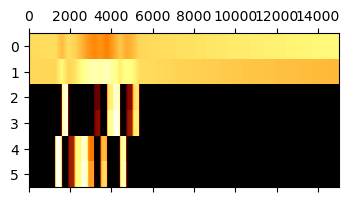

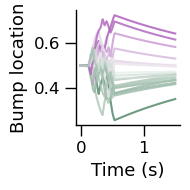

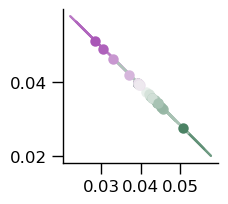

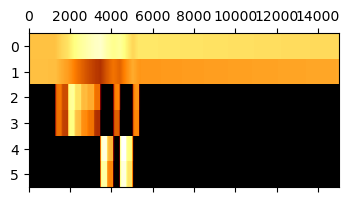

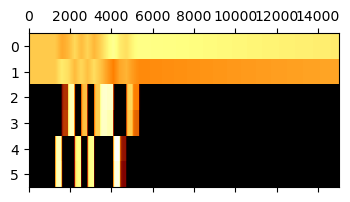

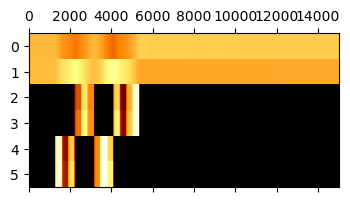

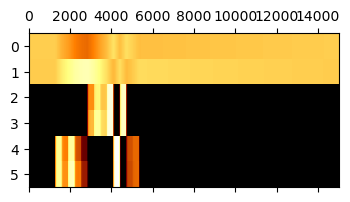

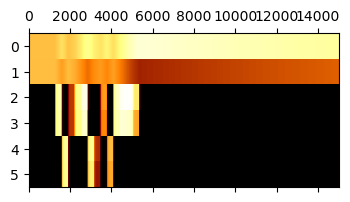

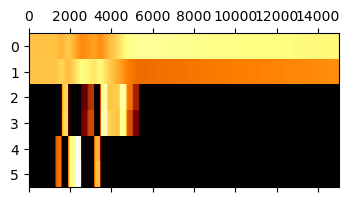

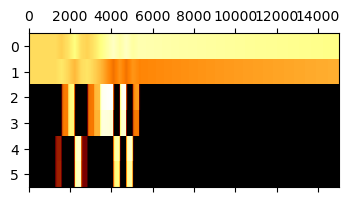

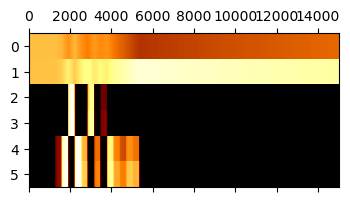

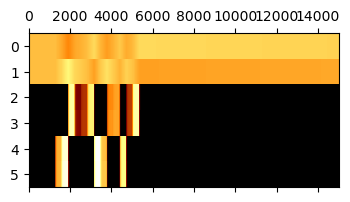

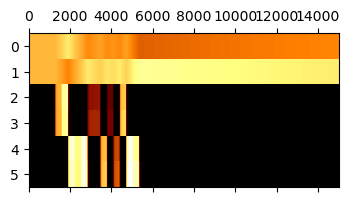

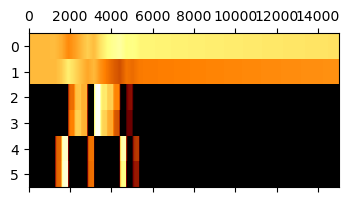

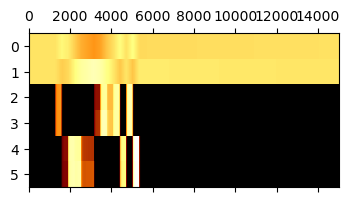

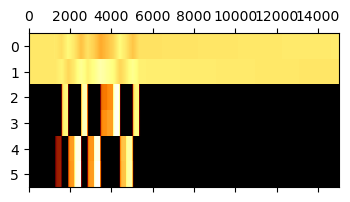

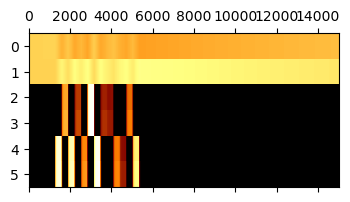

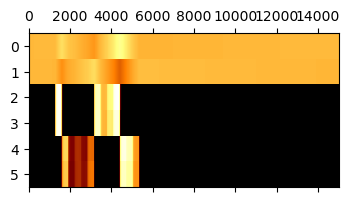

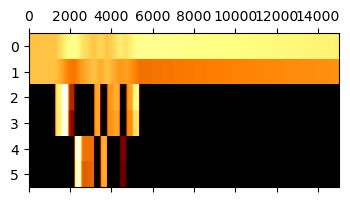

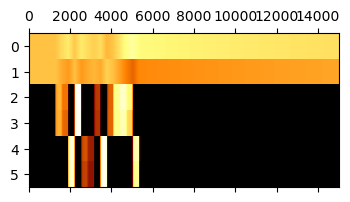

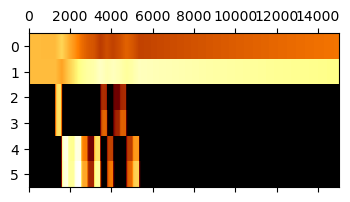

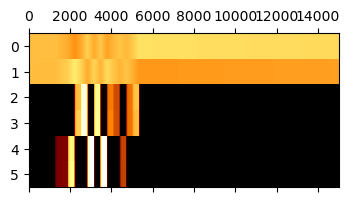

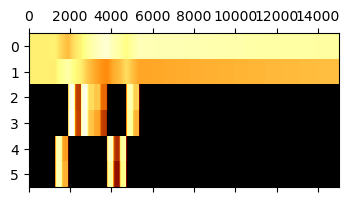

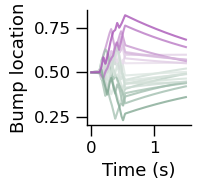

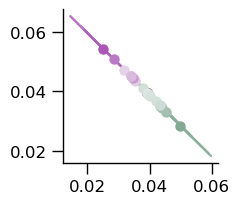

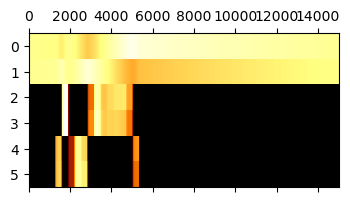

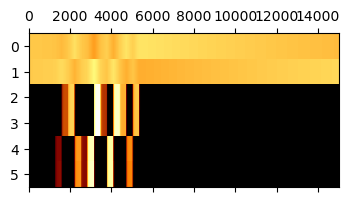

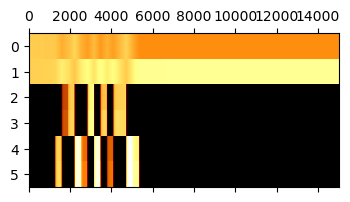

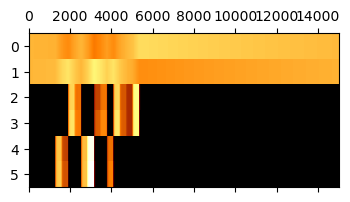

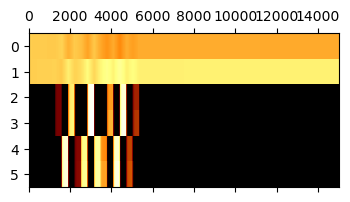

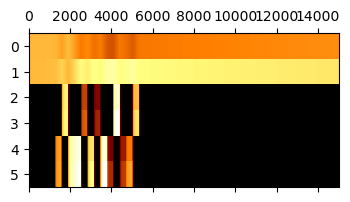

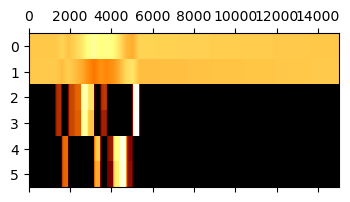

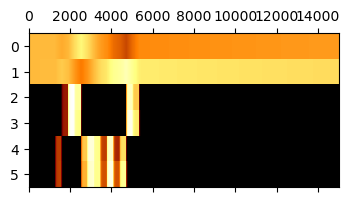

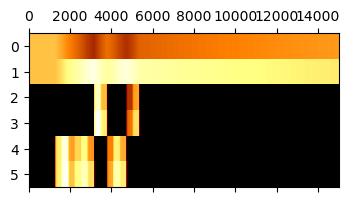

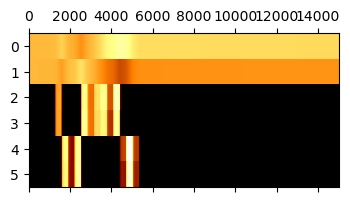

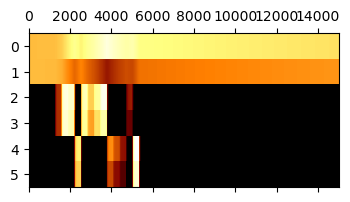

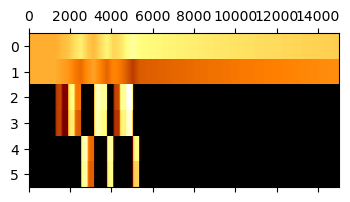

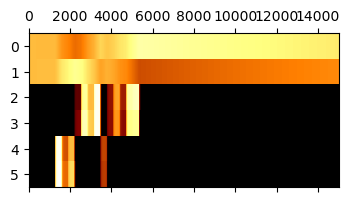

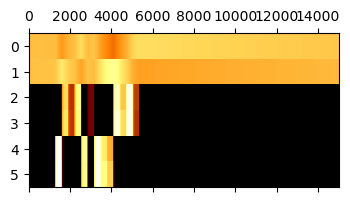

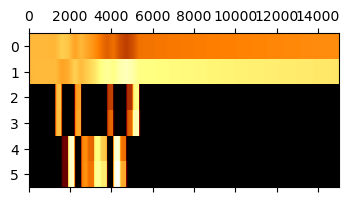

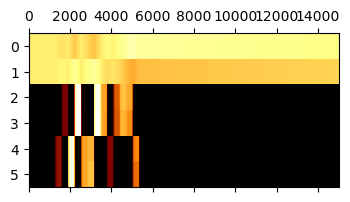

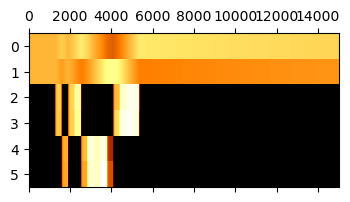

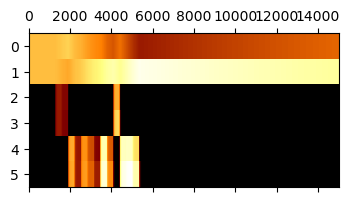

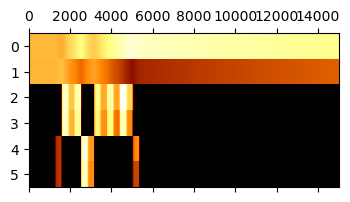

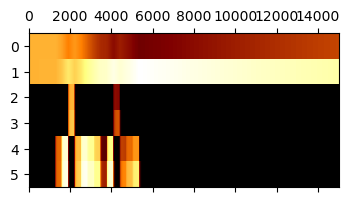

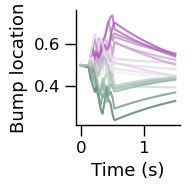

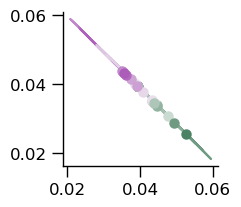

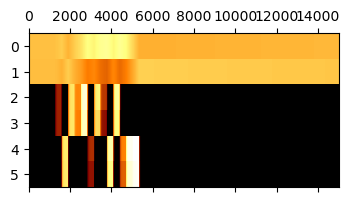

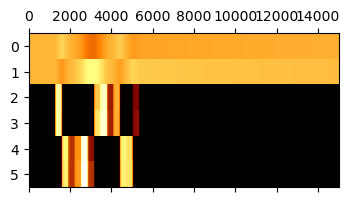

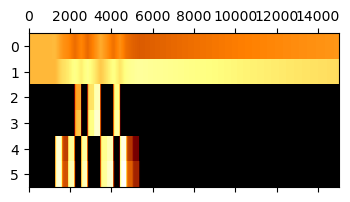

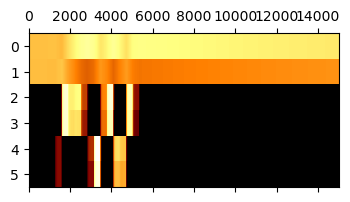

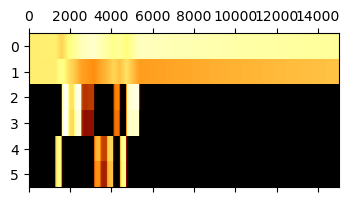

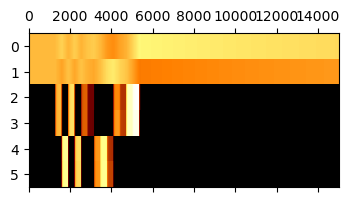

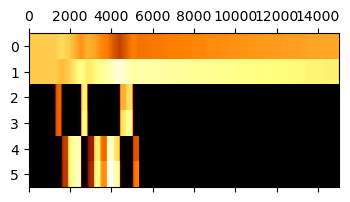

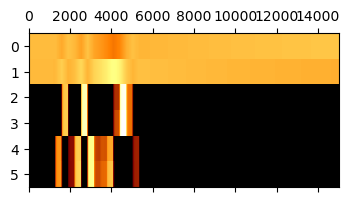

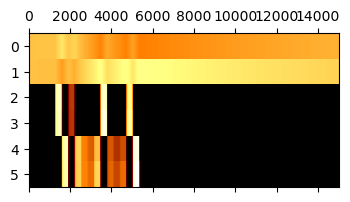

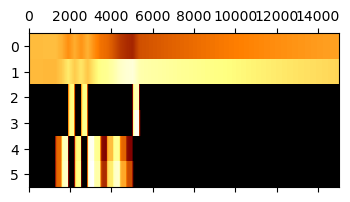

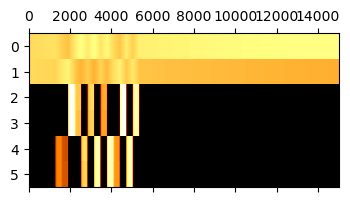

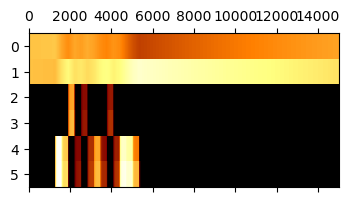

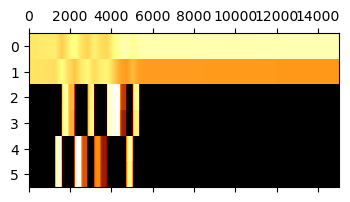

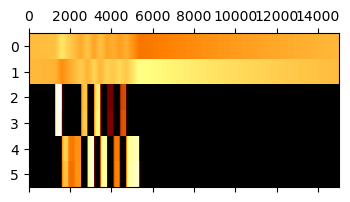

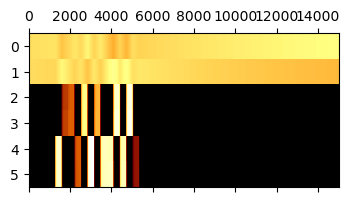

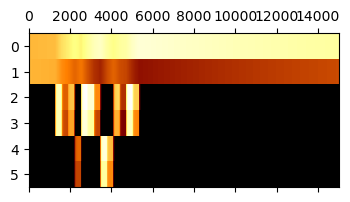

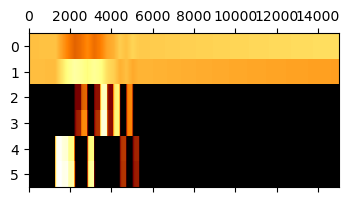

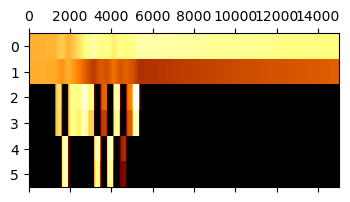

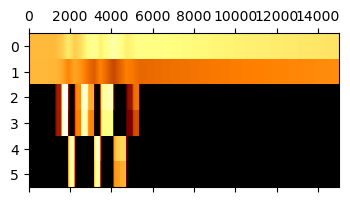

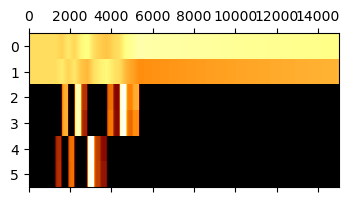

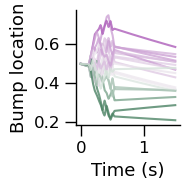

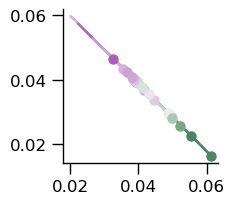

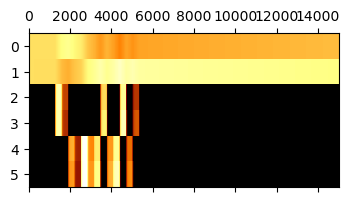

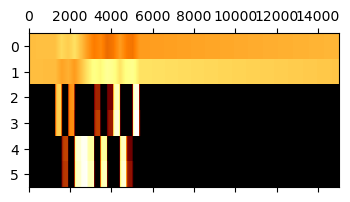

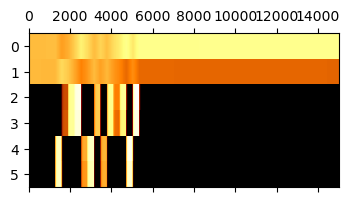

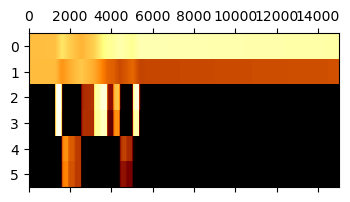

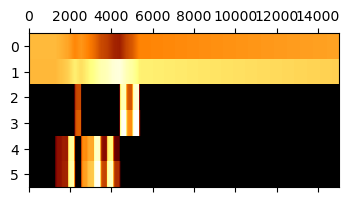

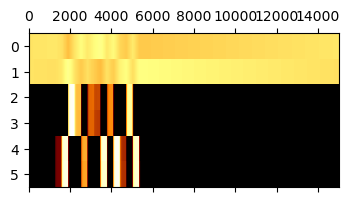

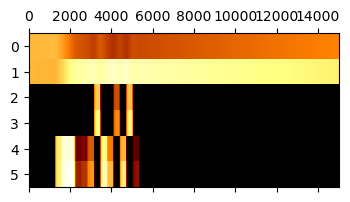

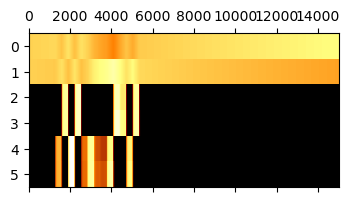

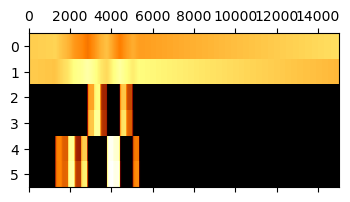

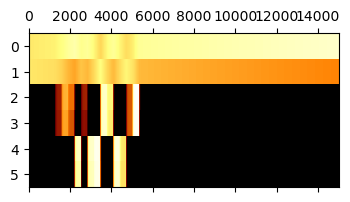

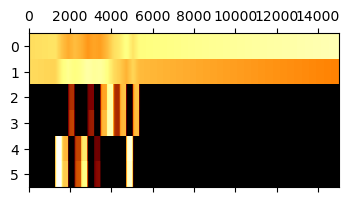

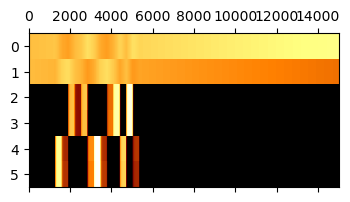

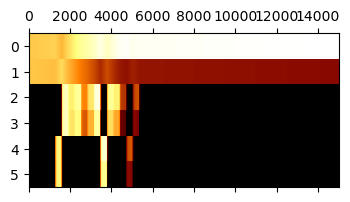

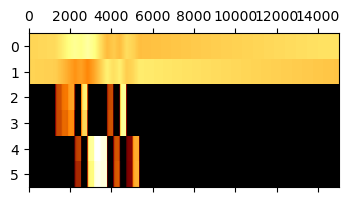

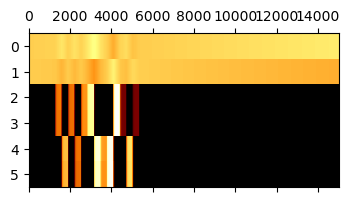

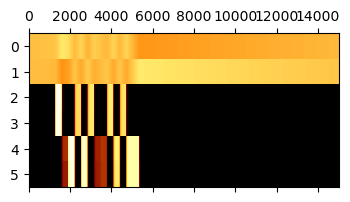

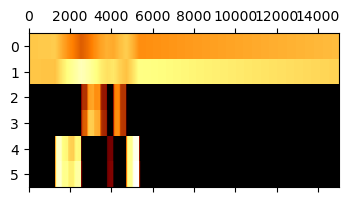

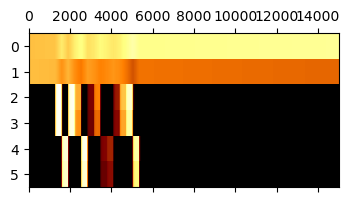

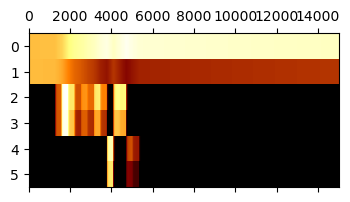

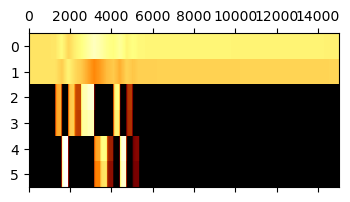

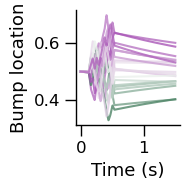

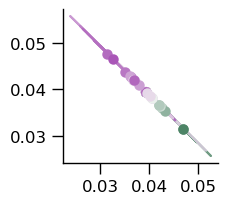

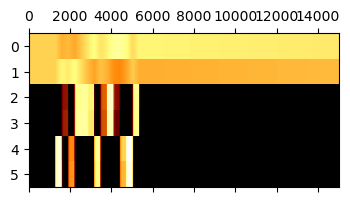

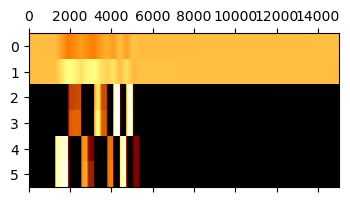

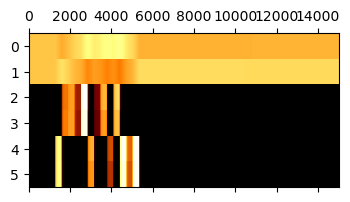

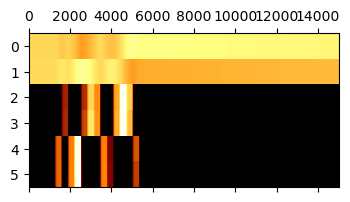

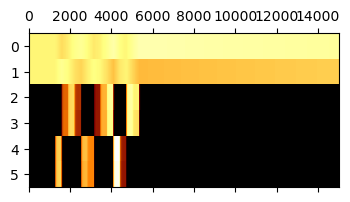

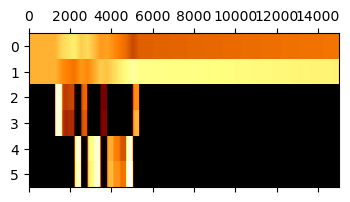

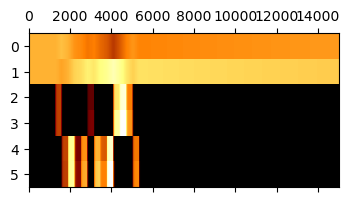

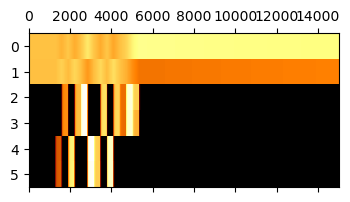

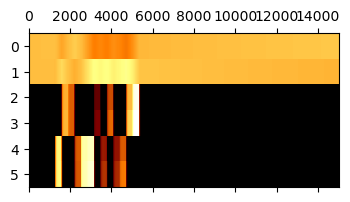

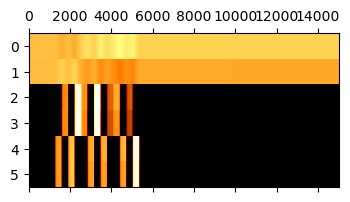

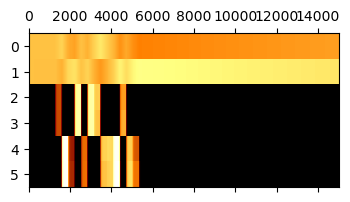

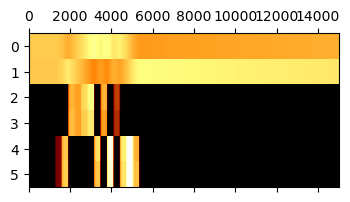

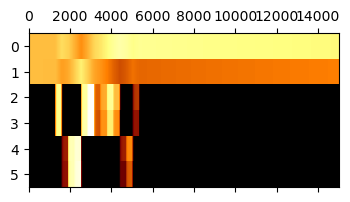

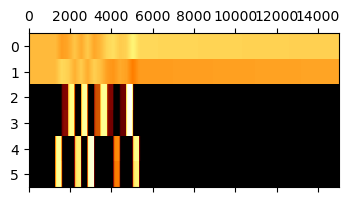

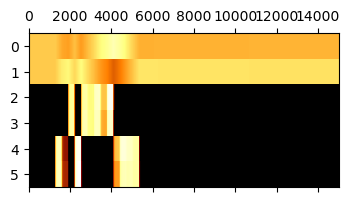

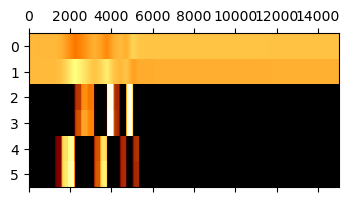

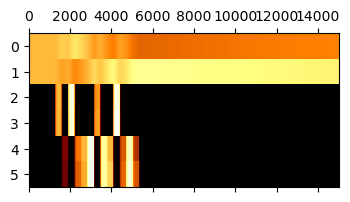

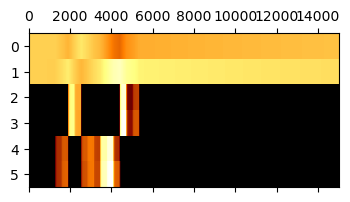

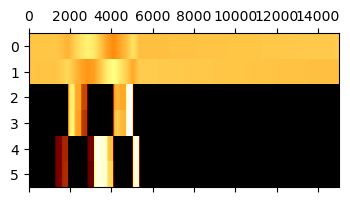

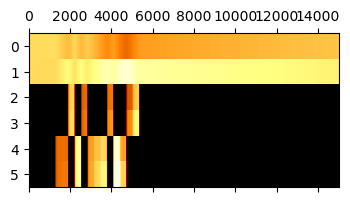

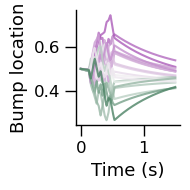

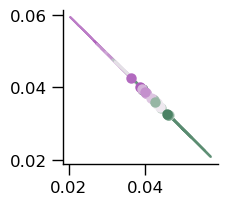

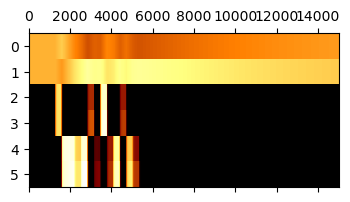

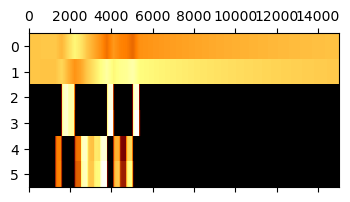

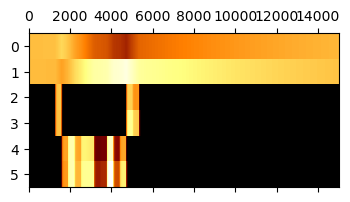

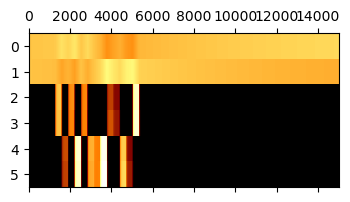

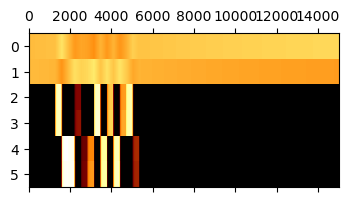

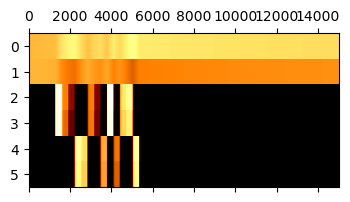

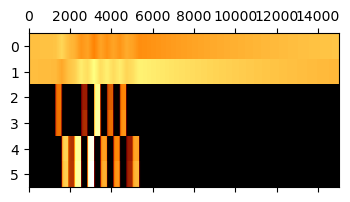

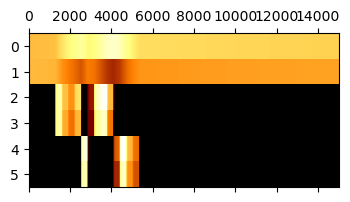

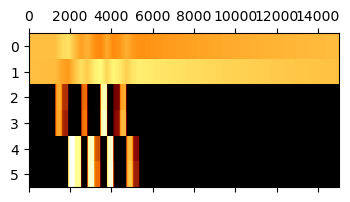

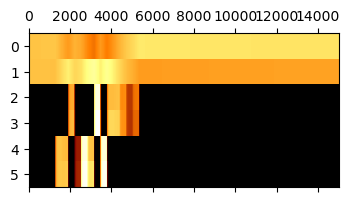

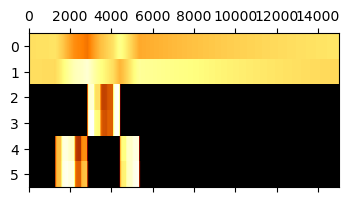

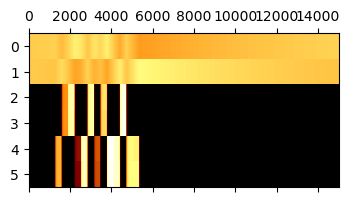

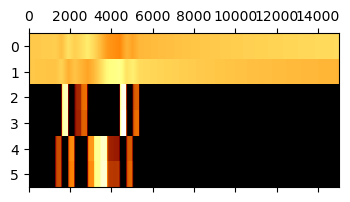

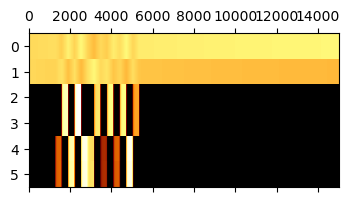

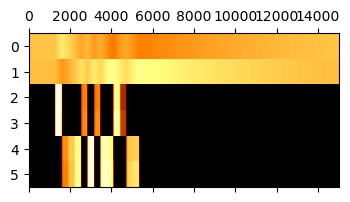

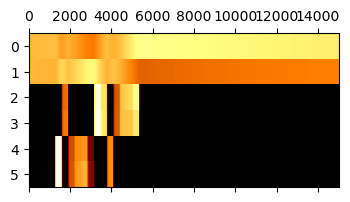

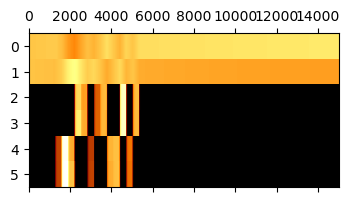

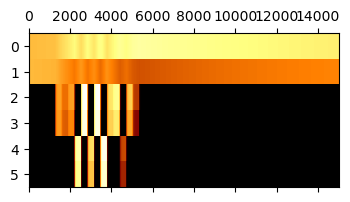

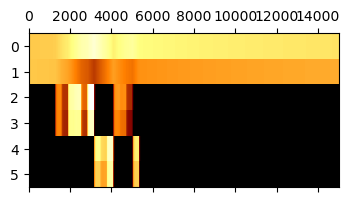

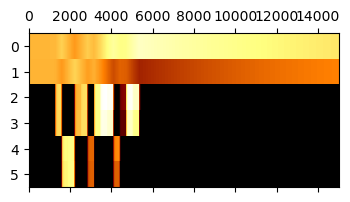

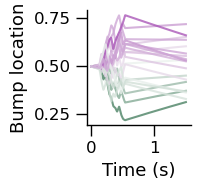

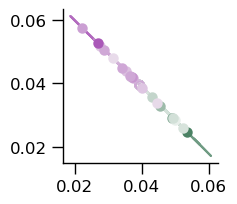

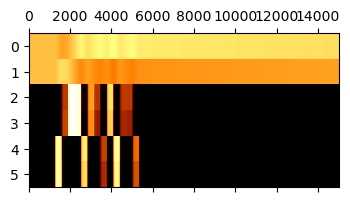

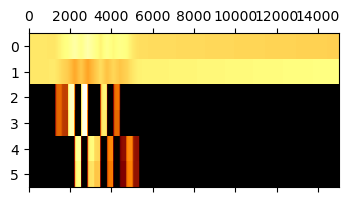

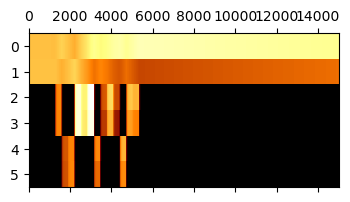

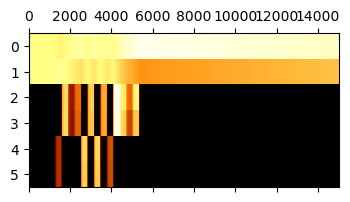

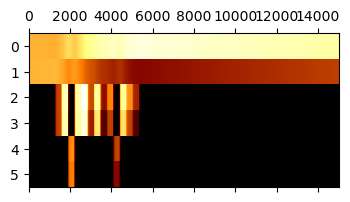

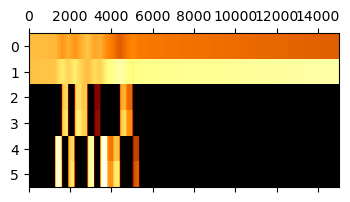

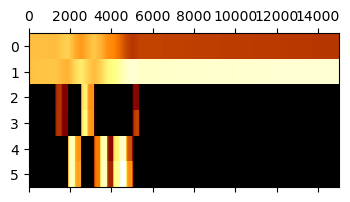

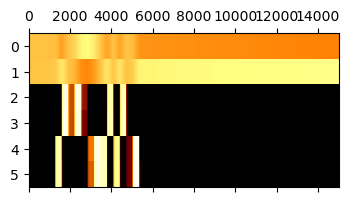

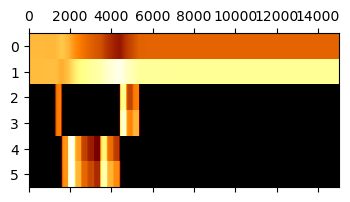

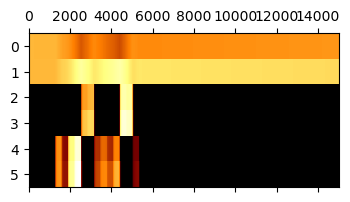

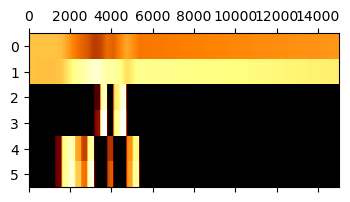

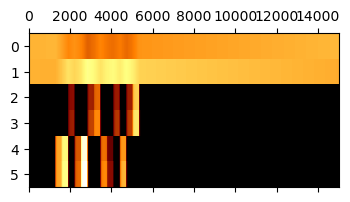

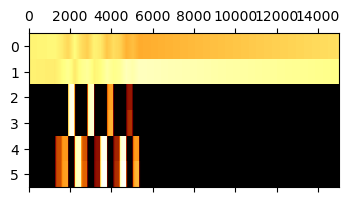

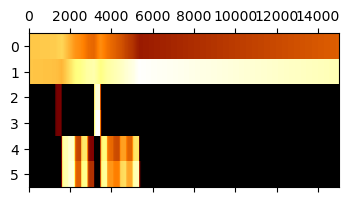

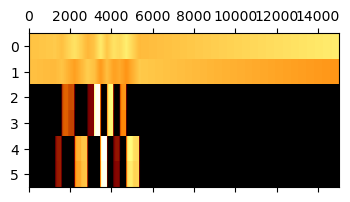

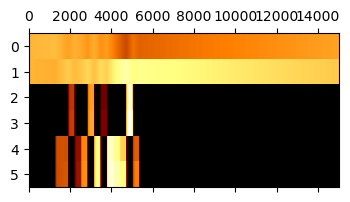

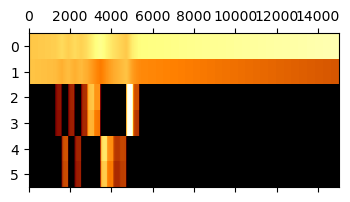

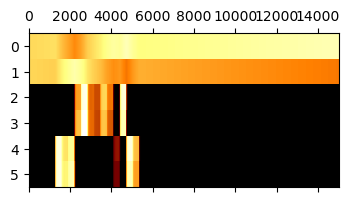

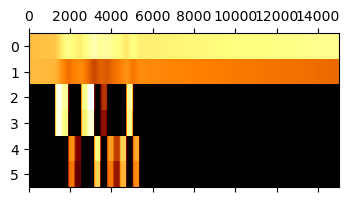

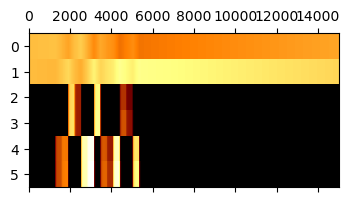

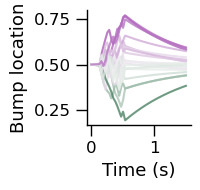

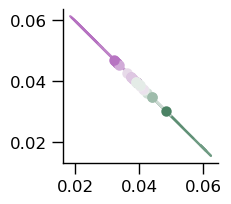

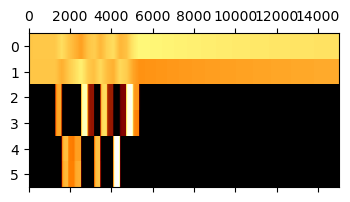

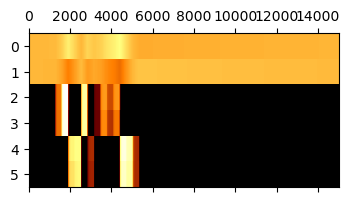

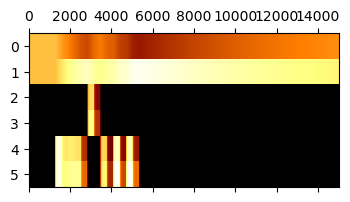

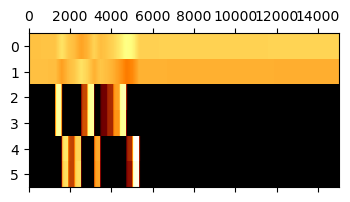

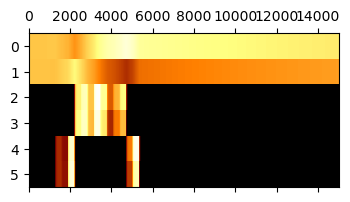

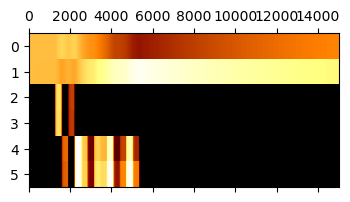

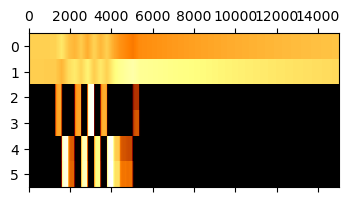

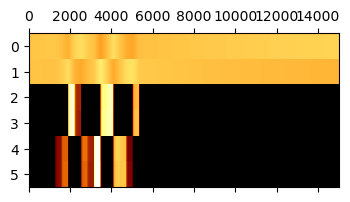

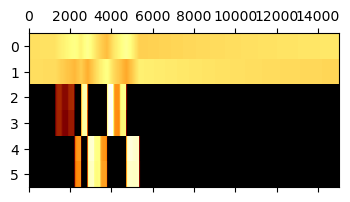

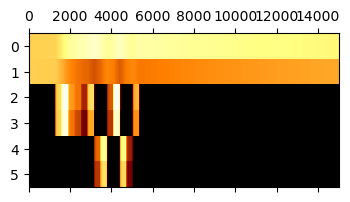

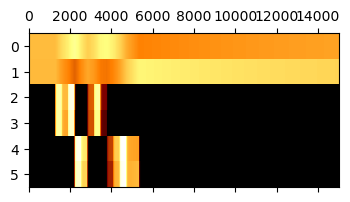

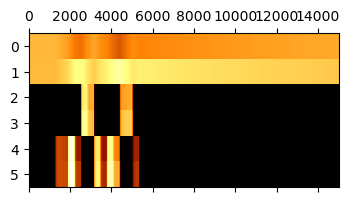

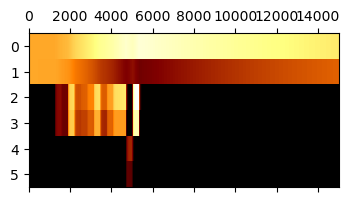

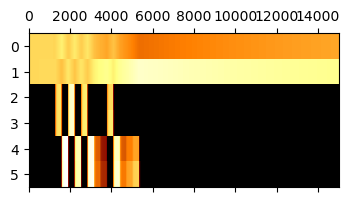

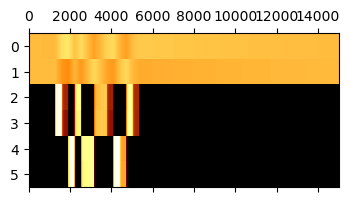

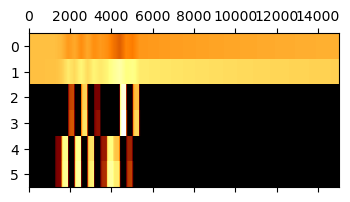

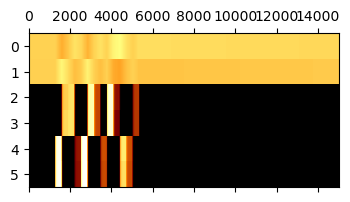

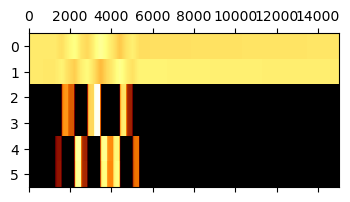

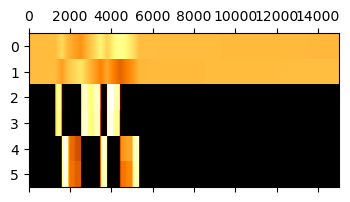

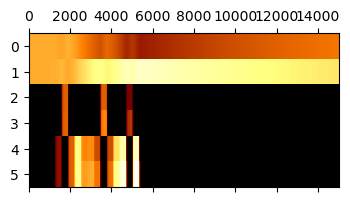

In [6]:
# del data
data = pickle.load(open('./network_training_results_w_change_w_ii.pkl', 'rb'))
results = data['results']
t = data['t']

# Plot results
fig_w, fig_w_traj = plot_results(results, t, n=2)

/tmp/ipykernel_1075403/3793284005.py:2: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  data = pickle.load(open('./network_training_results_v2_rule_n5.pkl', 'rb'))
/tmp/ipykernel_1075403/291814648.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 400x1200 with 4 Axes> than <Figure size 400x300 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[0, i], fraction=0.03)
/tmp/ipykernel_1075403/291814648.py:27: UserWarning: Adding colorbar to a different Figure <Figure size 400x1200 with 5 Axes> than <Figure size 400x300 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=axes_w[1, i], fraction=0.03)


0


/tmp/ipykernel_1075403/291814648.py:141: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(4, 2))


corr 0.010211919842580866


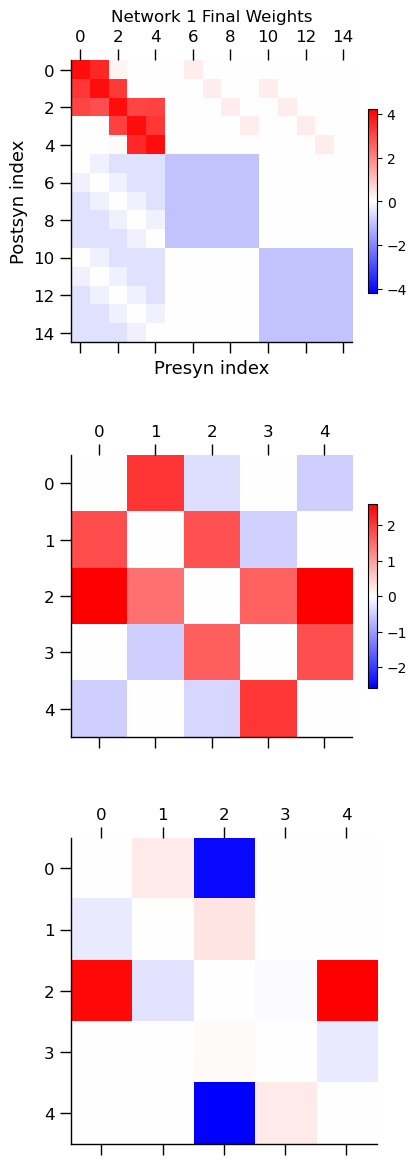

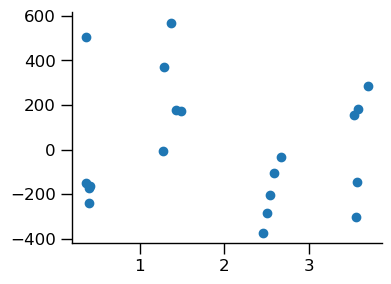

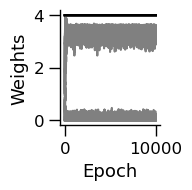

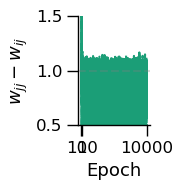

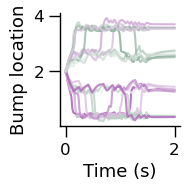

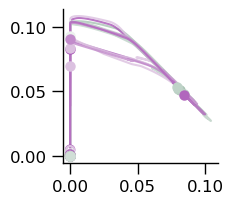

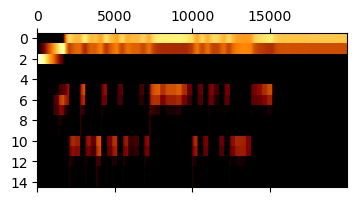

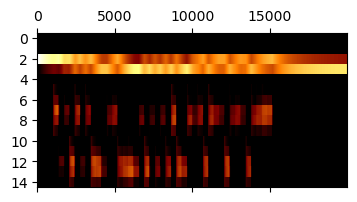

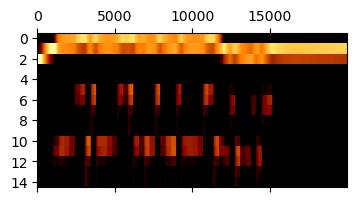

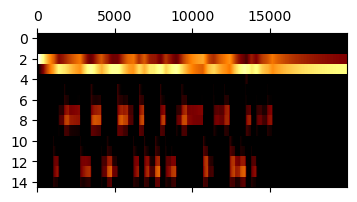

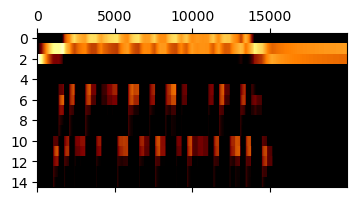

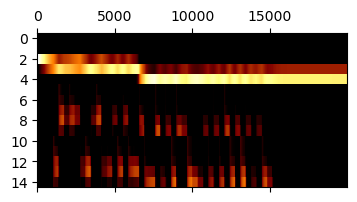

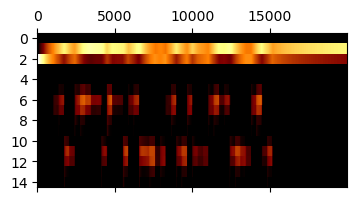

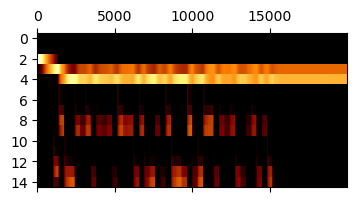

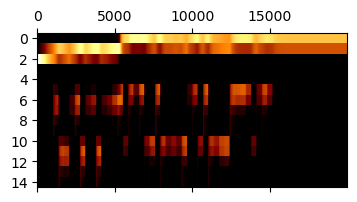

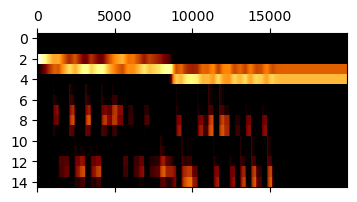

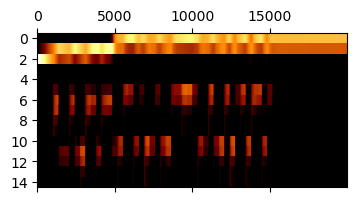

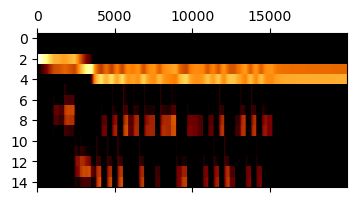

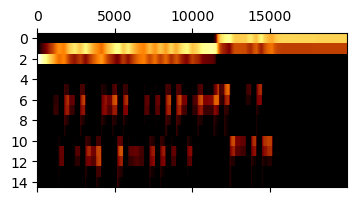

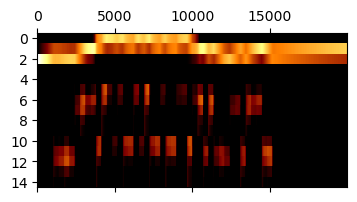

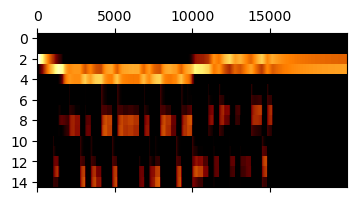

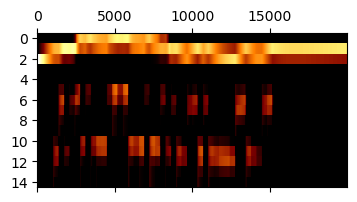

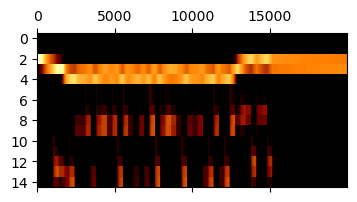

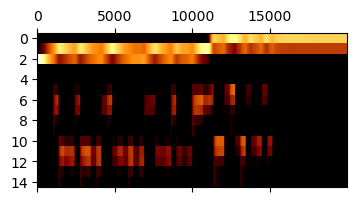

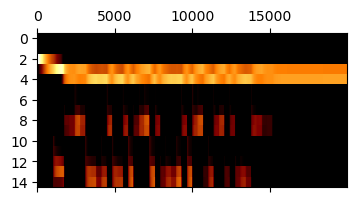

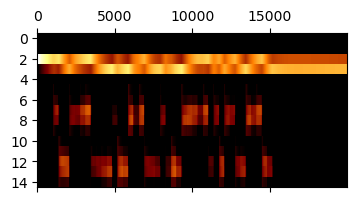

In [5]:
# del data
data = pickle.load(open('./network_training_results_v2_rule_n5.pkl', 'rb'))
results = data['results']
t = data['t']

# Plot results
fig_w, fig_w_traj, r2 = plot_results(results, t, n=5, input_start=1.5)

In [11]:
corr_mat = []
alpha_vals = []

for file in [
    'hyperparam_sweep_results_part_1.pkl',
    'hyperparam_sweep_results_part_2.pkl',
]:
    
    data_for_file = pickle.load(open(file, 'rb'))

    corr_mat_for_file = data_for_file['correlation_matrix']
    alpha_vals_for_file = data_for_file['alpha_values']

    corr_mat.append(corr_mat_for_file)
    alpha_vals.append(alpha_vals_for_file)

corr_mat = np.concatenate(corr_mat)
alpha_vals = np.concatenate(alpha_vals)
print(corr_mat.shape)

(100, 1, 5)


In [41]:
data_null = pickle.load(open('./hyperparam_sweep_results_ctrl.pkl', 'rb'))
corr_mat_null = data_null['correlation_matrix']
# corr_mat_null = corr_mat_null ** 2

In [42]:
corr_mat_null

array([[[            nan,  5.21663357e-17, -9.47327360e-17,
         -1.91788376e-17,  2.32631717e-01]]])

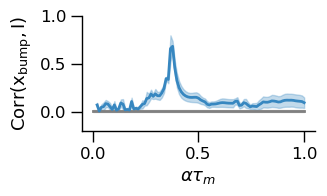

In [43]:
scale = 1
fig, axes = plt.subplots(1, 1, figsize=(scale * 3, scale * 1.5))

colors = sns.color_palette("Blues_d", n_colors=1)

corr_mat_null = np.where(np.isnan(corr_mat_null), 0, corr_mat_null)
mean = np.nanmean(corr_mat_null[0, 0, :] ** 2)
std = np.nanstd(corr_mat[0, 0, :] ** 2) / np.sqrt(corr_mat_null.shape[2])
axes.fill_between(alpha_vals * 0.01, mean - std, mean + std, alpha=0.3, color='grey')
axes.plot(alpha_vals * 0.01, mean * np.ones(len(alpha_vals)), lw=2, color='grey')

for i in range(corr_mat.shape[1]):
    mean = np.mean(corr_mat[:, i, :] ** 2, axis=1)
    std = np.std(corr_mat[:, i, :] ** 2, axis=1) / np.sqrt(corr_mat.shape[2])
    axes.fill_between(alpha_vals  * 0.01, mean - std, mean + std, alpha=0.3, color=colors[i])
    axes.plot(alpha_vals  * 0.01, mean, lw=2, color=colors[i])
    
# axes.set_ylim(0.3, 1)
axes.set_ylabel(r'$\rm{Corr}(x_{\rm bump}, I)$')
axes.set_xlabel(r'$\alpha \tau_m$')
axes.set_ylim(-0.2, 1)
format_plot(axes)
fig.savefig('./figures/handbuilt_rules/hyperparam_sweep.svg', bbox_inches='tight')


0.9646008918307951


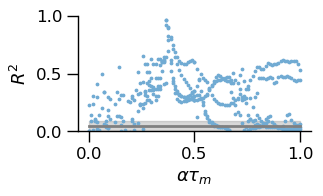

In [36]:
fig, axes = plt.subplots(1, 1, figsize=(3, 1.5))

colors = sns.color_palette("Blues_d", n_colors=3)

corr_mat_null = np.where(np.isnan(corr_mat_null), 0, corr_mat_null)
mean = np.nanmean(corr_mat_null[0, 0, :])
std = np.nanstd(corr_mat[0, 0, :]) / np.sqrt(corr_mat_null.shape[2])
axes.fill_between(alpha_vals * 0.01, mean - std, mean + std, alpha=0.3, color='grey')
axes.plot(alpha_vals * 0.01, mean * np.ones(len(alpha_vals)), lw=2, color='grey')

for i in range(corr_mat.shape[1]):
    # mean = np.median(corr_mat[:, i, :], axis=1)
    # std = np.std(corr_mat[:, i, :], axis=1) / np.sqrt(corr_mat.shape[2])
    # axes.fill_between(data['alpha_values']  * 0.01, mean - std, mean + std, alpha=0.3, color=colors[i])
    for k in range(corr_mat.shape[2]):
        axes.scatter(alpha_vals  * 0.01, corr_mat[:, i, k], color=colors[i], s=3)

print(np.nanmax(corr_mat))
    
# axes.set_ylim(0.3, 1)
axes.set_ylabel(r'$R^2$')
axes.set_xlabel(r'$\alpha \tau_m$')
axes.set_ylim(0, 1)
format_plot(axes)

In [4]:
corr_mat = []
alpha_vals = []

for file in [
    'hyperparam_sweep_results_w_part_1.pkl',
    'hyperparam_sweep_results_w_part_2.pkl',
]:
    
    data_for_file = pickle.load(open(file, 'rb'))

    corr_mat_for_file = data_for_file['correlation_matrix']
    alpha_vals_for_file = data_for_file['alpha_values']

    corr_mat.append(corr_mat_for_file)
    alpha_vals.append(alpha_vals_for_file)

corr_mat = np.concatenate(corr_mat)
alpha_vals = np.concatenate(alpha_vals)
print(corr_mat.shape)

(100, 3, 5)


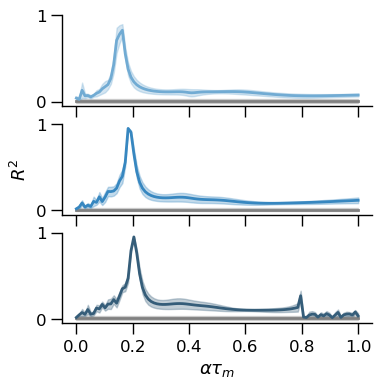

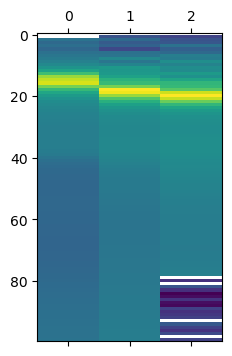

In [39]:
scale = 2
fig, axes = plt.subplots(3, 1, figsize=(scale * 2, scale * 2), sharex=True, sharey=True)

colors = sns.color_palette("Blues_d", n_colors=3)

corr_mat_null = np.where(np.isnan(corr_mat_null), 0, corr_mat_null)
mean_null = np.nanmean(corr_mat_null[0, 0, :] ** 2)
std_null = np.nanstd(corr_mat[0, 0, :] ** 2) / np.sqrt(corr_mat_null.shape[2])

for i in range(corr_mat.shape[1]):
    axes[i].fill_between(alpha_vals * 0.01, mean_null - std_null, mean_null + std_null, alpha=0.3, color='grey')
    axes[i].plot(alpha_vals * 0.01, mean_null * np.ones(len(alpha_vals)), lw=2, color='grey')
    
    mean = np.nanmean(corr_mat[:, i, :] ** 2, axis=1)
    std = np.nanstd(corr_mat[:, i, :] ** 2, axis=1) / np.sqrt(corr_mat.shape[2])
    axes[i].fill_between(alpha_vals  * 0.01, mean - std, mean + std, alpha=0.3, color=colors[i])
    axes[i].plot(alpha_vals  * 0.01, mean, lw=2, color=colors[i])

    # axes[i].set_xlim(0.1, 0.3)
    # axes[i].set_yscale('log')
    
# axes.set_ylim(0.3, 1)
axes[1].set_ylabel(r'$R^2$')
axes[-1].set_xlabel(r'$\alpha \tau_m$')
axes[-1].set_ylim(-0.05, 1)
format_plot(axes)
fig.savefig('./figures/handbuilt_rules/hyperparam_sweep_w.svg', bbox_inches='tight')

scale = 2
fig, axes = plt.subplots(1, 1, figsize=(scale * 2, scale * 2), sharex=True, sharey=True)
axes.matshow(corr_mat.mean(axis=2), aspect=0.05)

In [3]:
corr_mat = []
alpha_vals = []

for file in [
    'hyperparam_sweep_results_v3_part_1.pkl',
    'hyperparam_sweep_results_v3_part_2.pkl',
]:
    
    data_for_file = pickle.load(open(file, 'rb'))

    corr_mat_for_file = data_for_file['correlation_matrix']
    alpha_vals_for_file = data_for_file['alpha_values']

    corr_mat.append(corr_mat_for_file)
    alpha_vals.append(alpha_vals_for_file)

corr_mat = np.concatenate(corr_mat)
alpha_vals = np.concatenate(alpha_vals)
print(corr_mat.shape)

(100, 1, 15)


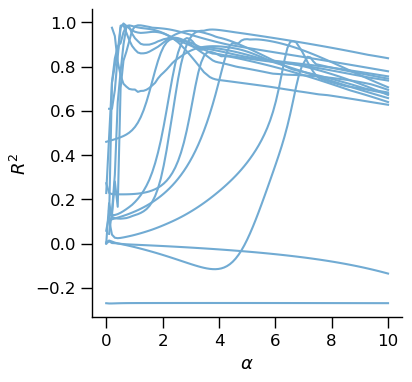

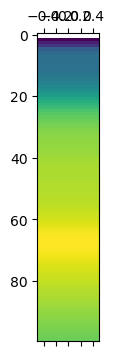

In [4]:
scale = 2
fig, axes = plt.subplots(1, 1, figsize=(scale * 2, scale * 2), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

colors = sns.color_palette("Blues_d", n_colors=3)

# corr_mat_null = np.where(np.isnan(corr_mat_null), 0, corr_mat_null)
# mean_null = np.nanmean(corr_mat_null[0, 0, :] ** 2)
# std_null = np.nanstd(corr_mat[0, 0, :] ** 2) / np.sqrt(corr_mat_null.shape[2])

for i in range(corr_mat.shape[1]):
    # axes[i].fill_between(alpha_vals * 0.01, mean_null - std_null, mean_null + std_null, alpha=0.3, color='grey')
    # axes[i].plot(alpha_vals * 0.01, mean_null * np.ones(len(alpha_vals)), lw=2, color='grey')
    
    mean = np.nanmean(corr_mat[:, i, :] ** 2, axis=1)
    std = np.nanstd(corr_mat[:, i, :] ** 2, axis=1) / np.sqrt(corr_mat.shape[2])
    # axes[i].fill_between(alpha_vals, mean - std, mean + std, alpha=0.3, color=colors[i])
    # axes[i].plot(alpha_vals, mean, lw=2, color=colors[i])

    for k in range(corr_mat.shape[2]):
        axes[i].plot(alpha_vals, corr_mat[:, i, k], color=colors[i])

    # axes[i].set_xlim(0.1, 0.3)
    # axes[i].set_yscale('log')
    
# axes.set_ylim(0.3, 1)
axes[0].set_ylabel(r'$R^2$')
axes[-1].set_xlabel(r'$\alpha$')
# axes[-1].set_ylim(-0.05, 1)
format_plot(axes)
# fig.savefig('./figures/handbuilt_rules/hyperparam_sweep_w.svg', bbox_inches='tight')

scale = 2
fig, axes = plt.subplots(1, 1, figsize=(scale * 2, scale * 2), sharex=True, sharey=True)
axes.matshow(corr_mat.mean(axis=2), aspect=0.05)